#DATASET UPLOADING
1) df (by transaction_id)
2) rfm_df (by customer_id)
3) merged_df (by customer_id & transaction_id)

##1_DF_Uploading and reading of dataset (df - by transaction_id)

In [203]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd

file_path = "/content/drive/MyDrive/AURA/transaction_data.xlsx"

df = pd.read_excel(file_path, sheet_name="transaction_data")  # page name

# Ensure transaction_date is in datetime format and extract transaction_year
df['transaction_date'] = pd.to_datetime(df['transaction_date'])
df['transaction_year'] = df['transaction_date'].dt.year

df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,transaction_id,customer_id,product_id,product_name,transaction_date,experiment_condition,referring_channel,region_code,referral_discount,avg_income,churn_rate,brand_affinity_score,price_sensitivity,quality_orientation,aesthetic_importance,retail_price,cogs,review_star,review_text,transaction_year
0,T0002651,C00731,PRO_X,Aura Pro X,2022-01-01,Control,Direct,W,0,83195,0.23,4,Low,High,Med,1400,560.0,NaN,NaN,2022
1,T0000065,C00020,GO_AIR,Aura Go Air,2022-01-01,Influencer,Search,EU,0,53761,0.18,3,High,Med,High,180,126.0,NaN,NaN,2022
2,T0001818,C00495,GO_AIR,Aura Go Air,2022-01-01,Influencer,Social,W,0,52803,0.16,3,High,Med,Med,180,126.0,3.26,Very comfy with great battery life; sound is f...,2022
3,T0001818,C00495,GO_PLUS,Aura Go Plus,2022-01-01,Influencer,Social,W,0,52803,0.16,3,High,Med,Med,260,174.2,3.93,Very comfy with great battery life; sound is f...,2022
4,T0004453,C01204,GO_AIR,Aura Go Air,2022-01-01,Influencer,Affiliate,NE,0,46288,0.17,3,High,Med,Med,180,126.0,NaN,NaN,2022


##2_RFM_DF_Uploading and reading of dataset (rfm_df - by customer_id)

In [204]:
import pandas as pd

# Ensure transaction_date is in datetime format
df['transaction_date'] = pd.to_datetime(df['transaction_date'])

# Define the reference date for Recency calculation
reference_date = pd.to_datetime('2024-12-30')

# Calculate Recency: days since last purchase
last_purchase_date = df.groupby('customer_id')['transaction_date'].max()
recency = (reference_date - last_purchase_date).dt.days

# Calculate Frequency: count of unique transaction_ids per customer
frequency = df.groupby('customer_id')['transaction_id'].nunique()

# Calculate Monetary Value: sum of retail_price per customer
monetary_value = df.groupby('customer_id')['retail_price'].sum()

# Combine all three metrics into a single DataFrame
rfm_df = pd.DataFrame({
    'Recency': recency,
    'Frequency': frequency,
    'MonetaryValue': monetary_value
})

print("RFM DataFrame:")
display(rfm_df.head())

RFM DataFrame:


,Recency,Frequency,MonetaryValue
customer_id,,,
C00001,58,3,620
C00002,222,6,4260
C00003,411,1,880
C00004,439,3,720
C00006,164,4,5900


Give a full code for creating these three variables to use it for fast start after reset. Check total count number of customer_id

In [205]:
rfm_df.columns

Index(['Recency', 'Frequency', 'MonetaryValue'], dtype='object')

In [206]:
total_unique_customers = df['customer_id'].nunique()
total_retail_price = df['retail_price'].sum()

print(f"Total number of unique customers: {total_unique_customers}")
print(f"Total retail price: {total_retail_price:,.2f}")

Total number of unique customers: 1436
Total retail price: 3,683,900.00


How I can import and save to google disk rfm_df and merged_df? save dataset in AURA folder on my https://drive.google.com/drive/my-drive

In [207]:
from google.colab import drive
drive.mount('/content/drive')
import pandas as pd

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Saving `rfm_df` to Google Drive

In [208]:
# Define the path to save rfm_df on Google Drive
rfm_save_path = '/content/drive/MyDrive/rfm_df.csv'

# Save rfm_df to CSV
rfm_df.to_csv(rfm_save_path, index=True) # index=True to save the customer_id as a column

print(f"rfm_df saved successfully to {rfm_save_path}")

rfm_df saved successfully to /content/drive/MyDrive/rfm_df.csv


In [209]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans

# Ensure df is available (it's in the kernel state)
# Assuming 'df' is already loaded and pre-processed with transaction_date, gross_margin_abs, gross_margin_% etc.

# --- 1. Calculate Recency, Frequency, Monetary Value ---
reference_date = pd.to_datetime('2024-12-30')
last_purchase_date = df.groupby('customer_id')['transaction_date'].max()
recency = (reference_date - last_purchase_date).dt.days
frequency = df.groupby('customer_id')['transaction_id'].nunique()
monetary_value = df.groupby('customer_id')['retail_price'].sum()

rfm_df = pd.DataFrame({
    'Recency': recency,
    'Frequency': frequency,
    'MonetaryValue': monetary_value
})

# --- 2. Create R_Segment, F_Segment, M_Segment ---
# R_Segment
bins_r = [0, 90, 365, 730, np.inf]
labels_r = ['Active', 'Warm', 'At Risk', 'Lost']
rfm_df['R_Segment'] = pd.cut(
    rfm_df['Recency'], bins=bins_r, labels=labels_r, right=True, include_lowest=True
)

# F_Segment
conditions_f = [
    rfm_df['Frequency'] == 1,
    (rfm_df['Frequency'] >= 2) & (rfm_df['Frequency'] <= 3),
    (rfm_df['Frequency'] >= 4) & (rfm_df['Frequency'] <= 7),
    rfm_df['Frequency'] >= 8
]
labels_f = ['One-timers', 'Occasional', 'Loyal', 'Super-Loyal']
rfm_df['F_Segment'] = np.select(conditions_f, labels_f, default='Other')

# M_Segment
bins_m = [0, 1040, 3320, 7080, np.inf]
labels_m = ['Low Value', 'Mid Value', 'High Value', 'VIP']
rfm_df['M_Segment'] = pd.cut(
    rfm_df['MonetaryValue'], bins=bins_m, labels=labels_m, right=True, include_lowest=True
)

# --- 3. Create Recency_Inverted ---
max_rec = rfm_df["Recency"].max()
rfm_df["Recency_Inverted"] = max_rec - rfm_df["Recency"]

# --- 4. Normalize RFM variables ---
scaler = MinMaxScaler()
cols_to_scale = ["Recency_Inverted", "Frequency", "MonetaryValue"]
rfm_df[["R_norm", "F_norm", "M_norm"]] = scaler.fit_transform(rfm_df[cols_to_scale])

# --- 5. Prepare for KMeans and run KMeans ---
rfm_for_kmeans = rfm_df[['R_norm', 'F_norm', 'M_norm']]
k = 3 # Based on previous Elbow and Silhouette analysis
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(rfm_for_kmeans)
rfm_df["Cluster"] = clusters

# --- 6. Rename Clusters based on semantic profiles (correct mapping) ---
# Original KMeans labels and their semantic profiles (re-verified):
# Cluster 0: Mid Value profile (Recency ~186, Freq ~4.09, Mon ~1851)
# Cluster 1: High Value profile (Recency ~118, Freq ~10.04, Mon ~4974)
# Cluster 2: Low Value profile (Recency ~692, Freq ~2.65, Mon ~1765)
cluster_name_mapping = {
    0: 'Mid Value Customers',
    1: 'High Value Customers',
    2: 'Low Value Customers'
}
rfm_df['Cluster'] = rfm_df['Cluster'].replace(cluster_name_mapping)

# Apply the *final requested renaming* to the cluster names
final_cluster_rename_mapping = {
    'Mid Value Customers': 'High Value Customers',  # Original 0 -> Mid Value -> High Value (742 customers)
    'High Value Customers': 'Low Value Customers',  # Original 1 -> High Value -> Low Value (338 customers)
    'Low Value Customers': 'Mid Value Customers'   # Original 2 -> Low Value -> Mid Value (356 customers)
}
rfm_df['Cluster'] = rfm_df['Cluster'].replace(final_cluster_rename_mapping)

print("rfm_df has been fully reconstructed and updated with *final* corrected cluster names:")
display(rfm_df.head())

print("\nVerifying final cluster counts in rfm_df:")
display(rfm_df['Cluster'].value_counts())

rfm_df has been fully reconstructed and updated with *final* corrected cluster names:


,Recency,Frequency,MonetaryValue,R_Segment,F_Segment,M_Segment,Recency_Inverted,R_norm,F_norm,M_norm,Cluster
customer_id,,,,,,,,,,,
C00001,58,3,620,Active,Occasional,Low Value,1027,0.946544,0.153846,0.024803,Mid Value Customers
C00002,222,6,4260,Warm,Loyal,High Value,863,0.795392,0.384615,0.229989,High Value Customers
C00003,411,1,880,At Risk,One-timers,Low Value,674,0.621198,0.000000,0.039459,Mid Value Customers
C00004,439,3,720,At Risk,Occasional,Low Value,646,0.595392,0.153846,0.030440,Mid Value Customers
C00006,164,4,5900,Warm,Loyal,High Value,921,0.848848,0.230769,0.322435,Mid Value Customers



Verifying final cluster counts in rfm_df:


,count
Cluster,
Mid Value Customers,758
Low Value Customers,354
High Value Customers,324


In [210]:
rfm_df.head(5)

,Recency,Frequency,MonetaryValue,R_Segment,F_Segment,M_Segment,Recency_Inverted,R_norm,F_norm,M_norm,Cluster
customer_id,,,,,,,,,,,
C00001,58,3,620,Active,Occasional,Low Value,1027,0.946544,0.153846,0.024803,Mid Value Customers
C00002,222,6,4260,Warm,Loyal,High Value,863,0.795392,0.384615,0.229989,High Value Customers
C00003,411,1,880,At Risk,One-timers,Low Value,674,0.621198,0.000000,0.039459,Mid Value Customers
C00004,439,3,720,At Risk,Occasional,Low Value,646,0.595392,0.153846,0.030440,Mid Value Customers
C00006,164,4,5900,Warm,Loyal,High Value,921,0.848848,0.230769,0.322435,Mid Value Customers


Importing `rfm_df` from Google Drive

In [211]:
# Define the path to load rfm_df from Google Drive
rfm_load_path = '/content/drive/MyDrive/rfm_df.csv'

# Load rfm_df from CSV
loaded_rfm_df = pd.read_csv(rfm_load_path, index_col='customer_id') # Use index_col if customer_id was saved as index

print("rfm_df loaded successfully:")
display(loaded_rfm_df.head())

rfm_df loaded successfully:


,Recency,Frequency,MonetaryValue
customer_id,,,
C00001,58,3,620
C00002,222,6,4260
C00003,411,1,880
C00004,439,3,720
C00006,164,4,5900


##3_MERGED_DF_Uploading and reading of dataset. Merging datasets clusters (rfm_df) with dataset (df) into merged_df by customers

Merging `df` and `rfm_df`

To combine the detailed transaction data with the customer-level RFM and clustering information, we'll perform a merge operation. The common key between these two DataFrames is `customer_id`.

In [212]:
# Reset index of rfm_df to make customer_id a column
rfm_df_temp = rfm_df.reset_index()

# Merge df with rfm_df_temp on customer_id
merged_df = df.merge(rfm_df_temp, on='customer_id', how='left')

print("Head of the merged_df:")
display(merged_df.head())

Head of the merged_df:


,transaction_id,customer_id,product_id,product_name,transaction_date,experiment_condition,referring_channel,region_code,referral_discount,avg_income,...,Frequency,MonetaryValue,R_Segment,F_Segment,M_Segment,Recency_Inverted,R_norm,F_norm,M_norm,Cluster
0,T0002651,C00731,PRO_X,Aura Pro X,2022-01-01,Control,Direct,W,0,83195,...,2,4100,Warm,Occasional,High Value,863,0.795392,0.076923,0.220970,Mid Value Customers
1,T0000065,C00020,GO_AIR,Aura Go Air,2022-01-01,Influencer,Search,EU,0,53761,...,3,720,At Risk,Occasional,Low Value,639,0.588940,0.153846,0.030440,Low Value Customers
2,T0001818,C00495,GO_AIR,Aura Go Air,2022-01-01,Influencer,Social,W,0,52803,...,2,760,Warm,Occasional,Low Value,939,0.865438,0.076923,0.032694,Mid Value Customers
3,T0001818,C00495,GO_PLUS,Aura Go Plus,2022-01-01,Influencer,Social,W,0,52803,...,2,760,Warm,Occasional,Low Value,939,0.865438,0.076923,0.032694,Mid Value Customers
4,T0004453,C01204,GO_AIR,Aura Go Air,2022-01-01,Influencer,Affiliate,NE,0,46288,...,5,2380,Warm,Loyal,Mid Value,808,0.744700,0.307692,0.124014,Mid Value Customers


Saving `merged_df` to Google Drive

In [213]:
# Define the path to save merged_df on Google Drive
merged_save_path = '/content/drive/MyDrive/merged_df.csv'

# Save merged_df to CSV
merged_df.to_csv(merged_save_path, index=False) # Assuming transaction_id or customer_id is not the index here

print(f"merged_df saved successfully to {merged_save_path}")

merged_df saved successfully to /content/drive/MyDrive/merged_df.csv


In [214]:
# Reset index of rfm_df to make customer_id a column
rfm_df_temp = rfm_df.reset_index()

# Merge df with rfm_df_temp on customer_id
merged_df = df.merge(rfm_df_temp, on='customer_id', how='left')

# Ensure 'transaction_year' is available in merged_df
# If 'transaction_date' is not datetime, convert it first
if not pd.api.types.is_datetime64_any_dtype(merged_df['transaction_date']):
    merged_df['transaction_date'] = pd.to_datetime(merged_df['transaction_date'])
merged_df['transaction_year'] = merged_df['transaction_date'].dt.year

print("merged_df has been successfully reconstructed with *final* cluster names:")
display(merged_df.head())

# --- Explicit check for 'High Value Customers' in 2024 ---
current_high_value_customers_2024 = merged_df[
    (merged_df['transaction_year'] == 2024) &
    (merged_df['Cluster'] == 'High Value Customers')
]['customer_id'].nunique()

print(f"\nExplicit check: Number of unique 'High Value Customers' with transactions in 2024: {current_high_value_customers_2024}")

merged_df has been successfully reconstructed with *final* cluster names:


,transaction_id,customer_id,product_id,product_name,transaction_date,experiment_condition,referring_channel,region_code,referral_discount,avg_income,...,Frequency,MonetaryValue,R_Segment,F_Segment,M_Segment,Recency_Inverted,R_norm,F_norm,M_norm,Cluster
0,T0002651,C00731,PRO_X,Aura Pro X,2022-01-01,Control,Direct,W,0,83195,...,2,4100,Warm,Occasional,High Value,863,0.795392,0.076923,0.220970,Mid Value Customers
1,T0000065,C00020,GO_AIR,Aura Go Air,2022-01-01,Influencer,Search,EU,0,53761,...,3,720,At Risk,Occasional,Low Value,639,0.588940,0.153846,0.030440,Low Value Customers
2,T0001818,C00495,GO_AIR,Aura Go Air,2022-01-01,Influencer,Social,W,0,52803,...,2,760,Warm,Occasional,Low Value,939,0.865438,0.076923,0.032694,Mid Value Customers
3,T0001818,C00495,GO_PLUS,Aura Go Plus,2022-01-01,Influencer,Social,W,0,52803,...,2,760,Warm,Occasional,Low Value,939,0.865438,0.076923,0.032694,Mid Value Customers
4,T0004453,C01204,GO_AIR,Aura Go Air,2022-01-01,Influencer,Affiliate,NE,0,46288,...,5,2380,Warm,Loyal,Mid Value,808,0.744700,0.307692,0.124014,Mid Value Customers



Explicit check: Number of unique 'High Value Customers' with transactions in 2024: 308


Importing `merged_df` from Google Drive

In [215]:
# Define the path to load merged_df from Google Drive
merged_load_path = '/content/drive/MyDrive/merged_df.csv'

# Load merged_df from CSV
loaded_merged_df = pd.read_csv(merged_load_path)

print("merged_df loaded successfully:")
display(loaded_merged_df.head())

merged_df loaded successfully:


,transaction_id,customer_id,product_id,product_name,transaction_date,experiment_condition,referring_channel,region_code,referral_discount,avg_income,...,Frequency,MonetaryValue,R_Segment,F_Segment,M_Segment,Recency_Inverted,R_norm,F_norm,M_norm,Cluster
0,T0002651,C00731,PRO_X,Aura Pro X,2022-01-01,Control,Direct,W,0,83195,...,2,4100,Warm,Occasional,High Value,863,0.795392,0.076923,0.220970,Mid Value Customers
1,T0000065,C00020,GO_AIR,Aura Go Air,2022-01-01,Influencer,Search,EU,0,53761,...,3,720,At Risk,Occasional,Low Value,639,0.588940,0.153846,0.030440,Low Value Customers
2,T0001818,C00495,GO_AIR,Aura Go Air,2022-01-01,Influencer,Social,W,0,52803,...,2,760,Warm,Occasional,Low Value,939,0.865438,0.076923,0.032694,Mid Value Customers
3,T0001818,C00495,GO_PLUS,Aura Go Plus,2022-01-01,Influencer,Social,W,0,52803,...,2,760,Warm,Occasional,Low Value,939,0.865438,0.076923,0.032694,Mid Value Customers
4,T0004453,C01204,GO_AIR,Aura Go Air,2022-01-01,Influencer,Affiliate,NE,0,46288,...,5,2380,Warm,Loyal,Mid Value,808,0.744700,0.307692,0.124014,Mid Value Customers


In [ ]:
# Define the path to save rfm_df on Google Drive within the AURA folder
rfm_save_path = '/content/drive/MyDrive/AURA/rfm_df.csv'

# Save rfm_df to CSV
rfm_df.to_csv(rfm_save_path, index=True) # index=True to save the customer_id as a column

print(f"rfm_df saved successfully to {rfm_save_path}")

rfm_df saved successfully to /content/drive/MyDrive/AURA/rfm_df.csv


In [ ]:
# Define the path to save merged_df on Google Drive within the AURA folder
merged_save_path = '/content/drive/MyDrive/AURA/merged_df.csv'

# Save merged_df to CSV
merged_df.to_csv(merged_save_path, index=False) # Assuming transaction_id or customer_id is not the index here

print(f"merged_df saved successfully to {merged_save_path}")

merged_df saved successfully to /content/drive/MyDrive/AURA/merged_df.csv


In [58]:
merged_df.head (5)

,transaction_id,customer_id,product_id,product_name,transaction_date,experiment_condition,referring_channel,region_code,referral_discount,avg_income,...,Frequency,MonetaryValue,R_Segment,F_Segment,M_Segment,Recency_Inverted,R_norm,F_norm,M_norm,Cluster
0,T0002651,C00731,PRO_X,Aura Pro X,2022-01-01,Control,Direct,W,0,83195,...,2,4100,Warm,Occasional,High Value,863,0.795392,0.076923,0.220970,Mid Value Customers
1,T0000065,C00020,GO_AIR,Aura Go Air,2022-01-01,Influencer,Search,EU,0,53761,...,3,720,At Risk,Occasional,Low Value,639,0.588940,0.153846,0.030440,Low Value Customers
2,T0001818,C00495,GO_AIR,Aura Go Air,2022-01-01,Influencer,Social,W,0,52803,...,2,760,Warm,Occasional,Low Value,939,0.865438,0.076923,0.032694,Mid Value Customers
3,T0001818,C00495,GO_PLUS,Aura Go Plus,2022-01-01,Influencer,Social,W,0,52803,...,2,760,Warm,Occasional,Low Value,939,0.865438,0.076923,0.032694,Mid Value Customers
4,T0004453,C01204,GO_AIR,Aura Go Air,2022-01-01,Influencer,Affiliate,NE,0,46288,...,5,2380,Warm,Loyal,Mid Value,808,0.744700,0.307692,0.124014,Mid Value Customers


#ADDITIONAL VARIABLES

##---var_YEAR | Create additional variables and add it as a separate column: "2022" for dates from 2022-01-01 to 2022-12-31, "2023" for dates from 2023-01-01 to 2023-12-31,  "2024" for dates from 2024-01-01 to 2024-12-31

In [ ]:
display(df.head())

,transaction_id,customer_id,product_id,product_name,transaction_date,experiment_condition,referring_channel,region_code,referral_discount,avg_income,...,quality_orientation,aesthetic_importance,retail_price,cogs,review_star,review_text,gross_margin_abs,gross_margin_%,transaction_year,model_range
0,T0002651,C00731,PRO_X,Aura Pro X,2022-01-01,Control,Direct,W,0,83195,...,High,Med,1400,560.0,NaN,NaN,840.0,60.0,2022,Aura_PRO
1,T0000065,C00020,GO_AIR,Aura Go Air,2022-01-01,Influencer,Search,EU,0,53761,...,Med,High,180,126.0,NaN,NaN,54.0,30.0,2022,Aura_GO
2,T0001818,C00495,GO_AIR,Aura Go Air,2022-01-01,Influencer,Social,W,0,52803,...,Med,Med,180,126.0,3.26,Very comfy with great battery life; sound is f...,54.0,30.0,2022,Aura_GO
3,T0001818,C00495,GO_PLUS,Aura Go Plus,2022-01-01,Influencer,Social,W,0,52803,...,Med,Med,260,174.2,3.93,Very comfy with great battery life; sound is f...,85.8,33.0,2022,Aura_GO
4,T0004453,C01204,GO_AIR,Aura Go Air,2022-01-01,Influencer,Affiliate,NE,0,46288,...,Med,Med,180,126.0,NaN,NaN,54.0,30.0,2022,Aura_GO


##---var_FIN | Create additional variables and add them as separate columns: "gross_margin_abs" where "retail_price" minus "cogs" "gross_margin_%" where "gross_margin_abs divided by "retail_price" and present data in percentage and show me the updated table

In [ ]:
df['gross_margin_abs'] = df['retail_price'] - df['cogs']
df['gross_margin_%'] = (df['gross_margin_abs'] / df['retail_price']) * 100

display(df.head())

,transaction_id,customer_id,product_id,product_name,transaction_date,experiment_condition,referring_channel,region_code,referral_discount,avg_income,...,quality_orientation,aesthetic_importance,retail_price,cogs,review_star,review_text,gross_margin_abs,gross_margin_%,transaction_year,model_range
0,T0002651,C00731,PRO_X,Aura Pro X,2022-01-01,Control,Direct,W,0,83195,...,High,Med,1400,560.0,NaN,NaN,840.0,60.0,2022,Aura_PRO
1,T0000065,C00020,GO_AIR,Aura Go Air,2022-01-01,Influencer,Search,EU,0,53761,...,Med,High,180,126.0,NaN,NaN,54.0,30.0,2022,Aura_GO
2,T0001818,C00495,GO_AIR,Aura Go Air,2022-01-01,Influencer,Social,W,0,52803,...,Med,Med,180,126.0,3.26,Very comfy with great battery life; sound is f...,54.0,30.0,2022,Aura_GO
3,T0001818,C00495,GO_PLUS,Aura Go Plus,2022-01-01,Influencer,Social,W,0,52803,...,Med,Med,260,174.2,3.93,Very comfy with great battery life; sound is f...,85.8,33.0,2022,Aura_GO
4,T0004453,C01204,GO_AIR,Aura Go Air,2022-01-01,Influencer,Affiliate,NE,0,46288,...,Med,Med,180,126.0,NaN,NaN,54.0,30.0,2022,Aura_GO


##---var_RANGE | Create additional variable and add it as an separate column "model_range" where "Aura_GO" means GO_ACTIVE, GO_AIR, GO_LITE, GO_MAX, GO_PLUS and "Aura_PRO" means PRO_CLASSIC, PRO_STUDIO, PRO_X and show updated table


In [ ]:
import numpy as np

# Define the categories for Aura_GO and Aura_PRO
aura_go_products = ['GO_ACTIVE', 'GO_AIR', 'GO_LITE', 'GO_MAX', 'GO_PLUS']
aura_pro_products = ['PRO_CLASSIC', 'PRO_STUDIO', 'PRO_X']

# Create a new column 'model_range' based on product_id
df['model_range'] = np.select(
    [
        df['product_id'].isin(aura_go_products),
        df['product_id'].isin(aura_pro_products)
    ],
    [
        'Aura_GO',
        'Aura_PRO'
    ],
    default='Other' # Assign 'Other' for any product_id not in the defined lists
)

# Show the updated table with the new 'model_range' column
display(df.head())

,transaction_id,customer_id,product_id,product_name,transaction_date,experiment_condition,referring_channel,region_code,referral_discount,avg_income,...,quality_orientation,aesthetic_importance,retail_price,cogs,review_star,review_text,gross_margin_abs,gross_margin_%,transaction_year,model_range
0,T0002651,C00731,PRO_X,Aura Pro X,2022-01-01,Control,Direct,W,0,83195,...,High,Med,1400,560.0,NaN,NaN,840.0,60.0,2022,Aura_PRO
1,T0000065,C00020,GO_AIR,Aura Go Air,2022-01-01,Influencer,Search,EU,0,53761,...,Med,High,180,126.0,NaN,NaN,54.0,30.0,2022,Aura_GO
2,T0001818,C00495,GO_AIR,Aura Go Air,2022-01-01,Influencer,Social,W,0,52803,...,Med,Med,180,126.0,3.26,Very comfy with great battery life; sound is f...,54.0,30.0,2022,Aura_GO
3,T0001818,C00495,GO_PLUS,Aura Go Plus,2022-01-01,Influencer,Social,W,0,52803,...,Med,Med,260,174.2,3.93,Very comfy with great battery life; sound is f...,85.8,33.0,2022,Aura_GO
4,T0004453,C01204,GO_AIR,Aura Go Air,2022-01-01,Influencer,Affiliate,NE,0,46288,...,Med,Med,180,126.0,NaN,NaN,54.0,30.0,2022,Aura_GO


#DESCRIPTIVE ANALYTICS

#---VOLUME YOY  | Show me an annual dynamics of total_transaction_id, and year on year dynamics growth

In [ ]:
annual_transactions['yoy_growth_percentage'] = annual_transactions['unique_transactions'].pct_change() * 100
display(annual_transactions)

,transaction_year,unique_transactions,yoy_growth_percentage
0,2022,1867,NaN
1,2023,1935,3.642207
2,2024,1752,-9.457364


#---VALUE & GM YOY | Show me an annual dynamics of total_retail_price and gross_margin_%, and year on year dynamics growth

In [ ]:
annual_financial_metrics['yoy_growth_total_retail_price'] = annual_financial_metrics['total_retail_price'].pct_change() * 100
annual_financial_metrics['yoy_growth_weighted_avg_gross_margin_%'] = annual_financial_metrics['weighted_avg_gross_margin_%'].pct_change() * 100

display(annual_financial_metrics)

,transaction_year,total_retail_price,total_gross_margin_abs,weighted_avg_gross_margin_%,yoy_growth_total_retail_price,yoy_growth_weighted_avg_gross_margin_%
0,2022,1270200,631432.2,49.711242,NaN,NaN
1,2023,1277920,625914.6,48.979169,0.607778,-1.472651
2,2024,1135780,552768.6,48.668633,-11.122762,-0.634017


#---COGS YOYs | Show me an annual dynamics of cogs and year on year dynamics growth, just table without graphics

In [ ]:
annual_cogs['yoy_growth_total_cogs_%'] = annual_cogs['total_cogs'].pct_change() * 100
display(annual_cogs)

,transaction_year,total_cogs,yoy_growth_total_cogs_%
0,2022,638767.8,NaN
1,2023,652005.4,2.072365
2,2024,583011.4,-10.581814


#---PRICE INDEX | What is price of each product_it (total transaction_id divide on total retail_price) by 2022, 2023, 2024 and average for the whole period

In [ ]:
import pandas as pd

# Ensure transaction_date and transaction_year are correctly set in df
if 'transaction_date' not in df.columns or not pd.api.types.is_datetime64_any_dtype(df['transaction_date']):
    df['transaction_date'] = pd.to_datetime(df['transaction_date'])
if 'transaction_year' not in df.columns:
    df['transaction_year'] = df['transaction_date'].dt.year

# Calculate total retail price and total transactions per product_id per year
product_annual_metrics = df.groupby(['product_id', 'transaction_year']).agg(
    total_retail_price=('retail_price', 'sum'),
    total_transactions=('transaction_id', 'count')
).reset_index()

# Calculate average price per transaction (total retail price / total transactions)
product_annual_metrics['average_price'] = product_annual_metrics['total_retail_price'] / product_annual_metrics['total_transactions']

# Pivot the table to have years as columns for average_price
pivoted_prices = product_annual_metrics.pivot_table(
    index='product_id',
    columns='transaction_year',
    values='average_price'
)

# Calculate the overall average price for the whole period
overall_product_metrics = df.groupby('product_id').agg(
    total_retail_price=('retail_price', 'sum'),
    total_transactions=('transaction_id', 'count')
).reset_index()
overall_product_metrics['overall_average_price'] = overall_product_metrics['total_retail_price'] / overall_product_metrics['total_transactions']

# Merge overall average into the pivoted table
final_product_price_table = pivoted_prices.merge(
    overall_product_metrics[['product_id', 'overall_average_price']],
    on='product_id',
    how='left'
)

# Rename overall average column and sort by overall average price
final_product_price_table = final_product_price_table.rename(columns={'overall_average_price': 'Overall Average Price'})
final_product_price_table = final_product_price_table.sort_values(by='Overall Average Price', ascending=False)

# Format for display
styled_table = final_product_price_table.style.format(
    {2022: "${:.2f}", 2023: "${:.2f}", 2024: "${:.2f}", 'Overall Average Price': "${:.2f}"}
)

display(styled_table)

,product_id,2022,2023,2024,Overall Average Price
6,PRO_STUDIO,$1500.00,$1500.00,$1500.00,$1500.00
7,PRO_X,$1400.00,$1400.00,$1400.00,$1400.00
5,PRO_CLASSIC,$1200.00,$1200.00,$1200.00,$1200.00
3,GO_MAX,$320.00,$320.00,$320.00,$320.00
0,GO_ACTIVE,$280.00,$280.00,$280.00,$280.00
4,GO_PLUS,$260.00,$260.00,$260.00,$260.00
2,GO_LITE,$220.00,$220.00,$220.00,$220.00
1,GO_AIR,$180.00,$180.00,$180.00,$180.00


#---DISTIBUTION | Build a table where regions are the columns and product_id are rows + totals by rows and columns. re-build this table with total transaction_id and apply conditional color green for higher numbers (Totals to be excluded from the conditioning).
re-place total with an average transaction_id and apply conditional color by rows (deviation from average by model)

Build a table where regions are the columns and product_id are rows + totals by rows and columns. Values are represented by difference in average product_id between 2024 and 2022

In [20]:
import pandas as pd

# Create a pivot table with product_id as index, region_code as columns, and sum of retail_price as values
product_region_table = pd.pivot_table(
    df,
    values='retail_price',
    index='product_id',
    columns='region_code',
    aggfunc='sum',
    margins=True,  # This adds row and column totals
    fill_value=0
)

# Rename the 'All' column/index from margins to 'Total'
product_region_table = product_region_table.rename(index={'All': 'Total'}, columns={'All': 'Total'})

# Format for display
styled_table = product_region_table.style.format(
    lambda x: f"${x:,.0f}"
)

display(styled_table)

print("Table showing total retail price by product_id and region_code, with row and column totals:")

region_code,EU,MW,NE,SE,SW,W,Total
product_id,,,,,,,
GO_ACTIVE,"$46,480","$59,640","$59,080","$57,120","$42,560","$51,800","$316,680"
GO_AIR,"$30,780","$45,540","$39,240","$39,240","$28,620","$32,040","$215,460"
GO_LITE,"$48,400","$43,120","$44,440","$46,640","$37,180","$38,500","$258,280"
GO_MAX,"$57,600","$65,280","$66,560","$65,920","$52,160","$50,240","$357,760"
GO_PLUS,"$43,420","$53,820","$56,420","$55,380","$34,580","$46,800","$290,420"
PRO_CLASSIC,"$96,000","$109,200","$130,800","$112,800","$98,400","$104,400","$651,600"
PRO_STUDIO,"$114,000","$117,000","$141,000","$153,000","$141,000","$139,500","$805,500"
PRO_X,"$133,000","$141,400","$128,800","$121,800","$123,200","$140,000","$788,200"
Total,"$569,680","$635,000","$666,340","$651,900","$557,700","$603,280","$3,683,900"


Table showing total retail price by product_id and region_code, with row and column totals:


Build the table with differences (2024 vs. 2022) by product_id by region_code as columns and the difference as values.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt # Needed for colormaps
import matplotlib.colors # Needed for colormap utilities

# 1. Calculate average transaction_id count for each product across all regions.
avg_transactions_per_product = df.groupby('product_id')['transaction_id'].count()

# 2. Create the pivot table for regional transaction_id counts, without total margins.
product_region_table_transactions = pd.pivot_table(
    df,
    values='transaction_id',
    index='product_id',
    columns='region_code',
    aggfunc='count',
    fill_value=0
)

# 3. Add the calculated average transactions per product as a new column.
product_region_table_transactions['Average Transactions'] = avg_transactions_per_product

# 4. Identify columns for conditional gradient: these are the regional columns.
regional_data_cols = product_region_table_transactions.columns.drop('Average Transactions')

# 5. Apply formatting and row-wise conditional highlighting.
styled_table = product_region_table_transactions.style.format(
    lambda x: f"{int(x):,}" # Format all numbers as integers with commas
).background_gradient(
    cmap='Greens',
    axis=1, # Apply gradient row-wise
    subset=pd.IndexSlice[:, regional_data_cols] # Apply only to regional data columns
)

display(styled_table)

print("Table showing total transaction_id by product_id and region_code, with average transactions per product and row-wise conditional formatting:")

region_code,EU,MW,NE,SE,SW,W,Average Transactions
product_id,,,,,,,
GO_ACTIVE,166,213,211,204,152,185,"1,131"
GO_AIR,171,253,218,218,159,178,"1,197"
GO_LITE,220,196,202,212,169,175,"1,174"
GO_MAX,180,204,208,206,163,157,"1,118"
GO_PLUS,167,207,217,213,133,180,"1,117"
PRO_CLASSIC,80,91,109,94,82,87,543
PRO_STUDIO,76,78,94,102,94,93,537
PRO_X,95,101,92,87,88,100,563


Table showing total transaction_id by product_id and region_code, with average transactions per product and row-wise conditional formatting:


In [66]:
difference_table = transactions_diff.pivot_table(
    index='product_id',
    columns='region_code',
    values='difference',
    aggfunc='sum', # Ensure aggregation if multiple entries exist per product-region
    margins=True,
    fill_value=0
)

# Rename the 'All' column/index from margins to 'Total'
difference_table = difference_table.rename(index={'All': 'Total'}, columns={'All': 'Total'})

# Apply formatting for display
styled_table = difference_table.style.format(lambda x: f"{int(x):,}" if pd.notna(x) else '')

display(styled_table)

print("Table showing the difference in unique transaction counts (2024 - 2022) by product_id and region_code, with totals:")

region_code,EU,MW,NE,SE,SW,W,Total
product_id,,,,,,,
GO_ACTIVE,-5,7,-5,-10,9,-1,-5
GO_AIR,-1,-2,-12,15,11,4,15
GO_LITE,-7,4,-3,8,-11,9,0
GO_MAX,-4,-16,-7,4,-12,5,-30
GO_PLUS,4,1,-8,0,-1,5,1
PRO_CLASSIC,4,-7,-7,-12,-17,-1,-40
PRO_STUDIO,-2,-2,-23,-7,-17,11,-40
PRO_X,7,7,7,-14,-13,-2,-8
Total,-4,-8,-58,-16,-51,30,-107


Table showing the difference in unique transaction counts (2024 - 2022) by product_id and region_code, with totals:


#---MARKETING INVESTMENT

Build the table where referring_channel are the rows and the column is a count of referring_channel. add total by column and add counts where referral_discount=1. re-name column "Total Count" to "Total Count of Referring Channel" and add two additional columns "Total Cost per Referring Channel" where Search = 80000, Social = 50000, Email = 20000, Direct = 0, ReviewSite = 10000, Affiliate = 60000 and column "Cost per Referring Channel" where  "Total Cost per Referring Channel" is divided by "Total Count".

In [89]:
import pandas as pd

# Calculate total count of each referring channel
referring_channel_counts = df['referring_channel'].value_counts().reset_index()
referring_channel_counts.columns = ['Referring Channel', 'Total Count']

# Calculate count of transactions with referral_discount = 1 for each referring channel
referral_discount_counts = df[df['referral_discount'] == 1]['referring_channel'].value_counts().reset_index()
referral_discount_counts.columns = ['Referring Channel', 'Count with Referral Discount']

# Merge the two dataframes
referring_channel_analysis = pd.merge(referring_channel_counts, referral_discount_counts, on='Referring Channel', how='left').fillna(0)

# Convert 'Count with Referral Discount' to integer, as it represents counts
referring_channel_analysis['Count with Referral Discount'] = referring_channel_analysis['Count with Referral Discount'].astype(int)

# Rename 'Total Count' column
referring_channel_analysis.rename(columns={'Total Count': 'Total Count of Referring Channel'}, inplace=True)

# Define the Total Cost per Referring Channel values
total_cost_map = {
    'Search': 80000,
    'Social': 50000,
    'Email': 20000,
    'Direct': 0,
    'ReviewSite': 10000,
    'Affiliate': 60000
}

# Add 'Total Cost per Referring Channel' column
referring_channel_analysis['Total Cost per Referring Channel'] = referring_channel_analysis['Referring Channel'].map(total_cost_map).fillna(0).astype(int)

# Add 'Cost per Referring Channel' column
# Handle division by zero for 'Direct' channel (Total Count is 0 for 'Total' row)
referring_channel_analysis['Cost per Referring Channel'] = referring_channel_analysis.apply(
    lambda row: row['Total Cost per Referring Channel'] / row['Total Count of Referring Channel']
    if row['Total Count of Referring Channel'] > 0 else 0,
    axis=1
)

# Add a total row
total_row_values = [
    'Total',
    referring_channel_analysis['Total Count of Referring Channel'].sum(),
    referring_channel_analysis['Count with Referral Discount'].sum(),
    referring_channel_analysis['Total Cost per Referring Channel'].sum(),
    # Cost per Referring Channel for 'Total' is overall total cost / overall total count
    referring_channel_analysis['Total Cost per Referring Channel'].sum() / referring_channel_analysis['Total Count of Referring Channel'].sum()
]
total_row = pd.DataFrame([total_row_values], columns=referring_channel_analysis.columns)
referring_channel_analysis = pd.concat([referring_channel_analysis, total_row], ignore_index=True)

print("Referring Channel Analysis Table:")
display(referring_channel_analysis)

Referring Channel Analysis Table:


,Referring Channel,Total Count of Referring Channel,Count with Referral Discount,Total Cost per Referring Channel,Cost per Referring Channel
0,Search,1734,46,80000,46.136101
1,Social,1489,50,50000,33.579584
2,Email,1408,48,20000,14.204545
3,Direct,1062,29,0,0.000000
4,ReviewSite,941,22,10000,10.626993
5,Affiliate,746,30,60000,80.428954
6,Total,7380,225,220000,29.810298


#---PRODUCT PERFORMANCE | Show me annual total transaction_id, and total customer_id by "model_range"

In [ ]:
aura_go_transactions = annual_transactions_customers_by_model[annual_transactions_customers_by_model['model_range'] == 'Aura_GO'].reset_index(drop=True)
aura_pro_transactions = annual_transactions_customers_by_model[annual_transactions_customers_by_model['model_range'] == 'Aura_PRO'].reset_index(drop=True)

print("Aura_GO Transactions:")
display(aura_go_transactions.head())

print("Aura_PRO Transactions:")
display(aura_pro_transactions.head())

Aura_GO Transactions:


,transaction_year,model_range,total_unique_transactions,total_unique_customers
0,2022,Aura_GO,1463,856
1,2023,Aura_GO,1561,842
2,2024,Aura_GO,1423,807


Aura_PRO Transactions:


,transaction_year,model_range,total_unique_transactions,total_unique_customers
0,2022,Aura_PRO,491,377
1,2023,Aura_PRO,470,377
2,2024,Aura_PRO,403,347


In [115]:
df_2022 = df[df['transaction_year'] == 2022]

metrics_2022 = df_2022.groupby('region_code')[['brand_affinity_score', 'review_star']].mean().reset_index()

print("Average brand_affinity_score and review_star by region for 2022:")
display(metrics_2022.head())

Average brand_affinity_score and review_star by region for 2022:


,region_code,brand_affinity_score,review_star
0,EU,3.551282,4.176532
1,MW,3.613187,4.192840
2,NE,3.485839,4.211348
3,SE,3.629797,4.163333
4,SW,3.596154,4.273681


In [116]:
df_2024 = df[df['transaction_year'] == 2024]

metrics_2024 = df_2024.groupby('region_code')[['brand_affinity_score', 'review_star']].mean().reset_index()

print("Average brand_affinity_score and review_star by region for 2024:")
display(metrics_2024.head())

Average brand_affinity_score and review_star by region for 2024:


,region_code,brand_affinity_score,review_star
0,EU,3.580475,4.189521
1,MW,3.464444,4.222956
2,NE,3.513580,4.165000
3,SE,3.485646,4.179800
4,SW,3.478827,4.220404


In [117]:
difference_metrics = pd.merge(
    metrics_2024.rename(columns={'brand_affinity_score': 'brand_affinity_score_2024', 'review_star': 'review_star_2024'}),
    metrics_2022.rename(columns={'brand_affinity_score': 'brand_affinity_score_2022', 'review_star': 'review_star_2022'}),
    on='region_code',
    how='outer'
).fillna(0)

difference_metrics['brand_affinity_score_difference'] = difference_metrics['brand_affinity_score_2024'] - difference_metrics['brand_affinity_score_2022']
difference_metrics['review_star_difference'] = difference_metrics['review_star_2024'] - difference_metrics['review_star_2022']

# Prepare the final table by selecting difference columns and pivoting
final_difference_table = difference_metrics.pivot_table(
    index='region_code',
    values=['brand_affinity_score_difference', 'review_star_difference']
).T

# Rename the index for clarity
final_difference_table = final_difference_table.rename(index={
    'brand_affinity_score_difference': 'Brand Affinity Score Difference (2024 vs 2022)',
    'review_star_difference': 'Review Star Difference (2024 vs 2022)'
})

# Apply formatting for display
styled_table = final_difference_table.style.format(
    lambda x: f"{x:.3f}" if pd.notna(x) else ''
)

print("Table showing the difference in average brand_affinity_score and review_star by region (2024 - 2022):")
display(styled_table)

Table showing the difference in average brand_affinity_score and review_star by region (2024 - 2022):


region_code,EU,MW,NE,SE,SW,W
Brand Affinity Score Difference (2024 vs 2022),0.029,-0.149,0.028,-0.144,-0.117,-0.065
Review Star Difference (2024 vs 2022),0.013,0.030,-0.046,0.016,-0.053,0.021


CHART_Range | Build a liner charts with annual dynamics of Aura_Go and Aura_Pro by 1) total transaction_id

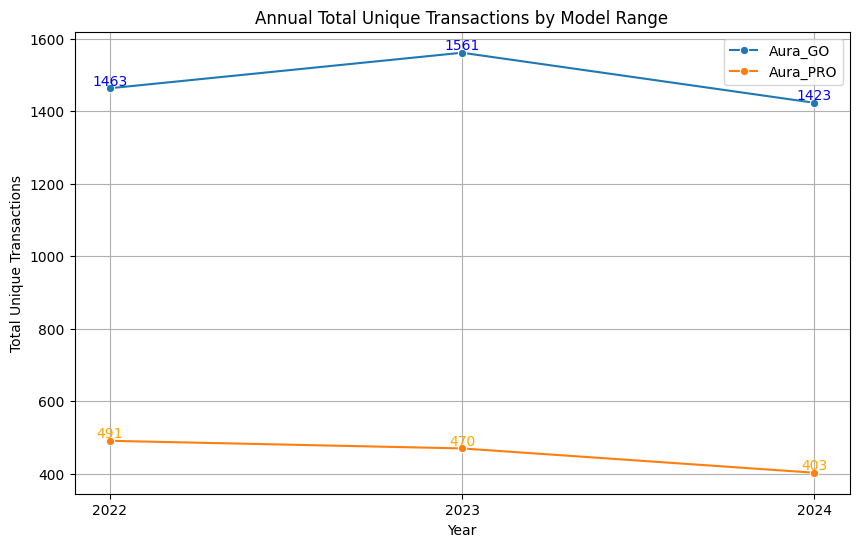

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.lineplot(x='transaction_year', y='total_unique_transactions', data=aura_go_transactions, marker='o', label='Aura_GO')
sns.lineplot(x='transaction_year', y='total_unique_transactions', data=aura_pro_transactions, marker='o', label='Aura_PRO')

# Add data labels for Aura_GO
for index, row in aura_go_transactions.iterrows():
    plt.text(row['transaction_year'], row['total_unique_transactions'], f"{row['total_unique_transactions']}",
             color='blue', ha="center", va="bottom")

# Add data labels for Aura_PRO
for index, row in aura_pro_transactions.iterrows():
    plt.text(row['transaction_year'], row['total_unique_transactions'], f"{row['total_unique_transactions']}",
             color='orange', ha="center", va="bottom")

plt.title('Annual Total Unique Transactions by Model Range')
plt.xlabel('Year')
plt.ylabel('Total Unique Transactions')
plt.xticks(annual_transactions_customers_by_model['transaction_year'].unique()) # Ensure all years are shown as integer ticks
plt.legend()
plt.grid(True)
plt.show()

CHART_Range | Build a liner charts with annual dynamics of Aura_Go and Aura_Pro by 2) total customer_id, add data labels to the chart

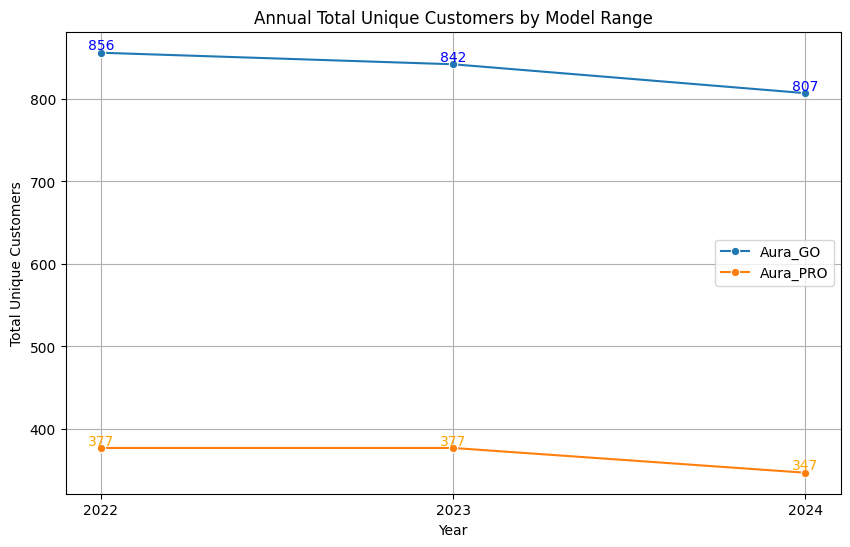

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.lineplot(x='transaction_year', y='total_unique_customers', data=aura_go_transactions, marker='o', label='Aura_GO')
sns.lineplot(x='transaction_year', y='total_unique_customers', data=aura_pro_transactions, marker='o', label='Aura_PRO')

# Add data labels for Aura_GO
for index, row in aura_go_transactions.iterrows():
    plt.text(row['transaction_year'], row['total_unique_customers'], f"{row['total_unique_customers']}",
             color='blue', ha="center", va="bottom")

# Add data labels for Aura_PRO
for index, row in aura_pro_transactions.iterrows():
    plt.text(row['transaction_year'], row['total_unique_customers'], f"{row['total_unique_customers']}",
             color='orange', ha="center", va="bottom")

plt.title('Annual Total Unique Customers by Model Range')
plt.xlabel('Year')
plt.ylabel('Total Unique Customers')
plt.xticks(annual_transactions_customers_by_model['transaction_year'].unique()) # Ensure all years are shown as integer ticks
plt.legend()
plt.grid(True)
plt.show()

CHART_Range | Build a liner charts with annual dynamics of Aura_Go and Aura_Pro by 3) total reatil_price, add data labels to the chart

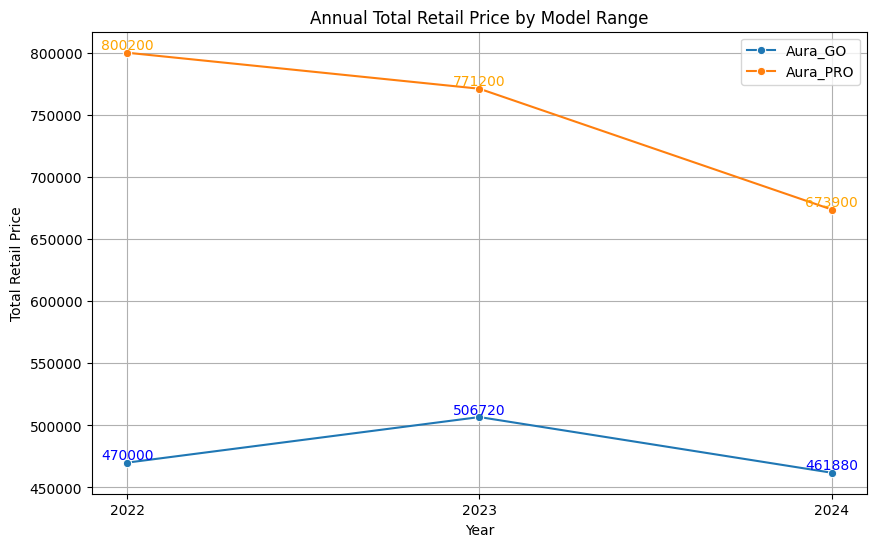

In [ ]:
annual_retail_price_by_model = df.groupby(['transaction_year', 'model_range'])['retail_price'].sum().reset_index()
annual_retail_price_by_model.columns = ['transaction_year', 'model_range', 'total_retail_price']

aura_go_retail_price = annual_retail_price_by_model[annual_retail_price_by_model['model_range'] == 'Aura_GO'].reset_index(drop=True)
aura_pro_retail_price = annual_retail_price_by_model[annual_retail_price_by_model['model_range'] == 'Aura_PRO'].reset_index(drop=True)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.lineplot(x='transaction_year', y='total_retail_price', data=aura_go_retail_price, marker='o', label='Aura_GO')
sns.lineplot(x='transaction_year', y='total_retail_price', data=aura_pro_retail_price, marker='o', label='Aura_PRO')

# Add data labels for Aura_GO
for index, row in aura_go_retail_price.iterrows():
    plt.text(row['transaction_year'], row['total_retail_price'], f"{row['total_retail_price']:.0f}",
             color='blue', ha="center", va="bottom")

# Add data labels for Aura_PRO
for index, row in aura_pro_retail_price.iterrows():
    plt.text(row['transaction_year'], row['total_retail_price'], f"{row['total_retail_price']:.0f}",
             color='orange', ha="center", va="bottom")

plt.title('Annual Total Retail Price by Model Range')
plt.xlabel('Year')
plt.ylabel('Total Retail Price')
plt.xticks(annual_retail_price_by_model['transaction_year'].unique()) # Ensure all years are shown as integer ticks
plt.legend()
plt.grid(True)
plt.show()

CHART_Range | Build a liner charts with annual dynamics of Aura_Go and Aura_Pro by 4) average weighted gross_margin_%, add data labels to the chart

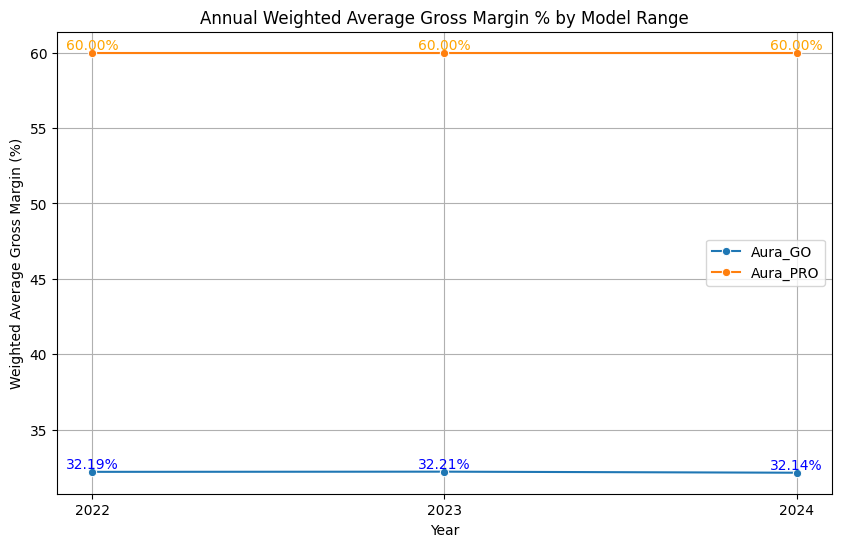

In [ ]:
annual_gross_margin_by_model = df.groupby(['transaction_year', 'model_range']).agg(
    total_gross_margin_abs=('gross_margin_abs', 'sum'),
    total_retail_price=('retail_price', 'sum')
).reset_index()

annual_gross_margin_by_model['weighted_avg_gross_margin_%'] = (
    annual_gross_margin_by_model['total_gross_margin_abs'] / annual_gross_margin_by_model['total_retail_price']
) * 100

aura_go_gross_margin = annual_gross_margin_by_model[annual_gross_margin_by_model['model_range'] == 'Aura_GO'].reset_index(drop=True)
aura_pro_gross_margin = annual_gross_margin_by_model[annual_gross_margin_by_model['model_range'] == 'Aura_PRO'].reset_index(drop=True)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.lineplot(x='transaction_year', y='weighted_avg_gross_margin_%', data=aura_go_gross_margin, marker='o', label='Aura_GO')
sns.lineplot(x='transaction_year', y='weighted_avg_gross_margin_%', data=aura_pro_gross_margin, marker='o', label='Aura_PRO')

# Add data labels for Aura_GO
for index, row in aura_go_gross_margin.iterrows():
    plt.text(row['transaction_year'], row['weighted_avg_gross_margin_%'], f"{row['weighted_avg_gross_margin_%']:.2f}%",
             color='blue', ha="center", va="bottom")

# Add data labels for Aura_PRO
for index, row in aura_pro_gross_margin.iterrows():
    plt.text(row['transaction_year'], row['weighted_avg_gross_margin_%'], f"{row['weighted_avg_gross_margin_%']:.2f}%",
             color='orange', ha="center", va="bottom")

plt.title('Annual Weighted Average Gross Margin % by Model Range')
plt.xlabel('Year')
plt.ylabel('Weighted Average Gross Margin (%)')
plt.xticks(annual_gross_margin_by_model['transaction_year'].unique()) # Ensure all years are shown as integer ticks
plt.legend()
plt.grid(True)
plt.show()

TAB_Range | Build a table with columns by each year and cumulative total for all periods where in rows will be data for Aura_GO and Aura_PRO and total both ranges by parameters: 1) total retail_price 2) total transaction_id 3) total customer_id 4) total gross_magin_abs 5) average number of transaction_id per customer_id 6) average retail_price per customer_id 7) total average weighted gross_margin_% 8) total average weighted gross_margin_% per customer_id    

In [ ]:
annual_metrics_by_model_range['avg_transactions_per_customer'] = (
    annual_metrics_by_model_range['total_unique_transactions'] /
    annual_metrics_by_model_range['total_unique_customers']
)
annual_metrics_by_model_range['avg_retail_price_per_customer'] = (
    annual_metrics_by_model_range['total_retail_price'] /
    annual_metrics_by_model_range['total_unique_customers']
)
annual_metrics_by_model_range['avg_gross_margin_abs_per_customer'] = (
    annual_metrics_by_model_range['total_gross_margin_abs'] /
    annual_metrics_by_model_range['total_unique_customers']
)
display(annual_metrics_by_model_range.head())

,transaction_year,model_range,total_retail_price,total_unique_transactions,total_unique_customers,total_gross_margin_abs,weighted_avg_gross_margin_%,avg_transactions_per_customer,avg_retail_price_per_customer,avg_gross_margin_abs_per_customer
0,2022,Aura_GO,470000,1463,856,151312.2,32.194085,1.709112,549.065421,176.766589
1,2022,Aura_PRO,800200,491,377,480120.0,60.000000,1.302387,2122.546419,1273.527851
2,2023,Aura_GO,506720,1561,842,163194.6,32.206070,1.853919,601.805226,193.817815
3,2023,Aura_PRO,771200,470,377,462720.0,60.000000,1.246684,2045.623342,1227.374005
4,2024,Aura_GO,461880,1423,807,148428.6,32.135750,1.763321,572.342007,183.926394


In [ ]:
cumulative_metrics_by_model_range['avg_transactions_per_customer'] = (
    cumulative_metrics_by_model_range['total_unique_transactions'] /
    cumulative_metrics_by_model_range['total_unique_customers']
)
cumulative_metrics_by_model_range['avg_retail_price_per_customer'] = (
    cumulative_metrics_by_model_range['total_retail_price'] /
    cumulative_metrics_by_model_range['total_unique_customers']
)
cumulative_metrics_by_model_range['avg_gross_margin_abs_per_customer'] = (
    cumulative_metrics_by_model_range['total_gross_margin_abs'] /
    cumulative_metrics_by_model_range['total_unique_customers']
)
display(cumulative_metrics_by_model_range.head())

,model_range,total_retail_price,total_unique_transactions,total_unique_customers,total_gross_margin_abs,weighted_avg_gross_margin_%,avg_transactions_per_customer,avg_retail_price_per_customer,avg_gross_margin_abs_per_customer
0,Aura_GO,1438600,4447,1194,462935.4,32.179577,3.724456,1204.857621,387.718090
1,Aura_PRO,2245300,1364,773,1347180.0,60.000000,1.764554,2904.657180,1742.794308


In [ ]:
annual_total_both_ranges = annual_metrics_by_model_range.groupby('transaction_year').agg(
    total_retail_price=('total_retail_price', 'sum'),
    total_unique_transactions=('total_unique_transactions', 'sum'),
    total_unique_customers=('total_unique_customers', 'sum'),
    total_gross_margin_abs=('total_gross_margin_abs', 'sum')
).reset_index()

annual_total_both_ranges['weighted_avg_gross_margin_%'] = (
    annual_total_both_ranges['total_gross_margin_abs'] /
    annual_total_both_ranges['total_retail_price']
) * 100

annual_total_both_ranges['avg_transactions_per_customer'] = (
    annual_total_both_ranges['total_unique_transactions'] /
    annual_total_both_ranges['total_unique_customers']
)
annual_total_both_ranges['avg_retail_price_per_customer'] = (
    annual_total_both_ranges['total_retail_price'] /
    annual_total_both_ranges['total_unique_customers']
)
annual_total_both_ranges['avg_gross_margin_abs_per_customer'] = (
    annual_total_both_ranges['total_gross_margin_abs'] /
    annual_total_both_ranges['total_unique_customers']
)

annual_total_both_ranges['model_range'] = 'Total (Both Ranges)'

display(annual_total_both_ranges.head())

,transaction_year,total_retail_price,total_unique_transactions,total_unique_customers,total_gross_margin_abs,weighted_avg_gross_margin_%,avg_transactions_per_customer,avg_retail_price_per_customer,avg_gross_margin_abs_per_customer,model_range
0,2022,1270200,1954,1233,631432.2,49.711242,1.584753,1030.170316,512.110462,Total (Both Ranges)
1,2023,1277920,2031,1219,625914.6,48.979169,1.666120,1048.334701,513.465628,Total (Both Ranges)
2,2024,1135780,1826,1154,552768.6,48.668633,1.582322,984.211438,479.002253,Total (Both Ranges)


In [ ]:
annual_metrics_by_model_range['transaction_year'] = annual_metrics_by_model_range['transaction_year'].astype(str)
cumulative_metrics_by_model_range['transaction_year'] = 'Cumulative Total'

final_combined_metrics = pd.concat([
    annual_metrics_by_model_range,
    annual_total_both_ranges,
    cumulative_metrics_by_model_range,
    cumulative_total_both_ranges
], ignore_index=True)

display(final_combined_metrics.head())

,transaction_year,model_range,total_retail_price,total_unique_transactions,total_unique_customers,total_gross_margin_abs,weighted_avg_gross_margin_%,avg_transactions_per_customer,avg_retail_price_per_customer,avg_gross_margin_abs_per_customer
0,2022,Aura_GO,470000,1463,856,151312.2,32.194085,1.709112,549.065421,176.766589
1,2022,Aura_PRO,800200,491,377,480120.0,60.000000,1.302387,2122.546419,1273.527851
2,2023,Aura_GO,506720,1561,842,163194.6,32.206070,1.853919,601.805226,193.817815
3,2023,Aura_PRO,771200,470,377,462720.0,60.000000,1.246684,2045.623342,1227.374005
4,2024,Aura_GO,461880,1423,807,148428.6,32.135750,1.763321,572.342007,183.926394


Build the table where columns represent 2022 and 2024 years and product_id (GO Range) represents in rows, calculate by total transaction_id


In [87]:
transactions_diff = pd.merge(
    transactions_2024.rename(columns={'transaction_count': 'count_2024'}),
    transactions_2022.rename(columns={'transaction_count': 'count_2022'}),
    on=['product_id', 'region_code'],
    how='outer'
).fillna(0)

transactions_diff['difference'] = transactions_diff['count_2024'] - transactions_diff['count_2022']

print("Difference in transaction counts (2024 vs 2022) by product_id and region_code:")
display(transactions_diff.head())

Difference in transaction counts (2024 vs 2022) by product_id and region_code:


,product_id,region_code,count_2024,count_2022,difference
0,GO_ACTIVE,EU,54,59,-5
1,GO_ACTIVE,MW,71,64,7
2,GO_ACTIVE,NE,60,65,-5
3,GO_ACTIVE,SE,52,62,-10
4,GO_ACTIVE,SW,50,41,9


#---PRODUCT PERCEPTION | Build a clutter map where x-axis is high quality and y-axis is high aesthetic and values are represented by an average product_id score

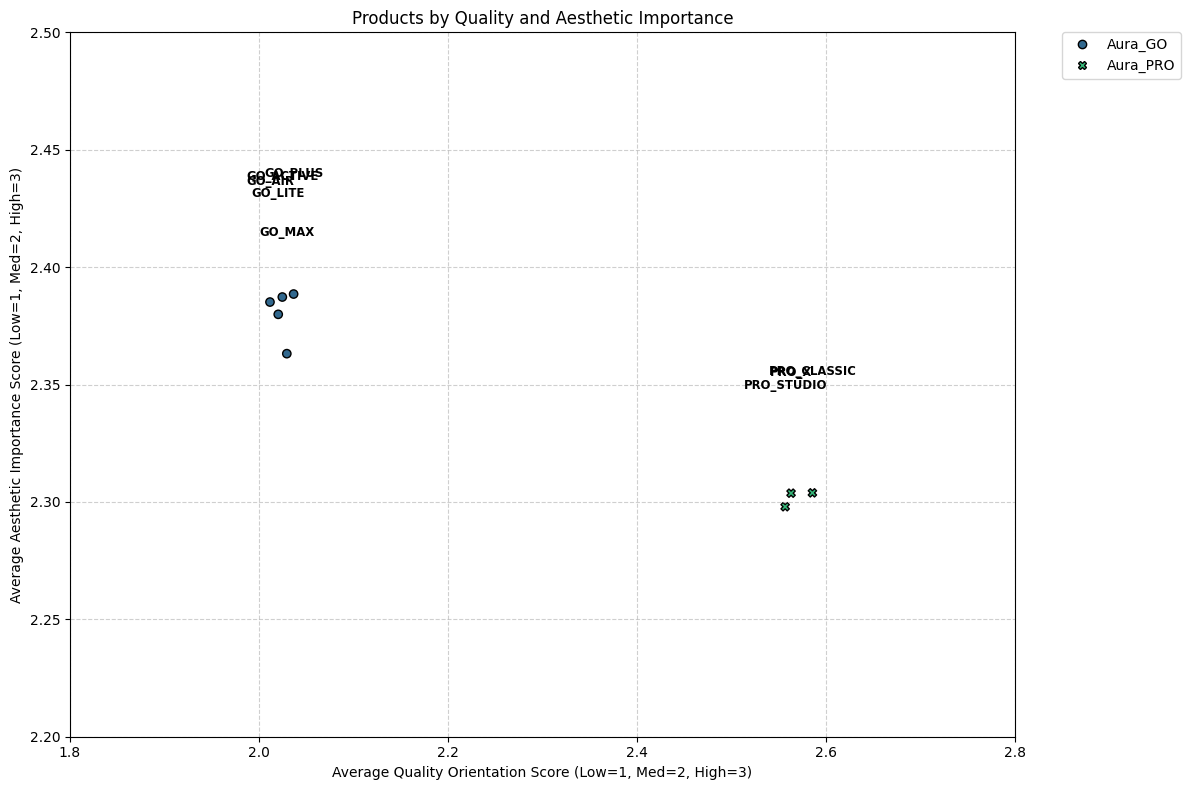

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Ensure original_full_df is available from previous steps
# (Assuming 'original_full_df' is already loaded and pre-processed)

# Define numerical scores for importance levels
importance_scores = {'Low': 1, 'Med': 2, 'High': 3}

# Map original categorical values to numerical scores in original_full_df
original_full_df['quality_score'] = original_full_df['quality_orientation'].map(importance_scores)
original_full_df['aesthetic_score'] = original_full_df['aesthetic_importance'].map(importance_scores)

# Calculate the average scores for each product_id
product_scores = original_full_df.groupby('product_id').agg(
    avg_quality_score=('quality_score', 'mean'),
    avg_aesthetic_score=('aesthetic_score', 'mean'),
    avg_review_star=('review_star', 'mean')
).reset_index()

# Ensure 'model_range' is available to potentially color-code products
# Re-create model_range in original_full_df if it's not there
if 'model_range' not in original_full_df.columns:
    aura_go_products = ['GO_ACTIVE', 'GO_AIR', 'GO_LITE', 'GO_MAX', 'GO_PLUS']
    aura_pro_products = ['PRO_CLASSIC', 'PRO_STUDIO', 'PRO_X']
    original_full_df['model_range'] = np.select(
        [
            original_full_df['product_id'].isin(aura_go_products),
            original_full_df['product_id'].isin(aura_pro_products)
        ],
        [
            'Aura_GO',
            'Aura_PRO'
        ],
        default='Other'
    )
product_scores = product_scores.merge(original_full_df[['product_id', 'model_range']].drop_duplicates(), on='product_id', how='left')

# Create the bubble chart
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=product_scores,
    x='avg_quality_score',
    y='avg_aesthetic_score',
    hue='model_range', # Color by model range (GO vs PRO)
    style='model_range', # Differentiate markers by model range
    palette='viridis', # Color palette
    edgecolor='black', # Border around points
    linewidth=1
)

# Add product_id as labels to the bubbles
for index, row in product_scores.iterrows():
    plt.text(
        row['avg_quality_score'],
        row['avg_aesthetic_score'] + 0.05, # Offset label slightly above the bubble
        row['product_id'],
        horizontalalignment='center',
        size='small',
        color='black',
        weight='semibold'
    )

# Set labels and title
plt.title('Products by Quality and Aesthetic Importance')
plt.xlabel('Average Quality Orientation Score (Low=1, Med=2, High=3)')
plt.ylabel('Average Aesthetic Importance Score (Low=1, Med=2, High=3)')

# Set x and y axis limits for better visualization, based on score range
plt.xlim(1.8, 2.8)
plt.ylim(2.2, 2.5)

# Add grid for readability
plt.grid(True, linestyle='--', alpha=0.6)

# Move legend outside the plot area
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

plt.tight_layout()
plt.show()

Build the table where regions are columns and average brand_affinity_score and average review stars are in rows. values are represented by difference between 2024 and 2022

In [112]:
df_2022 = df[df['transaction_year'] == 2022]

metrics_2022 = df_2022.groupby('region_code')[['brand_affinity_score', 'review_star']].mean().reset_index()

print("Average brand_affinity_score and review_star by region for 2022:")
display(metrics_2022.head())

Average brand_affinity_score and review_star by region for 2022:


,region_code,brand_affinity_score,review_star
0,EU,3.551282,4.176532
1,MW,3.613187,4.192840
2,NE,3.485839,4.211348
3,SE,3.629797,4.163333
4,SW,3.596154,4.273681


In [113]:
df_2024 = df[df['transaction_year'] == 2024]

metrics_2024 = df_2024.groupby('region_code')[['brand_affinity_score', 'review_star']].mean().reset_index()

print("Average brand_affinity_score and review_star by region for 2024:")
display(metrics_2024.head())

Average brand_affinity_score and review_star by region for 2024:


,region_code,brand_affinity_score,review_star
0,EU,3.580475,4.189521
1,MW,3.464444,4.222956
2,NE,3.513580,4.165000
3,SE,3.485646,4.179800
4,SW,3.478827,4.220404


In [114]:
difference_metrics = pd.merge(
    metrics_2024.rename(columns={'brand_affinity_score': 'brand_affinity_score_2024', 'review_star': 'review_star_2024'}),
    metrics_2022.rename(columns={'brand_affinity_score': 'brand_affinity_score_2022', 'review_star': 'review_star_2022'}),
    on='region_code',
    how='outer'
).fillna(0)

difference_metrics['brand_affinity_score_difference'] = difference_metrics['brand_affinity_score_2024'] - difference_metrics['brand_affinity_score_2022']
difference_metrics['review_star_difference'] = difference_metrics['review_star_2024'] - difference_metrics['review_star_2022']

# Prepare the final table by selecting difference columns and pivoting
final_difference_table = difference_metrics.pivot_table(
    index='region_code',
    values=['brand_affinity_score_difference', 'review_star_difference']
).T

# Rename the index for clarity
final_difference_table = final_difference_table.rename(index={
    'brand_affinity_score_difference': 'Brand Affinity Score Difference (2024 vs 2022)',
    'review_star_difference': 'Review Star Difference (2024 vs 2022)'
})

# Apply formatting for display
styled_table = final_difference_table.style.format(
    lambda x: f"{x:.3f}" if pd.notna(x) else ''
)

print("Table showing the difference in average brand_affinity_score and review_star by region (2024 - 2022):")
display(styled_table)

Table showing the difference in average brand_affinity_score and review_star by region (2024 - 2022):


region_code,EU,MW,NE,SE,SW,W
Brand Affinity Score Difference (2024 vs 2022),0.029,-0.149,0.028,-0.144,-0.117,-0.065
Review Star Difference (2024 vs 2022),0.013,0.030,-0.046,0.016,-0.053,0.021


SUMMARY for Range Performance:

Q&A
The comprehensive table summarizing annual and cumulative metrics for 'Aura\_GO', 'Aura\_PRO', and 'Total (Both Ranges)' has been successfully generated. For each intersection of year/cumulative total and model range, the table displays total retail price, total unique transactions, total unique customers, total gross margin (absolute), average number of unique transactions per unique customer, average retail price per unique customer, total average weighted gross margin percentage, and total average weighted gross margin percentage per unique customer, all properly formatted for readability.

Data Analysis Key Findings
*   **Aura\_GO Performance**: Total retail price for Aura\_GO peaked in 2023 at \$506,720, decreasing to \$461,880 in 2024, with a cumulative total of \$1,438,600. Unique transactions followed a similar trend, peaking at 1,561 in 2023. The weighted average gross margin percentage remained stable around 32.1% - 32.2% across all years.
*   **Aura\_PRO Performance**: Total retail price for Aura\_PRO showed a consistent decline from \$800,200 in 2022 to \$673,900 in 2024, with a cumulative total of \$2,245,300. Unique transactions also decreased consistently. The weighted average gross margin percentage remained consistently high at 60.00% across all years.
*   **Overall Market Trends (Both Ranges)**: The combined total retail price peaked in 2023 at \$1,277,920 before significantly dropping to \$1,135,780 in 2024. Total unique transactions also peaked in 2023 (2,031) and declined in 2024 (1,826). The cumulative total retail price is \$3,683,900.
*   **Profitability**: Aura\_PRO maintains a significantly higher and more stable gross margin percentage (60%) compared to Aura\_GO (around 32%).
*   **Customer Engagement**: Aura\_GO shows higher average transactions per customer (cumulative 3.72) than Aura\_PRO (cumulative 1.76), suggesting better customer retention or repeat purchases for the Aura\_GO segment.
*   **Decline in 2024**: The overall decline in retail price, unique transactions, and unique customers in 2024 is driven by both product ranges, but the decline is more pronounced in Aura\_PRO.

Insights or Next Steps
*   Investigate the causes of the consistent decline in Aura\_PRO sales and unique customers, despite its high gross margin, to strategize potential market recovery or product adjustments.
*   Explore opportunities to enhance the gross margin of Aura\_GO products, given its more resilient transaction volume and customer engagement, to capitalize on its broader customer base.


#GM_VARIANCE | Build gross margin variance analysis and build waterfal or bridge chart represents difference betwee 2024 and 2022 and drivers which include drivers 1) number of customers (customer_id) 2) number of transactions (transaction_id) per customer 3) amount of purchase (retail_price) per customer 4) gross_margin_%. Shw me results for Aura_PRO, Aura_GO and total

Comparing years: 2022 → 2024

===== Segment: TOTAL =====
Year 2022 metrics: {'transactions': 2453, 'customers': 1034, 'tx_per_customer': 2.372340425531915, 'total_revenue': np.int64(1270200), 'total_gross_profit': np.float64(631432.2), 'avg_revenue_per_tx': np.float64(517.8149205055034), 'weighted_gm_pct': np.float64(49.71124232404346)}
Year 2024 metrics: {'transactions': 2346, 'customers': 961, 'tx_per_customer': 2.441207075962539, 'total_revenue': np.int64(1135780), 'total_gross_profit': np.float64(552768.6000000001), 'avg_revenue_per_tx': np.float64(484.1346973572038), 'weighted_gm_pct': np.float64(48.66863300991389)}
Driver effects: {'GP_base': np.float64(63143220.00000001), 'customer_id_effect': np.float64(-4457886.905222446), 'tx_per_customer_effect': np.float64(1703576.045051217), 'retail_price_per_tx_effect': np.float64(-3927874.3330266997), 'gross_margin_pct_effect': np.float64(-1184174.806802079), 'GP_final': np.float64(55276860.0)}


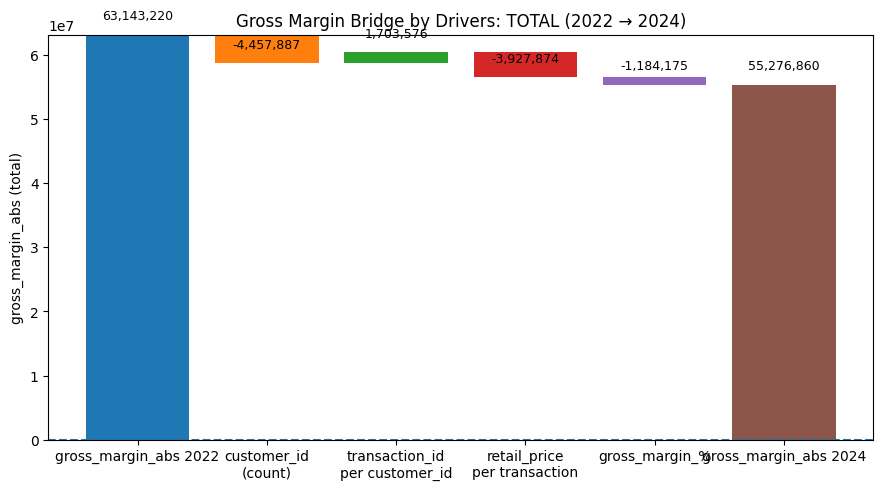


===== Segment: Aura_GO =====
Year 2022 metrics: {'transactions': 1869, 'customers': 856, 'tx_per_customer': 2.183411214953271, 'total_revenue': np.int64(470000), 'total_gross_profit': np.float64(151312.19999999998), 'avg_revenue_per_tx': np.float64(251.47137506688068), 'weighted_gm_pct': np.float64(32.19408510638298)}
Year 2024 metrics: {'transactions': 1855, 'customers': 807, 'tx_per_customer': 2.298636926889715, 'total_revenue': np.int64(461880), 'total_gross_profit': np.float64(148428.59999999998), 'avg_revenue_per_tx': np.float64(248.99191374663073), 'weighted_gm_pct': np.float64(32.13574954533645)}
Driver effects: {'GP_base': np.float64(15131220.000000002), 'customer_id_effect': np.float64(-866156.285046732), 'tx_per_customer_effect': np.float64(752813.8131366167), 'retail_price_per_tx_effect': np.float64(-148073.4991537165), 'gross_margin_pct_effect': np.float64(-26944.02893617004), 'GP_final': np.float64(14842860.0)}


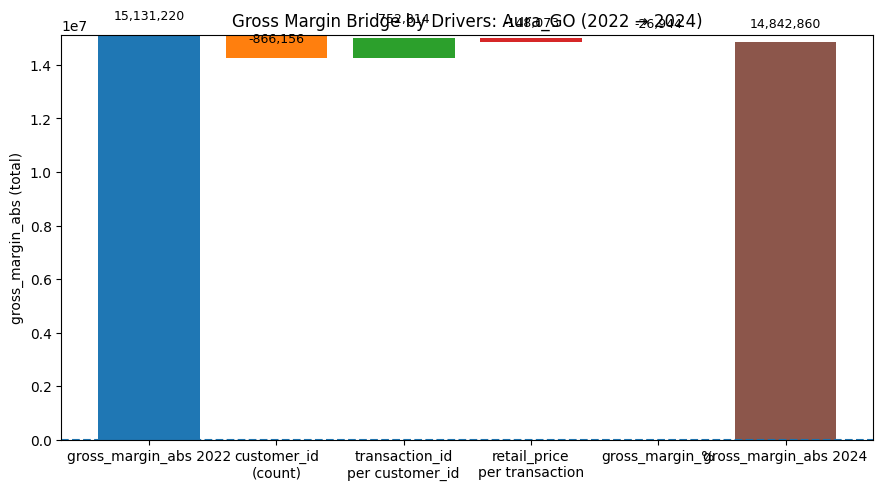


===== Segment: Aura_PRO =====
Year 2022 metrics: {'transactions': 584, 'customers': 377, 'tx_per_customer': 1.5490716180371353, 'total_revenue': np.int64(800200), 'total_gross_profit': np.float64(480120.0), 'avg_revenue_per_tx': np.float64(1370.2054794520548), 'weighted_gm_pct': np.float64(60.0)}
Year 2024 metrics: {'transactions': 491, 'customers': 347, 'tx_per_customer': 1.414985590778098, 'total_revenue': np.int64(673900), 'total_gross_profit': np.float64(404340.0), 'avg_revenue_per_tx': np.float64(1372.5050916496946), 'weighted_gm_pct': np.float64(60.0)}
Driver effects: {'GP_base': np.float64(48012000.0), 'customer_id_effect': np.float64(-3820583.5543766543), 'tx_per_customer_effect': np.float64(-3825163.0209658146), 'retail_price_per_tx_effect': np.float64(67746.57534246892), 'gross_margin_pct_effect': np.float64(0.0), 'GP_final': np.float64(40434000.0)}


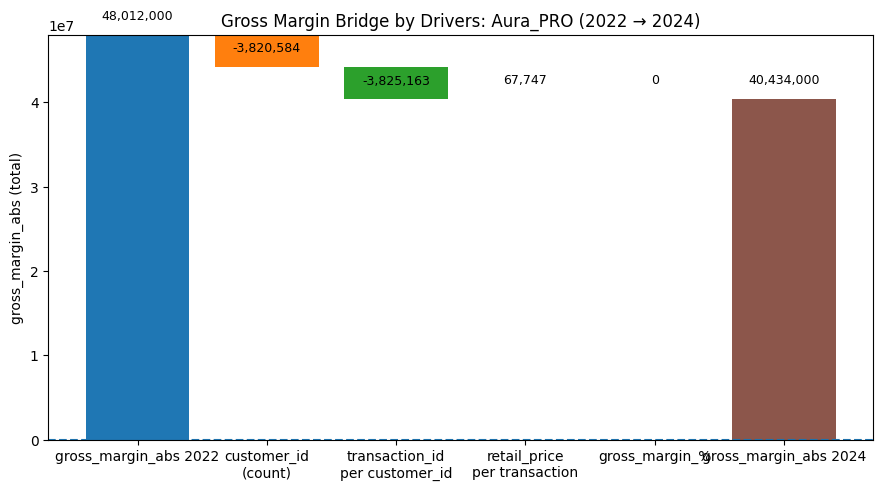

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ================================
# 1. Helper: compute metrics per year
# ================================

def compute_year_metrics(df, year):
    """
    Compute key metrics for a given year using existing columns:
    - total number of transactions
    - total number of unique customers
    - transactions per customer_id
    - total retail revenue (sum of retail_price)
    - total gross profit (sum of gross_margin_abs)
    - average retail_price per transaction
    - weighted average gross_margin_% (weighted by retail_price)
    """

    d = df[df['transaction_year'] == year].copy()

    if d.empty:
        raise ValueError(f"No data found for year {year}")

    total_transactions = len(d)
    unique_customers = d['customer_id'].nunique()
    tx_per_customer = total_transactions / unique_customers if unique_customers > 0 else 0

    total_revenue = d['retail_price'].sum()
    total_gross_profit = d['gross_margin_abs'].sum()

    avg_revenue_per_tx = total_revenue / total_transactions if total_transactions > 0 else 0

    if total_revenue > 0:
        weighted_gm_pct = np.average(d['gross_margin_%'], weights=d['retail_price'])
    else:
        weighted_gm_pct = 0

    return {
        "transactions": total_transactions,          # proxy for transaction_id count
        "customers": unique_customers,               # customer_id count
        "tx_per_customer": tx_per_customer,          # transaction_id per customer_id
        "total_revenue": total_revenue,              # sum of retail_price
        "total_gross_profit": total_gross_profit,    # sum of gross_margin_abs
        "avg_revenue_per_tx": avg_revenue_per_tx,    # retail_price per transaction
        "weighted_gm_pct": weighted_gm_pct           # gross_margin_%
    }

# ================================
# 2. Helper: decompose drivers
# ================================

def decompose_drivers(m0, m1):
    """
    Decompose the change in gross profit (gross_margin_abs total)
    into four drivers, linked to variable logic:

    - customer_id effect           (change in number of customers)
    - transaction_id per customer  (change in tx_per_customer)
    - retail_price per transaction (change in avg_revenue_per_tx)
    - gross_margin_% effect        (change in weighted_gm_pct)

    Using driver model:
    gross_margin_abs ≈
        customers (customer_id)
      × transactions per customer_id
      × retail_price per transaction
      × gross_margin_%
    """

    C0, F0, P0, M0 = m0['customers'], m0['tx_per_customer'], m0['avg_revenue_per_tx'], m0['weighted_gm_pct']
    C1, F1, P1, M1 = m1['customers'], m1['tx_per_customer'], m1['avg_revenue_per_tx'], m1['weighted_gm_pct']

    # Base gross profit for year 0 (model-based)
    GP0 = C0 * F0 * P0 * M0

    # Step-by-step decomposition
    GP_customers = C1 * F0 * P0 * M0
    GP_frequency = C1 * F1 * P0 * M0
    GP_price     = C1 * F1 * P1 * M0
    GP_margin    = C1 * F1 * P1 * M1

    customer_id_effect          = GP_customers - GP0
    tx_per_customer_effect      = GP_frequency - GP_customers
    retail_price_per_tx_effect  = GP_price - GP_frequency
    gross_margin_pct_effect     = GP_margin - GP_price

    return {
        "GP_base": GP0,
        "customer_id_effect":         customer_id_effect,
        "tx_per_customer_effect":     tx_per_customer_effect,
        "retail_price_per_tx_effect": retail_price_per_tx_effect,
        "gross_margin_pct_effect":    gross_margin_pct_effect,
        "GP_final":                   GP_margin
    }

# ================================
# 3. Helper: plot waterfall for a segment (with numeric labels)
# ================================

def plot_waterfall_for_segment(segment_name, year_0, year_1, drivers):
    """
    Plot a waterfall chart for gross_margin_abs change
    for a given segment between two years.

    Bars:
    - gross_margin_abs (Year 0)
    - customer_id (effect)
    - transaction_id per customer_id (effect)
    - retail_price per transaction (effect)
    - gross_margin_% (effect)
    - gross_margin_abs (Year 1)
    """
    GP_base   = drivers['GP_base']
    GP_final  = drivers['GP_final']
    ce        = drivers['customer_id_effect']
    fe        = drivers['tx_per_customer_effect']
    pe        = drivers['retail_price_per_tx_effect']
    me        = drivers['gross_margin_pct_effect']

    labels = [
        f"gross_margin_abs {year_0}",
        "customer_id\n(count)",
        "transaction_id\nper customer_id",
        "retail_price\nper transaction",
        "gross_margin_%",
        f"gross_margin_abs {year_1}"
    ]

    effects = [ce, fe, pe, me]
    values = [GP_base, ce, fe, pe, me, GP_final]

    # Cumulative levels after each effect (for bar bottoms)
    totals = [GP_base]
    for eff in effects:
        totals.append(totals[-1] + eff)
    # totals[-1] ≈ GP_final

    plt.figure(figsize=(9, 5))

    # For positioning numeric labels
    all_vals = [GP_base, GP_final] + effects
    y_range = max(abs(v) for v in all_vals) if all_vals else 1
    label_offset = y_range * 0.03  # small vertical offset

    for i, label in enumerate(labels):
        if i == 0:
            # First bar: base gross_margin_abs (absolute level)
            bottom = 0
            height = GP_base
            bar_value = GP_base
        elif i == len(labels) - 1:
            # Last bar: final gross_margin_abs (absolute level)
            bottom = 0
            height = GP_final
            bar_value = GP_final
        else:
            # Intermediate bars: driver effects (deltas)
            effect_index = i - 1  # 0..3
            bottom = totals[effect_index]
            height = effects[effect_index]
            bar_value = height   # show delta value for drivers

        bar = plt.bar(label, height, bottom=bottom)[0]

        # Numeric label above each bar
        x = bar.get_x() + bar.get_width() / 2
        y = bottom + height
        plt.text(
            x,
            y + (label_offset if y >= 0 else -label_offset),
            f"{bar_value:,.0f}",
            ha='center',
            va='bottom' if y >= 0 else 'top',
            fontsize=9
        )

    plt.axhline(0, linestyle='--')
    plt.ylabel("gross_margin_abs (total)")
    plt.title(f"Gross Margin Bridge by Drivers: {segment_name} ({year_0} → {year_1})")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

# ================================
# 4. Main logic: run for TOTAL, Aura_GO, Aura_PRO
# ================================

# If needed, ensure correct type
# df['transaction_year'] = df['transaction_year'].astype(int)

years_sorted = sorted(df['transaction_year'].unique())
if len(years_sorted) < 2:
    raise ValueError("Need at least two years in transaction_year to run YoY analysis.")

year_0 = years_sorted[0]
year_1 = years_sorted[-1]

print("Comparing years:", year_0, "→", year_1)

segments = {
    "TOTAL": df,
    "Aura_GO": df[df["model_range"] == "Aura_GO"],
    "Aura_PRO": df[df["model_range"] == "Aura_PRO"]
}

results = {}

for name, data in segments.items():
    if data.empty:
        print(f"Segment {name} has no data – skipping.")
        continue

    print(f"\n===== Segment: {name} =====")

    m0 = compute_year_metrics(data, year_0)
    m1 = compute_year_metrics(data, year_1)
    drivers = decompose_drivers(m0, m1)

    results[name] = {
        "year_0_metrics": m0,
        "year_1_metrics": m1,
        "driver_effects": drivers
    }

    print(f"Year {year_0} metrics:", m0)
    print(f"Year {year_1} metrics:", m1)
    print("Driver effects:", drivers)

    # Plot waterfall with numeric labels and variable-style names
    plot_waterfall_for_segment(name, year_0, year_1, drivers)

Combine it in a single chart


Comparing years: 2022 → 2024


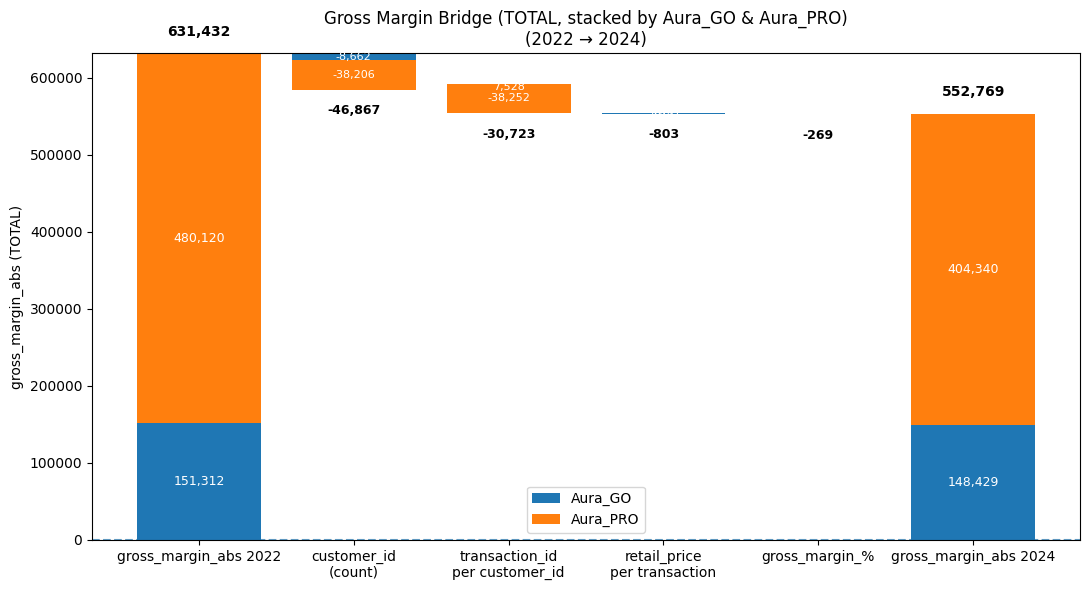

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =====================================================
# 1. Year-level metrics for a given segment (GO / PRO)
# =====================================================

def compute_year_metrics(df, year):
    """
    Compute key metrics for a given year using existing columns:
    - total number of transactions (proxy for transaction_id count)
    - total number of unique customers (customer_id)
    - transactions per customer_id
    - total retail revenue (sum of retail_price)
    - total gross profit (sum of gross_margin_abs)
    - average retail_price per transaction
    - weighted average gross_margin_% (weighted by retail_price)
    """

    d = df[df['transaction_year'] == year].copy()

    if d.empty:
        raise ValueError(f"No data found for year {year}")

    total_transactions = len(d)
    unique_customers   = d['customer_id'].nunique()
    tx_per_customer    = total_transactions / unique_customers if unique_customers > 0 else 0

    total_revenue      = d['retail_price'].sum()
    total_gross_profit = d['gross_margin_abs'].sum()

    avg_revenue_per_tx = total_revenue / total_transactions if total_transactions > 0 else 0

    if total_revenue > 0:
        weighted_gm_pct = np.average(d['gross_margin_%'], weights=d['retail_price'])
    else:
        weighted_gm_pct = 0

    return {
        "transactions":        total_transactions,
        "customers":           unique_customers,
        "tx_per_customer":     tx_per_customer,
        "total_revenue":       total_revenue,
        "total_gross_profit":  total_gross_profit,
        "avg_revenue_per_tx":  avg_revenue_per_tx,
        "weighted_gm_pct":     weighted_gm_pct
    }

# =====================================================
# 2. Driver decomposition with scaling to actual totals
# =====================================================

def decompose_drivers(m0, m1):
    """
    Decompose the change in gross profit (total_gross_profit)
    into four drivers linked to variables:

    - customer_id_effect           (change in number of customers)
    - tx_per_customer_effect       (change in transactions per customer_id)
    - retail_price_per_tx_effect   (change in avg retail_price per transaction)
    - gross_margin_pct_effect      (change in weighted gross_margin_%)

    Using multiplicative model:
        GP_model ≈ customers × tx_per_customer × avg_revenue_per_tx × gross_margin_%

    Then scale model-based effects so that:
        base  = actual total_gross_profit (year 0)
        final = actual total_gross_profit (year 1)
        sum of effects = actual change
    """
    C0, F0, P0, M0 = m0['customers'], m0['tx_per_customer'], m0['avg_revenue_per_tx'], m0['weighted_gm_pct']
    C1, F1, P1, M1 = m1['customers'], m1['tx_per_customer'], m1['avg_revenue_per_tx'], m1['weighted_gm_pct']

    # Actual totals
    actual_GP0   = m0['total_gross_profit']
    actual_GP1   = m1['total_gross_profit']
    actual_delta = actual_GP1 - actual_GP0

    # Model-based levels
    GP0_model         = C0 * F0 * P0 * M0
    GP_customers      = C1 * F0 * P0 * M0
    GP_frequency      = C1 * F1 * P0 * M0
    GP_price          = C1 * F1 * P1 * M0
    GP_margin         = C1 * F1 * P1 * M1

    # Model-based effects
    ce_model = GP_customers - GP0_model
    fe_model = GP_frequency - GP_customers
    pe_model = GP_price     - GP_frequency
    me_model = GP_margin    - GP_price

    model_delta = GP_margin - GP0_model

    if abs(model_delta) > 1e-9:
        scale = actual_delta / model_delta
        ce = ce_model * scale
        fe = fe_model * scale
        pe = pe_model * scale
        me = me_model * scale
    else:
        # If model delta is ~0, assign all change to margin
        ce, fe, pe, me = 0.0, 0.0, 0.0, actual_delta

    GP_base  = actual_GP0
    GP_final = GP_base + (ce + fe + pe + me)  # ≈ actual_GP1

    return {
        "GP_base":                   GP_base,
        "customer_id_effect":        ce,
        "tx_per_customer_effect":    fe,
        "retail_price_per_tx_effect":pe,
        "gross_margin_pct_effect":   me,
        "GP_final":                  GP_final
    }

# =====================================================
# 3. Compute drivers for GO and PRO separately
# =====================================================

def compute_segment_drivers(df, year_0, year_1):
    """
    Compute year metrics and driver decomposition
    for Aura_GO and Aura_PRO segments.
    """
    segments = {
        "Aura_GO": df[df["model_range"] == "Aura_GO"],
        "Aura_PRO": df[df["model_range"] == "Aura_PRO"]
    }

    seg_results = {}
    for name, data in segments.items():
        if data.empty:
            print(f"Segment {name} has no data – skipping.")
            continue

        m0 = compute_year_metrics(data, year_0)
        m1 = compute_year_metrics(data, year_1)
        drivers = decompose_drivers(m0, m1)

        seg_results[name] = {
            "year_0_metrics": m0,
            "year_1_metrics": m1,
            "driver_effects": drivers
        }
    return seg_results

# =====================================================
# 4. Plot combined waterfall: TOTAL stacked GO + PRO
# =====================================================

def plot_combined_driver_waterfall(df, year_0, year_1):
    """
    One waterfall chart where:
    - Each bar is TOTAL (gross_margin_abs), stacked from Aura_GO + Aura_PRO.
    - On year bars (year_0 and year_1) we show:
        - TOTAL gross_margin_abs on top
        - separate labels for Aura_GO and Aura_PRO inside the stack.
    - On driver bars we show:
        - TOTAL delta (bold label above)
        - separate labels for Aura_GO and Aura_PRO inside their parts of the bar.
    """

    seg_results = compute_segment_drivers(df, year_0, year_1)
    if "Aura_GO" not in seg_results or "Aura_PRO" not in seg_results:
        raise ValueError("Both Aura_GO and Aura_PRO must have data for this plot.")

    go  = seg_results["Aura_GO"]["driver_effects"]
    pro = seg_results["Aura_PRO"]["driver_effects"]

    # Base & final per segment
    base_GO,  base_PRO  = go["GP_base"],  pro["GP_base"]
    final_GO, final_PRO = go["GP_final"], pro["GP_final"]

    GP0_total = base_GO + base_PRO
    GP1_total = final_GO + final_PRO

    # Effects per segment
    go_ce,  pro_ce  = go["customer_id_effect"],         pro["customer_id_effect"]
    go_fe,  pro_fe  = go["tx_per_customer_effect"],     pro["tx_per_customer_effect"]
    go_pe,  pro_pe  = go["retail_price_per_tx_effect"], pro["retail_price_per_tx_effect"]
    go_me,  pro_me  = go["gross_margin_pct_effect"],    pro["gross_margin_pct_effect"]

    ce_total = go_ce + pro_ce
    fe_total = go_fe + pro_fe
    pe_total = go_pe + pro_pe
    me_total = go_me + pro_me

    labels = [
        f"gross_margin_abs {year_0}",
        "customer_id\n(count)",
        "transaction_id\nper customer_id",
        "retail_price\nper transaction",
        "gross_margin_%",
        f"gross_margin_abs {year_1}"
    ]

    # TOTAL bottoms for driver bars
    bottoms_total = [
        0,
        GP0_total,
        GP0_total + ce_total,
        GP0_total + ce_total + fe_total,
        GP0_total + ce_total + fe_total + pe_total,
        0
    ]

    go_effects  = [go_ce,  go_fe,  go_pe,  go_me]
    pro_effects = [pro_ce, pro_fe, pro_pe, pro_me]
    total_effects = [ce_total, fe_total, pe_total, me_total]

    all_vals = [GP0_total, GP1_total] + total_effects
    max_abs = max(abs(v) for v in all_vals) if all_vals else 1
    label_offset = max_abs * 0.03

    colors = {"GO": "#1f77b4", "PRO": "#ff7f0e"}

    plt.figure(figsize=(11, 6))

    for i, label in enumerate(labels):

        if i == 0:
            # Base year bar: absolute levels for GO and PRO
            go_h = base_GO
            pro_h = base_PRO
            go_bottom = 0
            pro_bottom = go_bottom + go_h

            plt.bar(i, go_h, bottom=go_bottom, color=colors["GO"], label="Aura_GO")
            plt.bar(i, pro_h, bottom=pro_bottom, color=colors["PRO"], label="Aura_PRO")

            total_y = go_bottom + go_h + pro_h
            # TOTAL label
            plt.text(i, total_y + label_offset, f"{GP0_total:,.0f}",
                     ha="center", va="bottom", fontsize=10, fontweight="bold")
            # Product-level labels
            plt.text(i, go_bottom + go_h / 2, f"{go_h:,.0f}",
                     ha="center", va="center", fontsize=9, color="white")
            plt.text(i, pro_bottom + pro_h / 2, f"{pro_h:,.0f}",
                     ha="center", va="center", fontsize=9, color="white")

        elif i == len(labels) - 1:
            # Final year bar: absolute levels for GO and PRO
            go_h = final_GO
            pro_h = final_PRO
            go_bottom = 0
            pro_bottom = go_bottom + go_h

            plt.bar(i, go_h, bottom=go_bottom, color=colors["GO"])
            plt.bar(i, pro_h, bottom=pro_bottom, color=colors["PRO"])

            total_y = go_bottom + go_h + pro_h
            plt.text(i, total_y + label_offset, f"{GP1_total:,.0f}",
                     ha="center", va="bottom", fontsize=10, fontweight="bold")
            plt.text(i, go_bottom + go_h / 2, f"{go_h:,.0f}",
                     ha="center", va="center", fontsize=9, color="white")
            plt.text(i, pro_bottom + pro_h / 2, f"{pro_h:,.0f}",
                     ha="center", va="center", fontsize=9, color="white")

        else:
            # Driver bars: stacked GO + PRO deltas,
            # label = TOTAL delta (bold) + separate labels per product
            eff_idx = i - 1
            go_h = go_effects[eff_idx]
            pro_h = pro_effects[eff_idx]
            base = bottoms_total[i]

            go_bottom = base
            pro_bottom = base + go_h

            plt.bar(i, go_h,  bottom=go_bottom, color=colors["GO"])
            plt.bar(i, pro_h, bottom=pro_bottom, color=colors["PRO"])

            total_delta = total_effects[eff_idx]
            total_y = base + go_h + pro_h

            # TOTAL delta label
            plt.text(
                i,
                total_y + (label_offset if total_delta >= 0 else -label_offset),
                f"{total_delta:,.0f}",
                ha="center",
                va="bottom" if total_delta >= 0 else "top",
                fontsize=9,
                fontweight="bold"
            )

            # Product-level labels on each stack (GO + PRO)
            if go_h != 0:
                plt.text(
                    i,
                    go_bottom + go_h / 2,
                    f"{go_h:,.0f}",
                    ha="center",
                    va="center",
                    fontsize=8,
                    color="white"
                )
            if pro_h != 0:
                plt.text(
                    i,
                    pro_bottom + pro_h / 2,
                    f"{pro_h:,.0f}",
                    ha="center",
                    va="center",
                    fontsize=8,
                    color="white"
                )

    plt.axhline(0, linestyle="--", alpha=0.7)
    plt.xticks(range(len(labels)), labels, rotation=0)
    plt.ylabel("gross_margin_abs (TOTAL)")
    plt.title(f"Gross Margin Bridge (TOTAL, stacked by Aura_GO & Aura_PRO)\n({year_0} → {year_1})")
    plt.legend()
    plt.tight_layout()
    plt.show()

# =====================================================
# 5. Choose years and draw the chart
# =====================================================

years_sorted = sorted(df['transaction_year'].unique())
if len(years_sorted) < 2:
    raise ValueError("Need at least two years in transaction_year to run YoY analysis.")

year_0 = years_sorted[0]      # or explicitly 2022
year_1 = years_sorted[-1]     # or explicitly 2024

print("Comparing years:", year_0, "→", year_1)
plot_combined_driver_waterfall(df, year_0, year_1)

Build the same gross margin variable by product_id

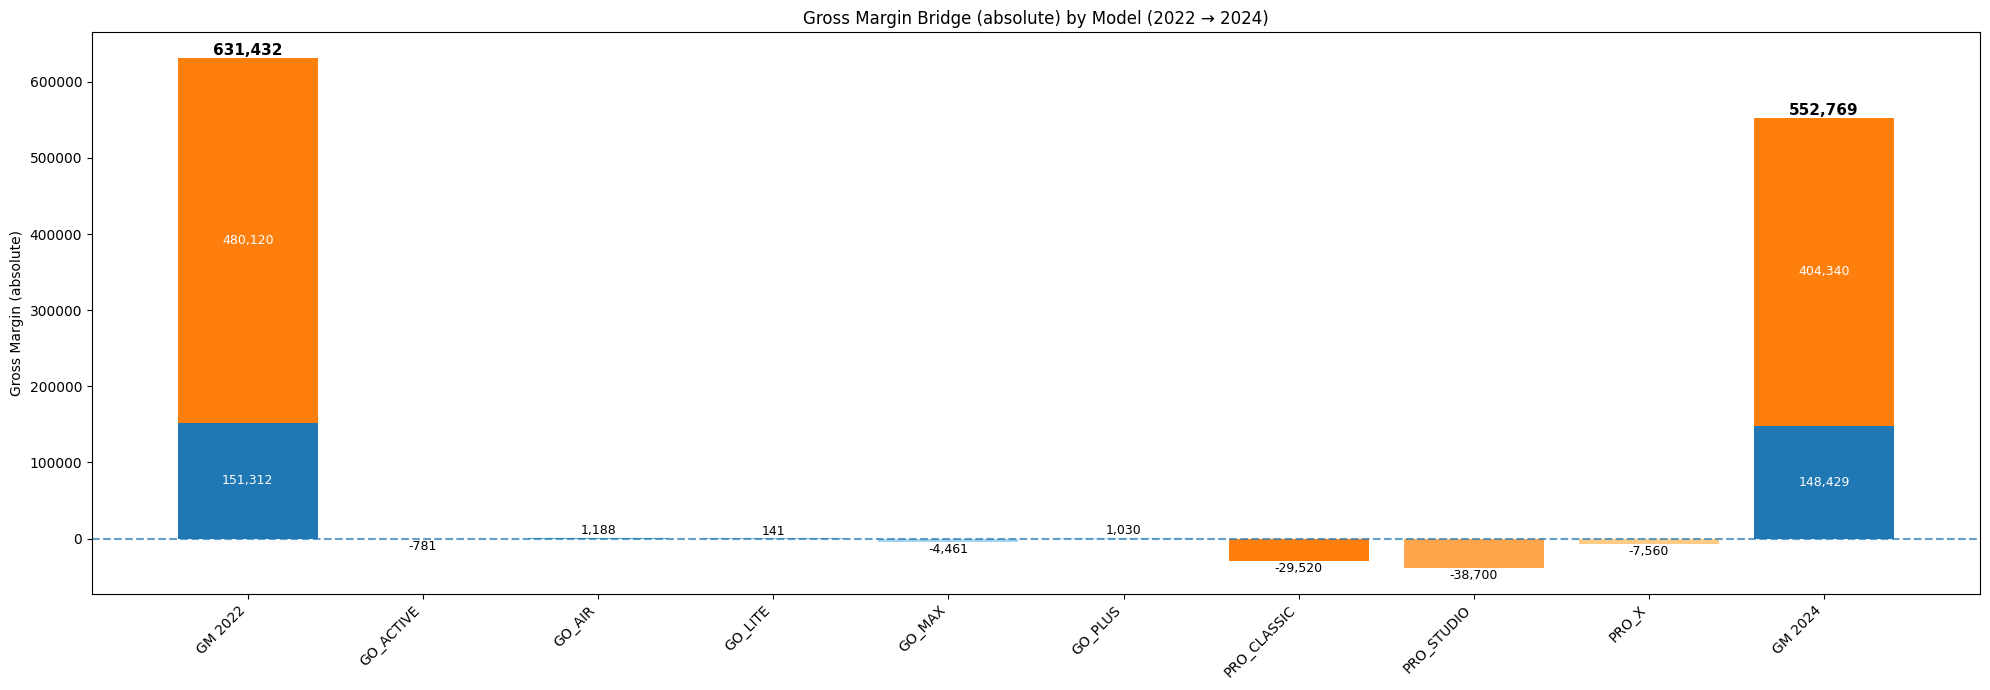

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_gm_model_bridge_absolute(df, year_0, year_1):

    models = [
        "GO_ACTIVE", "GO_AIR", "GO_LITE", "GO_MAX", "GO_PLUS",
        "PRO_CLASSIC", "PRO_STUDIO", "PRO_X"
    ]

    model_to_range = {
        "GO_ACTIVE": "GO", "GO_AIR": "GO", "GO_LITE": "GO",
        "GO_MAX": "GO", "GO_PLUS": "GO",
        "PRO_CLASSIC": "PRO", "PRO_STUDIO": "PRO", "PRO_X": "PRO"
    }

    colors = {
        "GO_ACTIVE": "#1f77b4", "GO_AIR": "#4fa3d1",
        "GO_LITE": "#81bee4", "GO_MAX": "#a6d4ef",
        "GO_PLUS": "#cce6f7",
        "PRO_CLASSIC": "#ff7f0e", "PRO_STUDIO": "#ffa64d",
        "PRO_X": "#ffcb85"
    }

    # GM per model per year
    gm_0 = {m: df[(df["product_id"] == m) &
                  (df["transaction_year"] == year_0)]["gross_margin_abs"].sum()
            for m in models}

    gm_1 = {m: df[(df["product_id"] == m) &
                  (df["transaction_year"] == year_1)]["gross_margin_abs"].sum()
            for m in models}

    # Delta
    delta = {m: gm_1[m] - gm_0[m] for m in models}

    # Start + final totals by range
    GM0_GO  = sum(v for m, v in gm_0.items() if model_to_range[m] == "GO")
    GM0_PRO = sum(v for m, v in gm_0.items() if model_to_range[m] == "PRO")
    GM1_GO  = sum(v for m, v in gm_1.items() if model_to_range[m] == "GO")
    GM1_PRO = sum(v for m, v in gm_1.items() if model_to_range[m] == "PRO")

    GM0 = GM0_GO + GM0_PRO
    GM1 = GM1_GO + GM1_PRO

    labels = [f"GM {year_0}"] + models + [f"GM {year_1}"]
    x_positions = range(len(labels))

    plt.figure(figsize=(20, 7))

    # ============================
    # 1) START bar (absolute + stacked)
    # ============================
    x0 = 0
    plt.bar(x0, GM0_GO, bottom=0, color="#1f77b4")
    plt.bar(x0, GM0_PRO, bottom=GM0_GO, color="#ff7f0e")

    plt.text(x0, GM0_GO/2, f"{GM0_GO:,.0f}", ha="center", va="center", color="white", fontsize=9)
    plt.text(x0, GM0_GO + GM0_PRO/2, f"{GM0_PRO:,.0f}", ha="center", va="center", color="white", fontsize=9)

    plt.text(x0, GM0, f"{GM0:,.0f}", ha="center", va="bottom",
             fontsize=11, fontweight="bold")

    # ============================
    # 2) MODEL BARS (absolute deltas)
    # ============================

    max_delta = max(abs(v) for v in delta.values()) if delta else 1
    offset = 0.03 * max_delta

    for i, m in enumerate(models, start=1):
        d = delta[m]
        plt.bar(i, d, color=colors[m])

        plt.text(i,
                 d + (offset if d >= 0 else -offset),
                 f"{d:,.0f}",
                 ha="center",
                 va="bottom" if d >= 0 else "top",
                 fontsize=9)

    # ============================
    # 3) FINAL BAR (absolute + stacked)
    # ============================
    x_final = len(models) + 1
    plt.bar(x_final, GM1_GO, bottom=0, color="#1f77b4")
    plt.bar(x_final, GM1_PRO, bottom=GM1_GO, color="#ff7f0e")

    plt.text(x_final, GM1_GO/2, f"{GM1_GO:,.0f}", ha="center", va="center", color="white", fontsize=9)
    plt.text(x_final, GM1_GO + GM1_PRO/2, f"{GM1_PRO:,.0f}", ha="center", va="center", color="white", fontsize=9)

    plt.text(x_final, GM1, f"{GM1:,.0f}",
             ha="center", va="bottom", fontsize=11, fontweight="bold")

    # ============================
    # Axis + formatting
    # ============================

    plt.axhline(0, linestyle="--", alpha=0.7)

    plt.xticks(x_positions, labels, rotation=45, ha="right")
    plt.ylabel("Gross Margin (absolute)")
    plt.title(f"Gross Margin Bridge (absolute) by Model ({year_0} → {year_1})")

    plt.tight_layout()
    plt.show()

# RUN
plot_gm_model_bridge_absolute(df, 2022, 2024)

Build the same analysis by region_code

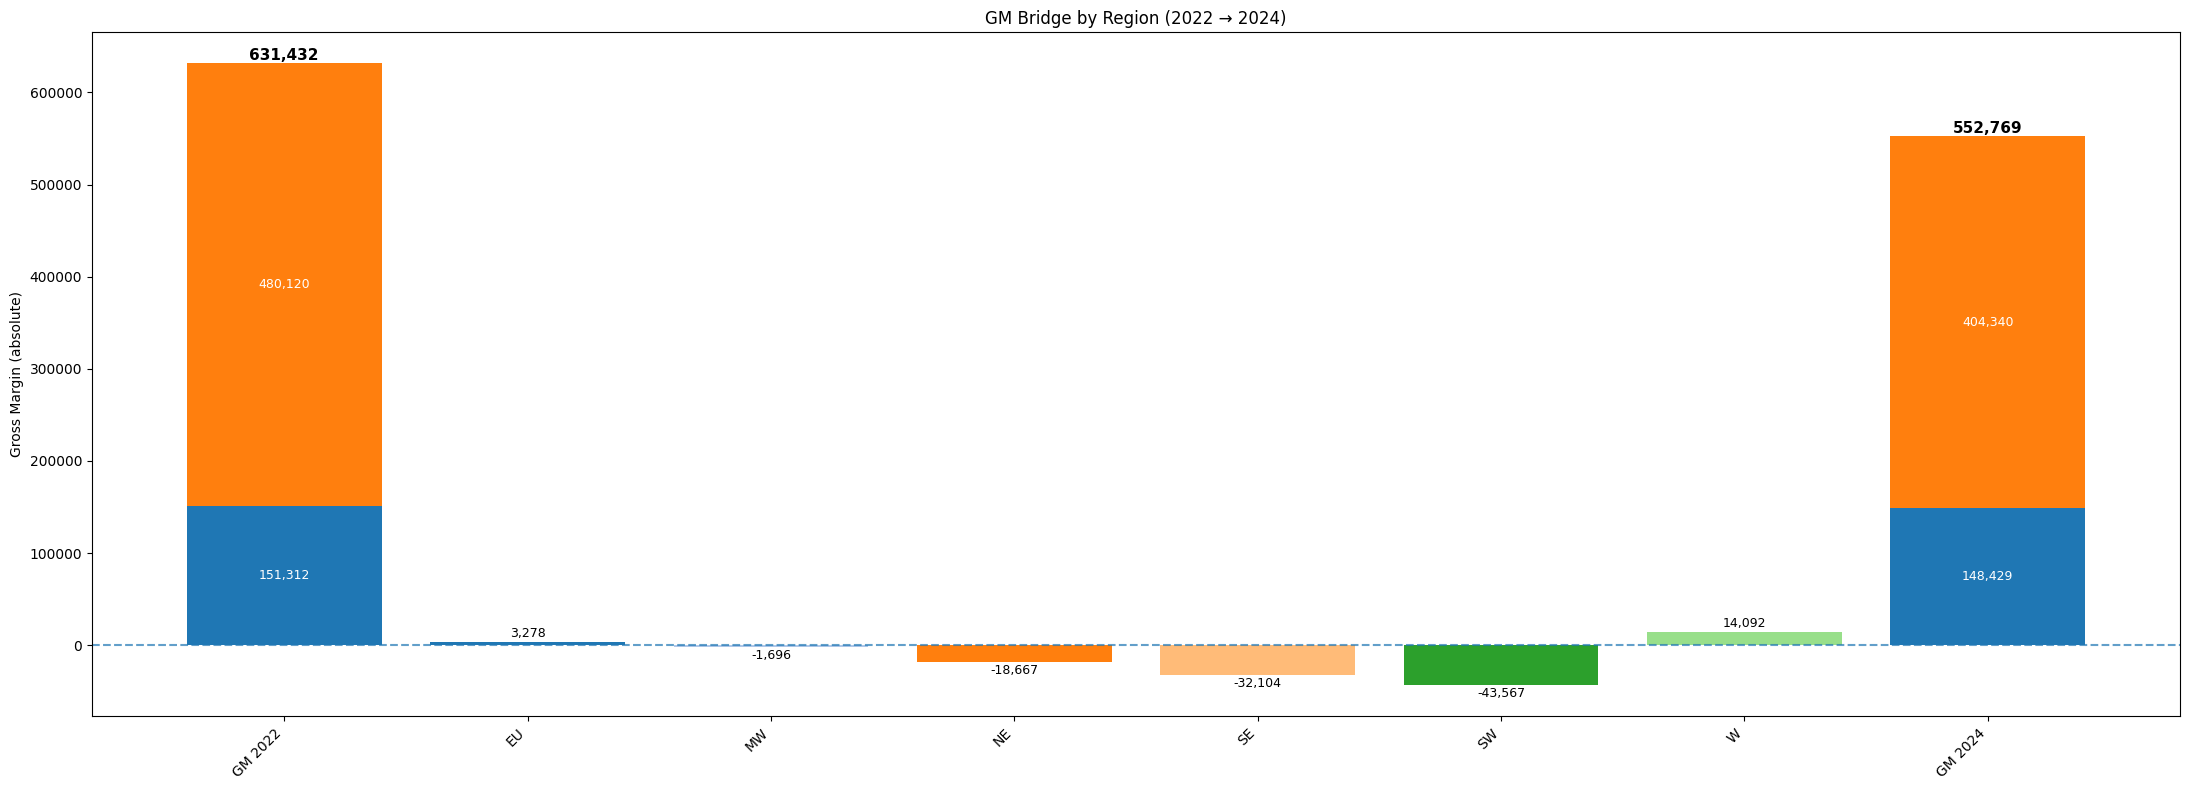

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_gm_region_bridge_absolute(df, year_0, year_1):

    # Отримуємо реальні регіони з даних
    regions = sorted(df["region_code"].dropna().unique())

    # Мапа кольорів для регіонів (автоматично)
    cmap = plt.get_cmap("tab20")
    colors = {r: cmap(i % 20) for i, r in enumerate(regions)}

    # GM per region per year
    gm_0 = {r: df[(df["region_code"] == r) &
                  (df["transaction_year"] == year_0)]["gross_margin_abs"].sum()
            for r in regions}

    gm_1 = {r: df[(df["region_code"] == r) &
                  (df["transaction_year"] == year_1)]["gross_margin_abs"].sum()
            for r in regions}

    # ΔGM by region
    delta = {r: gm_1[r] - gm_0[r] for r in regions}

    # START & FINAL totals by GO/PRO ranges
    GM0_GO  = df[(df["transaction_year"] == year_0) & (df["model_range"] == "Aura_GO")]["gross_margin_abs"].sum()
    GM0_PRO = df[(df["transaction_year"] == year_0) & (df["model_range"] == "Aura_PRO")]["gross_margin_abs"].sum()

    GM1_GO  = df[(df["transaction_year"] == year_1) & (df["model_range"] == "Aura_GO")]["gross_margin_abs"].sum()
    GM1_PRO = df[(df["transaction_year"] == year_1) & (df["model_range"] == "Aura_PRO")]["gross_margin_abs"].sum()

    GM0 = GM0_GO + GM0_PRO
    GM1 = GM1_GO + GM1_PRO

    labels = [f"GM {year_0}"] + list(regions) + [f"GM {year_1}"]
    x_positions = range(len(labels))

    plt.figure(figsize=(22, 8))

    # ============================
    # START BAR
    # ============================
    x0 = 0
    plt.bar(x0, GM0_GO, bottom=0, color="#1f77b4")
    plt.bar(x0, GM0_PRO, bottom=GM0_GO, color="#ff7f0e")

    plt.text(x0, GM0_GO / 2, f"{GM0_GO:,.0f}", ha="center", va="center", color="white", fontsize=9)
    plt.text(x0, GM0_GO + GM0_PRO / 2, f"{GM0_PRO:,.0f}", ha="center", va="center", color="white", fontsize=9)
    plt.text(x0, GM0, f"{GM0:,.0f}", ha="center", va="bottom", fontsize=11, fontweight="bold")

    # ============================
    # REGION Δ BARS
    # ============================
    max_delta = max(abs(v) for v in delta.values()) if delta else 1
    offset = 0.05 * max_delta

    for i, r in enumerate(regions, start=1):
        d = delta[r]
        plt.bar(i, d, color=colors[r])

        plt.text(
            i,
            d + (offset if d >= 0 else -offset),
            f"{d:,.0f}",
            ha="center",
            va=("bottom" if d >= 0 else "top"),
            fontsize=9
        )

    # ============================
    # FINAL BAR
    # ============================
    xF = len(regions) + 1
    plt.bar(xF, GM1_GO, bottom=0, color="#1f77b4")
    plt.bar(xF, GM1_PRO, bottom=GM1_GO, color="#ff7f0e")

    plt.text(xF, GM1_GO / 2, f"{GM1_GO:,.0f}", ha="center", va="center", color="white", fontsize=9)
    plt.text(xF, GM1_GO + GM1_PRO / 2, f"{GM1_PRO:,.0f}", ha="center", va="center", color="white", fontsize=9)
    plt.text(xF, GM1, f"{GM1:,.0f}", ha="center", va="bottom", fontsize=11, fontweight="bold")

    # ============================
    # Formatting
    # ============================
    plt.axhline(0, linestyle="--", alpha=0.7)
    plt.xticks(x_positions, labels, rotation=45, ha="right")
    plt.ylabel("Gross Margin (absolute)")
    plt.title(f"GM Bridge by Region ({year_0} → {year_1})")
    plt.tight_layout()
    plt.show()

# RUN
plot_gm_region_bridge_absolute(df, 2022, 2024)

#RFM SEGMENTATION | Create new variables which describe unique customer_id 1) Recency - number of days between 2024-12-30 and the last purchase for each unique customer_id 2) Frequency - count of purchases per each unique customer_id 3) Monetary Value - where retail_price multiplied by count of purchases for each unique customer_id. Create 3 separate variables. Use transaction_id to calculate frequency and purchase.

AI responce "You got it. I will use transaction_id for frequency (counting unique transactions) and retail_price for monetary value (summing total retail price per customer). I will create a plan to calculate Recency, Frequency, and Monetary Value as three separate variables for each unique customer, ensuring transaction_id is used for frequency.

calculate_recency: Calculate Recency for each unique customer: number of days between 2024-12-30 and the last purchase date (transaction_date).
calculate_frequency: Calculate Frequency for each unique customer: count of unique transaction_ids.
calculate_monetary_value: Calculate Monetary Value for each unique customer: sum of retail_price."

In [13]:
df['transaction_date'] = pd.to_datetime(df['transaction_date'])

reference_date = pd.to_datetime('2024-12-30')

last_purchase_date = df.groupby('customer_id')['transaction_date'].max()

recency = (reference_date - last_purchase_date).dt.days

print("Recency (days since last purchase):")
display(recency.head())

Recency (days since last purchase):


,transaction_date
customer_id,
C00001,58
C00002,222
C00003,411
C00004,439
C00006,164


In [14]:
frequency = df.groupby('customer_id')['transaction_id'].nunique()

print("Frequency (count of unique purchases):")
display(frequency.head())

Frequency (count of unique purchases):


,transaction_id
customer_id,
C00001,3
C00002,6
C00003,1
C00004,3
C00006,4


In [15]:
monetary_value = df.groupby('customer_id')['retail_price'].sum()

print("Monetary Value (sum of retail price per customer):")
display(monetary_value.head())

Monetary Value (sum of retail price per customer):


,retail_price
customer_id,
C00001,620
C00002,4260
C00003,880
C00004,720
C00006,5900


**Reasoning**:
Now that Recency, Frequency, and Monetary Value have all been calculated, I will combine these three Series into a single DataFrame to create the RFM metrics table for each customer and display the first few rows.



In [16]:
rfm_df = pd.DataFrame({
    'Recency': recency,
    'Frequency': frequency,
    'MonetaryValue': monetary_value
})

print("RFM DataFrame:")
display(rfm_df.head())

RFM DataFrame:


,Recency,Frequency,MonetaryValue
customer_id,,,
C00001,58,3,620
C00002,222,6,4260
C00003,411,1,880
C00004,439,3,720
C00006,164,4,5900


Topline analysis of new variebles. Basic descrition.

In [ ]:
rfm_df[["Recency", "Frequency", "MonetaryValue"]].describe()

,Recency,Frequency,MonetaryValue
count,1436.000000,1436.000000,1436.000000
mean,294.160167,3.867688,2565.389972
std,267.784901,2.513082,2177.092566
min,0.000000,1.000000,180.000000
25%,76.000000,2.000000,1040.000000
50%,212.000000,3.000000,1860.000000
75%,443.250000,5.000000,3320.000000
max,1085.000000,14.000000,17920.000000


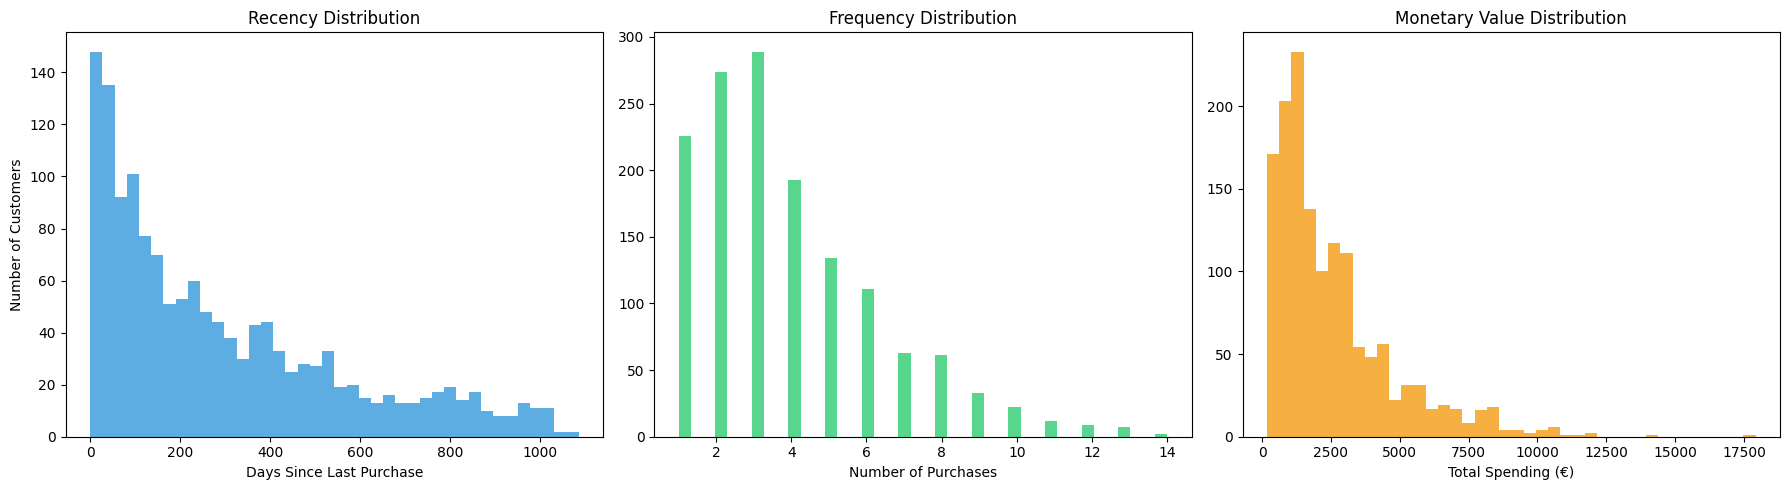

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Recency ---
axes[0].hist(rfm_df["Recency"], bins=40, color="#5DADE2")
axes[0].set_title("Recency Distribution")
axes[0].set_xlabel("Days Since Last Purchase")
axes[0].set_ylabel("Number of Customers")

# --- Frequency ---
axes[1].hist(rfm_df["Frequency"], bins=40, color="#58D68D")
axes[1].set_title("Frequency Distribution")
axes[1].set_xlabel("Number of Purchases")

# --- Monetary ---
axes[2].hist(rfm_df["MonetaryValue"], bins=40, color="#F5B041")
axes[2].set_title("Monetary Value Distribution")
axes[2].set_xlabel("Total Spending (€)")

plt.tight_layout()
plt.show()

Looking and precentille to get an idea on threshholds | Prompt: rfm_df[["Recency","Frequency","MonetaryValue"]].quantile(
    [0.01,0.05,0.10,0.25,0.50,0.75,0.90,0.95,0.99] |

In [ ]:
rfm_df[["Recency","Frequency","MonetaryValue"]].quantile(
    [0.01,0.05,0.10,0.25,0.50,0.75,0.90,0.95,0.99]
)

,Recency,Frequency,MonetaryValue
0.01,2.00,1.0,180.0
0.05,11.75,1.0,320.0
0.10,27.00,1.0,560.0
0.25,76.00,2.0,1040.0
0.50,212.00,3.0,1860.0
0.75,443.25,5.0,3320.0
0.90,738.00,8.0,5670.0
0.95,852.25,9.0,7080.0
0.99,1003.65,12.0,10096.0


Summary_Lena: Recency - very high deviation indicates many passive/rejector consumers, a typical customer bought ~7 months ago, 75% have not purchased over a years -> there is high potential for re-activation campaign.     |     Frequency -  overall a healthy pattern: a typical customer purchases 3 times over 2022-2024, and 75% of customers have purchased up to 5 times. There is also a small group of super-loyal customers with up to 14 purchases — we should identify their profile and understand what drives their behaviour.     |   MonetaryValue - the typical spending level is €1,860, which is lower than the standard deviation, indicating the presence of customers who spend significantly more. Again, we need to identify these high-value customers and understand what drives their behaviour.  

#---var_R_Segment | Create Additional Variable in rfm_df and add separate column "R_Segment" with 4 groups where: 1) Recency from 0 to 90 days means "Active", 2) Recency from 91 to 365 days means "Warm", 3) Recency from 366 to 730 days means "At Risk", 4) Recency with 731 days and more means "Lost"     

In [17]:
import numpy as np

# Existing code for R_Segment
bins_r = [0, 90, 365, 730, np.inf]
labels_r = ['Active', 'Warm', 'At Risk', 'Lost']

rfm_df['R_Segment'] = pd.cut(
    rfm_df['Recency'],
    bins=bins_r,
    labels=labels_r,
    right=True,
    include_lowest=True
)

# Existing code for F_Segment
conditions_f = [
    rfm_df['Frequency'] == 1,
    (rfm_df['Frequency'] >= 2) & (rfm_df['Frequency'] <= 3),
    (rfm_df['Frequency'] >= 4) & (rfm_df['Frequency'] <= 7),
    rfm_df['Frequency'] >= 8
]
labels_f = ['One-timers', 'Occasional', 'Loyal', 'Super-Loyal']

rfm_df['F_Segment'] = np.select(conditions_f, labels_f, default='Other')

# Existing code for M_Segment
bins_m = [0, 1040, 3320, 7080, np.inf]
labels_m = ['Low Value', 'Mid Value', 'High Value', 'VIP']

rfm_df['M_Segment'] = pd.cut(
    rfm_df['MonetaryValue'],
    bins=bins_m,
    labels=labels_m,
    right=True,
    include_lowest=True
)

print("RFM DataFrame with R_Segment, F_Segment, and M_Segment:")
display(rfm_df.head())

RFM DataFrame with R_Segment, F_Segment, and M_Segment:


,Recency,Frequency,MonetaryValue,R_Segment,F_Segment,M_Segment
customer_id,,,,,,
C00001,58,3,620,Active,Occasional,Low Value
C00002,222,6,4260,Warm,Loyal,High Value
C00003,411,1,880,At Risk,One-timers,Low Value
C00004,439,3,720,At Risk,Occasional,Low Value
C00006,164,4,5900,Warm,Loyal,High Value


#---var_F_Segment | Create Additional Variable in rfm_df and add separate column "F_Segment" with 4 groups where: 1) Frequency equal 1 means "One-timers", 2) Frequency from 2 to 3 means "Occasional", 3) Frequency from 4 to 7 means "Loyal", 4) Frequency 8 and more means "Super-Loyal"     

In [ ]:
import numpy as np

conditions = [
    rfm_df['Frequency'] == 1,
    (rfm_df['Frequency'] >= 2) & (rfm_df['Frequency'] <= 3),
    (rfm_df['Frequency'] >= 4) & (rfm_df['Frequency'] <= 7),
    rfm_df['Frequency'] >= 8
]

labels = ['One-timers', 'Occasional', 'Loyal', 'Super-Loyal']

rfm_df['F_Segment'] = np.select(conditions, labels, default='Other') # 'Other' for any unhandled cases, though all are covered

print("RFM DataFrame with F_Segment:")
display(rfm_df.head())

RFM DataFrame with F_Segment:


,customer_id,Recency,Frequency,MonetaryValue,Cluster,F_Segment,M_Segment
0,C00001,59,3,620,0,Occasional,Low Value
1,C00002,223,9,4260,1,Super-Loyal,High Value
2,C00003,412,3,880,0,Occasional,Low Value
3,C00004,440,3,720,2,Occasional,Low Value
4,C00006,165,4,5900,0,Loyal,High Value


#---var_M_Segment | Create Additional Variable in rfm_df and add separate column "M_Segment" with 4 groups where: 1) MonetaryValue is 1040 and less means "Low Value", 2) MonetaryValue from 1041 to 3320 means "Mid Value", 3) Mid Value from 3321 to 7080 means "High Value", 4) MonetaryValue with 7080 and more means "VIP"     

In [ ]:
import numpy as np

# Define the bins and labels for M_Segment
bins_m = [0, 1040, 3320, 7080, np.inf]
labels_m = ['Low Value', 'Mid Value', 'High Value', 'VIP']

# Create the M_Segment column using pd.cut
rfm_df['M_Segment'] = pd.cut(
    rfm_df['MonetaryValue'],
    bins=bins_m,
    labels=labels_m,
    right=True, # include the rightmost bin edge
    include_lowest=True # include the lowest value in the first bin
)

print("RFM DataFrame with M_Segment:")
display(rfm_df.head())

RFM DataFrame with M_Segment:


,customer_id,Recency,Frequency,MonetaryValue,Cluster,F_Segment,M_Segment
0,C00001,59,3,620,0,Occasional,Low Value
1,C00002,223,9,4260,1,Super-Loyal,High Value
2,C00003,412,3,880,0,Occasional,Low Value
3,C00004,440,3,720,2,Occasional,Low Value
4,C00006,165,4,5900,0,Loyal,High Value


Build correlation matrix.

Logically strong correlation between money&frequency as well as recency&frequency. In interesting moment that money&recency has week correlation means high value customers could be recently active as well as bought long ago ...

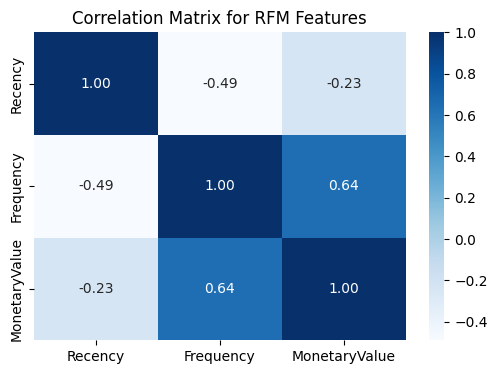

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.heatmap(
    rfm_df[["Recency","Frequency","MonetaryValue"]].corr(),
    annot=True, cmap="Blues", fmt=".2f"
)
plt.title("Correlation Matrix for RFM Features")
plt.show()

 Build scatterplots

 No super insights - higher frequency - more money, more recent customer - more spent

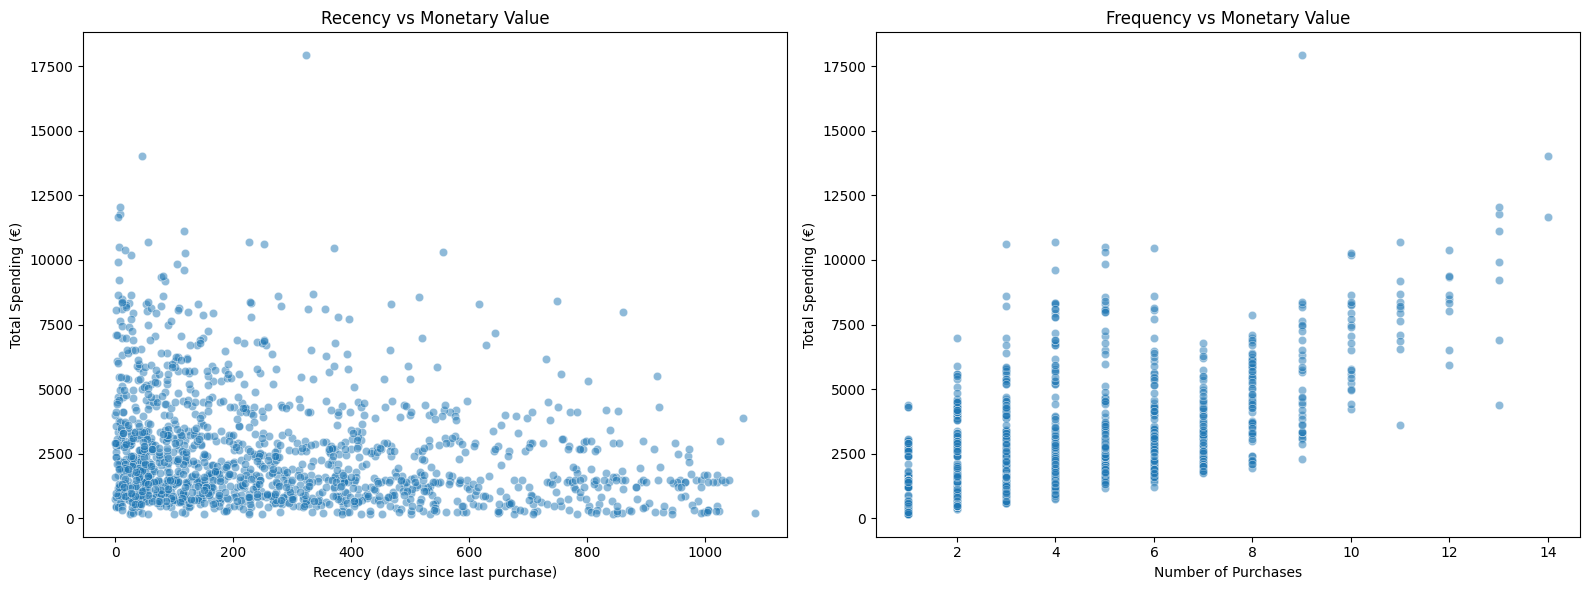

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(16,6))

# --- 1) Recency vs MonetaryValue ---
plt.subplot(1,2,1)
sns.scatterplot(data=rfm_df, x="Recency", y="MonetaryValue", alpha=0.5)
plt.title("Recency vs Monetary Value")
plt.xlabel("Recency (days since last purchase)")
plt.ylabel("Total Spending (€)")

# --- 2) Frequency vs MonetaryValue ---
plt.subplot(1,2,2)
sns.scatterplot(data=rfm_df, x="Frequency", y="MonetaryValue", alpha=0.5)
plt.title("Frequency vs Monetary Value")
plt.xlabel("Number of Purchases")
plt.ylabel("Total Spending (€)")

plt.tight_layout()
plt.show()


Show an average for each of segments.

Looks as healty customer base structure - there loyal customers, who bought recently and spent a lot. Why the Gross Margin Varience Analysis demonstrate decline driven by number of customers and frequency... ?

In [18]:
print("\nAverage RFM values by R_Segment:")
display(rfm_df.groupby('R_Segment')[['Recency', 'Frequency', 'MonetaryValue']].mean())

print("\nAverage RFM values by F_Segment:")
display(rfm_df.groupby('F_Segment')[['Recency', 'Frequency', 'MonetaryValue']].mean())

print("\nAverage RFM values by M_Segment:")
display(rfm_df.groupby('M_Segment')[['Recency', 'Frequency', 'MonetaryValue']].mean())


Average RFM values by R_Segment:


/tmp/ipython-input-1254309236.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  display(rfm_df.groupby('R_Segment')[['Recency', 'Frequency', 'MonetaryValue']].mean())


,Recency,Frequency,MonetaryValue
R_Segment,,,
Active,41.456731,5.324519,3172.307692
Warm,203.970642,4.051376,2621.944954
At Risk,504.447853,2.720859,2103.926380
Lost,869.489933,1.637584,1673.691275



Average RFM values by F_Segment:


,Recency,Frequency,MonetaryValue
F_Segment,,,
Loyal,187.968064,5.087824,2984.391218
Occasional,330.634103,2.513321,1870.479574
One-timers,573.765487,1.000000,1140.265487
Super-Loyal,85.095890,9.342466,6013.287671



Average RFM values by M_Segment:


/tmp/ipython-input-1254309236.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  display(rfm_df.groupby('M_Segment')[['Recency', 'Frequency', 'MonetaryValue']].mean())


,Recency,Frequency,MonetaryValue
M_Segment,,,
Low Value,358.413043,2.203804,632.663043
Mid Value,303.267229,3.579466,2016.680731
High Value,221.968531,5.646853,4834.895105
VIP,160.732394,8.211268,8935.774648


Show total retail_price for each of segments, add totals for rows and columns, show % without decimals with "%" sign

In [ ]:
print("\nTotal Retail Price by R_Segment:")
r_segment_total_retail = rfm_df.groupby('R_Segment')['MonetaryValue'].sum().reset_index()
grand_total_r = r_segment_total_retail['MonetaryValue'].sum()
r_segment_total_retail['% out of Total'] = (r_segment_total_retail['MonetaryValue'] / grand_total_r) * 100
r_segment_total_retail.loc['Total'] = ["Total", grand_total_r, r_segment_total_retail['% out of Total'].sum()]
r_segment_total_retail['% out of Total'] = r_segment_total_retail['% out of Total'].apply(lambda x: f"{x:.0f}%")
display(r_segment_total_retail)

print("\nTotal Retail Price by F_Segment:")
f_segment_total_retail = rfm_df.groupby('F_Segment')['MonetaryValue'].sum().reset_index()
grand_total_f = f_segment_total_retail['MonetaryValue'].sum()
f_segment_total_retail['% out of Total'] = (f_segment_total_retail['MonetaryValue'] / grand_total_f) * 100
f_segment_total_retail.loc['Total'] = ["Total", grand_total_f, f_segment_total_retail['% out of Total'].sum()]
f_segment_total_retail['% out of Total'] = f_segment_total_retail['% out of Total'].apply(lambda x: f"{x:.0f}%")
display(f_segment_total_retail)

print("\nTotal Retail Price by M_Segment:")
m_segment_total_retail = rfm_df.groupby('M_Segment')['MonetaryValue'].sum().reset_index()
grand_total_m = m_segment_total_retail['MonetaryValue'].sum()
m_segment_total_retail['% out of Total'] = (m_segment_total_retail['MonetaryValue'] / grand_total_m) * 100
m_segment_total_retail.loc['Total'] = ["Total", grand_total_m, m_segment_total_retail['% out of Total'].sum()]
m_segment_total_retail['% out of Total'] = m_segment_total_retail['% out of Total'].apply(lambda x: f"{x:.0f}%")
display(m_segment_total_retail)


Total Retail Price by R_Segment:


/tmp/ipython-input-2932453870.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  r_segment_total_retail = rfm_df.groupby('R_Segment')['MonetaryValue'].sum().reset_index()


,R_Segment,MonetaryValue,% out of Total
0,Active,1319680,36%
1,Warm,1428960,39%
2,At Risk,685880,19%
3,Lost,249380,7%
Total,Total,3683900,100%



Total Retail Price by F_Segment:


,F_Segment,MonetaryValue,% out of Total
0,Loyal,1495180,41%
1,Occasional,1053080,29%
2,One-timers,257700,7%
3,Super-Loyal,877940,24%
Total,Total,3683900,100%



Total Retail Price by M_Segment:


/tmp/ipython-input-2932453870.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  m_segment_total_retail = rfm_df.groupby('M_Segment')['MonetaryValue'].sum().reset_index()


,M_Segment,MonetaryValue,% out of Total
0,Low Value,232820,6%
1,Mid Value,1433860,39%
2,High Value,1382780,38%
3,VIP,634440,17%
Total,Total,3683900,100%


Create Inverted "Recency" variable

In [24]:
# Create Recency_Inverted column
max_rec = rfm_df["Recency"].max()

rfm_df["Recency_Inverted"] = max_rec - rfm_df["Recency"]

rfm_df[["Recency", "Recency_Inverted"]].head()

,Recency,Recency_Inverted
customer_id,,
C00001,58,1027
C00002,222,863
C00003,411,674
C00004,439,646
C00006,164,921


Normalization RFM variables

In [25]:
from sklearn.preprocessing import MinMaxScaler

# Create a scaler
scaler = MinMaxScaler()

# Columns we normalize
cols_to_scale = ["Recency_Inverted", "Frequency", "MonetaryValue"]

# Fit-transform
rfm_df[["R_norm", "F_norm", "M_norm"]] = scaler.fit_transform(rfm_df[cols_to_scale])

# Check result
rfm_df[["Recency_Inverted", "R_norm",
        "Frequency", "F_norm",
        "MonetaryValue", "M_norm"]].head()

,Recency_Inverted,R_norm,Frequency,F_norm,MonetaryValue,M_norm
customer_id,,,,,,
C00001,1027,0.946544,3,0.153846,620,0.024803
C00002,863,0.795392,6,0.384615,4260,0.229989
C00003,674,0.621198,1,0.000000,880,0.039459
C00004,646,0.595392,3,0.153846,720,0.030440
C00006,921,0.848848,4,0.230769,5900,0.322435


Create normalized matrix, describe

In [26]:
rfm_norm = rfm_df[["R_norm", "F_norm", "M_norm"]].copy()

In [27]:
rfm_norm.describe()

,R_norm,F_norm,M_norm
count,1436.000000,1436.000000,1436.000000
mean,0.728885,0.220591,0.134464
std,0.246806,0.193314,0.122722
min,0.000000,0.000000,0.000000
25%,0.591475,0.076923,0.048478
50%,0.804608,0.153846,0.094701
75%,0.929954,0.307692,0.177001
max,1.000000,1.000000,1.000000


#CLUSTER ANALYSIS

Create dataset for clusterization

In [28]:
rfm_for_kmeans = rfm_norm[['R_norm', 'F_norm', 'M_norm']]

In [29]:
rfm_for_kmeans.head()

,R_norm,F_norm,M_norm
customer_id,,,
C00001,0.946544,0.153846,0.024803
C00002,0.795392,0.384615,0.229989
C00003,0.621198,0.000000,0.039459
C00004,0.595392,0.153846,0.030440
C00006,0.848848,0.230769,0.322435


#---Number of Clusters

Run kmeans test for rfm_for_kmeans

Looks as 3-4 clusters by Elbow Method

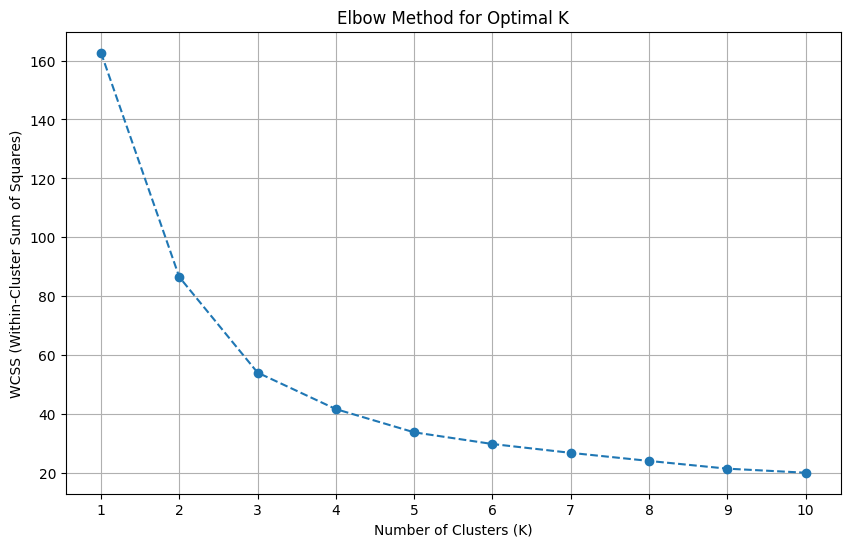

Look for the 'elbow' point in the plot to determine the optimal number of clusters.


In [30]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []
# Test K from 1 to 10
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10) # n_init to suppress warning
    kmeans.fit(rfm_for_kmeans)
    wcss.append(kmeans.inertia_)

# Plot the elbow method
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS (Within-Cluster Sum of Squares)')
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()

print("Look for the 'elbow' point in the plot to determine the optimal number of clusters.")

Run kmeans test by Silhouette method

Looks 2-3 clusters (0.37 acceptable score for 3 clusters)

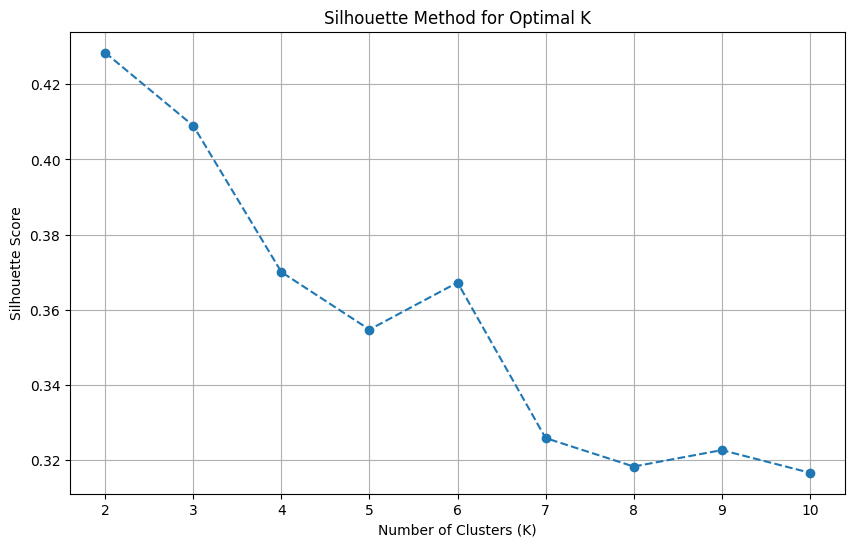

Look for the highest point in the plot to determine the optimal number of clusters.


In [31]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

silhouette_scores = []
# Test K from 2 to 10 (Silhouette score is not defined for K=1)
for i in range(2, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(rfm_for_kmeans)
    score = silhouette_score(rfm_for_kmeans, kmeans.labels_)
    silhouette_scores.append(score)

# Plot the silhouette scores
plt.figure(figsize=(10, 6))
plt.plot(range(2, 11), silhouette_scores, marker='o', linestyle='--')
plt.title('Silhouette Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.xticks(range(2, 11))
plt.grid(True)
plt.show()

print("Look for the highest point in the plot to determine the optimal number of clusters.")

Create 3 clusters

In [33]:
from sklearn.cluster import KMeans

k = 3
kmeans = KMeans(n_clusters=k, random_state=42)
clusters = kmeans.fit_predict(rfm_for_kmeans)

rfm_df["Cluster"] = clusters
rfm_norm["Cluster"] = clusters

In [34]:
rfm_df["Cluster"].value_counts()

,count
Cluster,
0,744
2,354
1,338


In [35]:
cluster_profile = rfm_df.groupby("Cluster")[["Recency", "Frequency", "MonetaryValue"]].mean()
cluster_profile

,Recency,Frequency,MonetaryValue
Cluster,,,
0,185.267473,3.120968,1851.612903
1,117.428994,7.500000,4974.201183
2,691.762712,1.968927,1765.593220


In [36]:
rfm_norm.groupby("Cluster")[["R_norm", "F_norm", "M_norm"]].mean()

,R_norm,F_norm,M_norm
Cluster,,,
0,0.829247,0.163151,0.094228
1,0.891771,0.500000,0.270248
2,0.362431,0.074533,0.089380


#---Visualuzation of Clusters

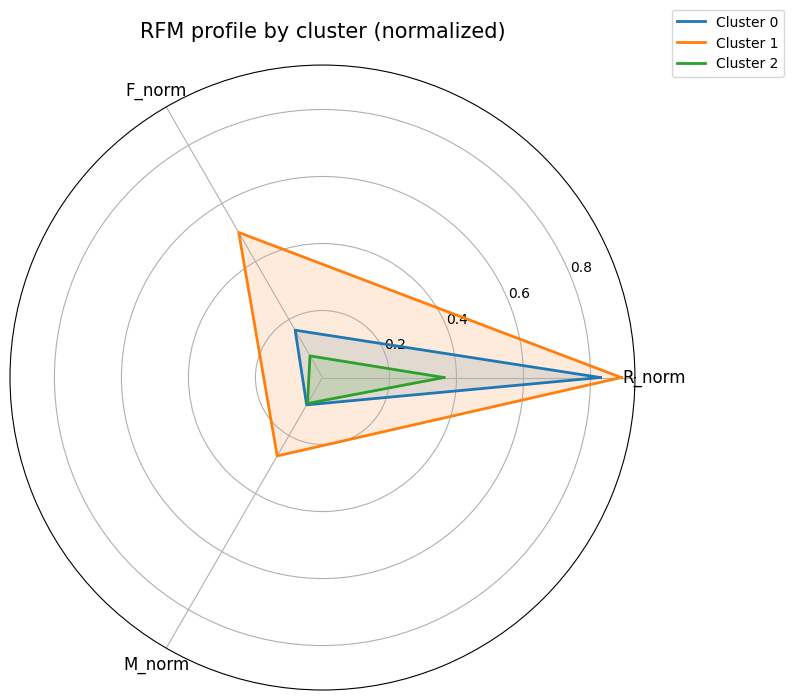

In [54]:
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Compute mean profiles per cluster ---
# The 'Cluster' column is in rfm_norm, not rfm_for_kmeans
cluster_profiles = rfm_norm.groupby('Cluster')[['R_norm', 'F_norm', 'M_norm']].mean()

# --- 2. Prepare data for radar plot ---
features = ['R_norm', 'F_norm', 'M_norm']
num_vars = len(features)

angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]   # close circle

plt.figure(figsize=(8, 8))
ax = plt.subplot(111, polar=True)

colors = ['#1f77b4', '#ff7f0e', '#2ca02c']   # blue, orange, green

# --- 3. Plot each cluster ---
for idx, (cluster, row) in enumerate(cluster_profiles.iterrows()):
    values = row.tolist()
    values += values[:1]    # close circle

    ax.plot(angles, values, linewidth=2, label=f"Cluster {cluster}", color=colors[idx])
    ax.fill(angles, values, alpha=0.15, color=colors[idx])

# --- 4. Formatting ---
ax.set_xticks(angles[:-1])
ax.set_xticklabels(features, fontsize=12)

ax.set_yticks([0.2, 0.4, 0.6, 0.8])
ax.set_yticklabels(["0.2", "0.4", "0.6", "0.8"], fontsize=10)

plt.title("RFM profile by cluster (normalized)", size=15, pad=20)
plt.legend(loc="upper right", bbox_to_anchor=(1.25, 1.1))
plt.tight_layout()
plt.show()

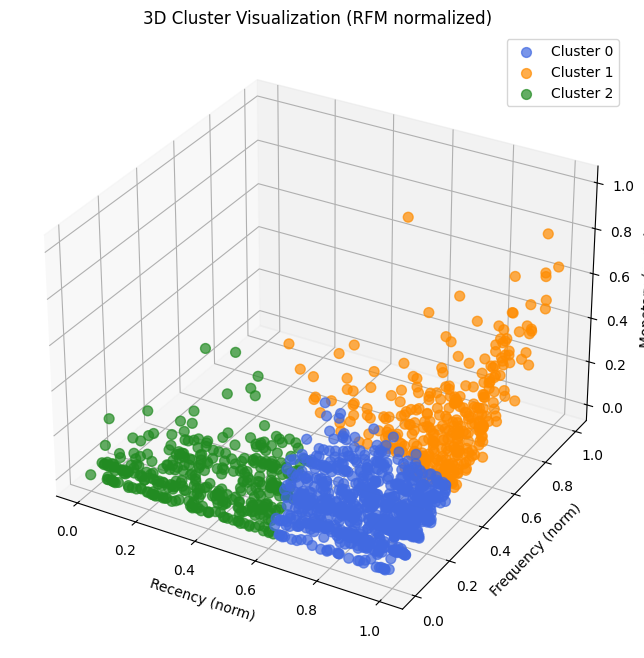

In [55]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

colors = {0:"royalblue", 1:"darkorange", 2:"forestgreen"}

# Use rfm_norm instead of rfm_for_kmeans, as rfm_norm contains the 'Cluster' column
for c in rfm_norm["Cluster"].unique():
    cluster_df = rfm_norm[rfm_norm["Cluster"] == c]
    ax.scatter(
        cluster_df["R_norm"],
        cluster_df["F_norm"],
        cluster_df["M_norm"],
        s=50,
        color=colors[c],
        label=f"Cluster {c}",
        alpha=0.7
    )

ax.set_xlabel("Recency (norm)")
ax.set_ylabel("Frequency (norm)")
ax.set_zlabel("Monetary (norm)")
ax.set_title("3D Cluster Visualization (RFM normalized)")
ax.legend()
plt.show()

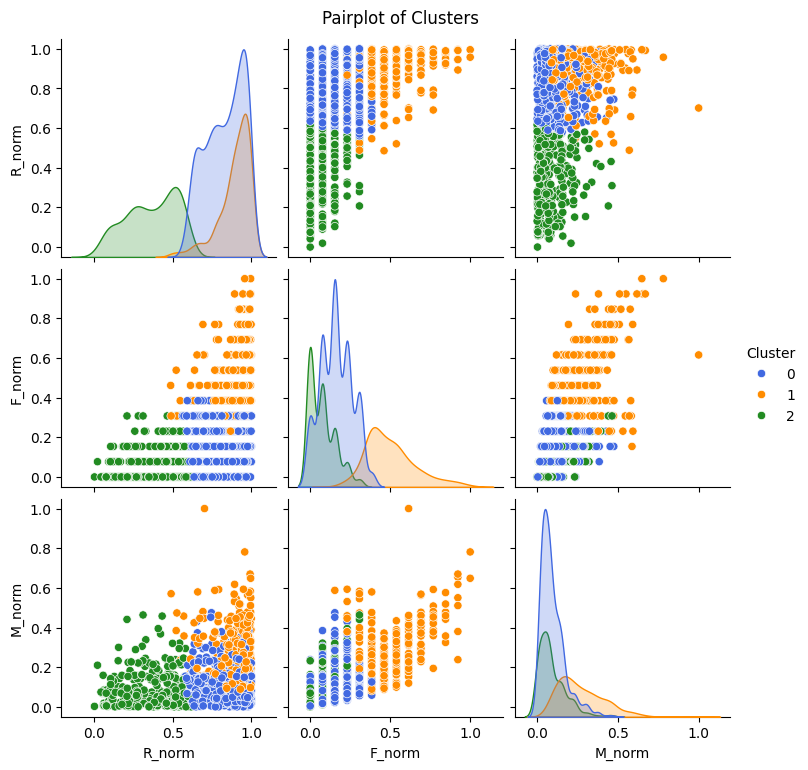

In [ ]:
import seaborn as sns

sns.pairplot(
    rfm_for_kmeans[["R_norm", "F_norm", "M_norm", "Cluster"]],
    hue="Cluster",
    palette=["royalblue", "darkorange", "forestgreen"],
    diag_kind="kde"
)
plt.suptitle("Pairplot of Clusters", y=1.02)
plt.show()

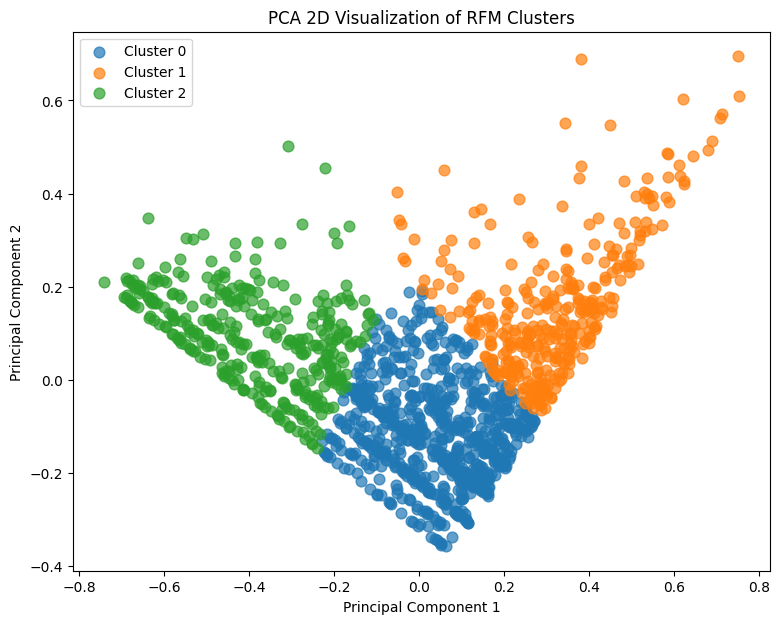

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
components = pca.fit_transform(rfm_for_kmeans[["R_norm", "F_norm", "M_norm"]])

rfm_for_kmeans["PC1"] = components[:, 0]
rfm_for_kmeans["PC2"] = components[:, 1]

plt.figure(figsize=(9,7))
for c in rfm_for_kmeans["Cluster"].unique():
    plt.scatter(
        rfm_for_kmeans[rfm_for_kmeans["Cluster"] == c]["PC1"],
        rfm_for_kmeans[rfm_for_kmeans["Cluster"] == c]["PC2"],
        s=60,
        alpha=0.7,
        label=f"Cluster {c}"
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA 2D Visualization of RFM Clusters")
plt.legend()
plt.show()

Checking the quality of clustering for 3 - ok

In [ ]:
from sklearn.cluster import KMeans

inertias = []

for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(rfm_for_kmeans)
    inertias.append(km.inertia_)

for k, inertia in zip(range(1, 11), inertias):
    print(f"K = {k}:   WCSS = {inertia:.2f}")

K = 1:   WCSS = 1307.51
K = 2:   WCSS = 399.72
K = 3:   WCSS = 98.39
K = 4:   WCSS = 83.89
K = 5:   WCSS = 67.42
K = 6:   WCSS = 62.14
K = 7:   WCSS = 47.86
K = 8:   WCSS = 42.88
K = 9:   WCSS = 41.48
K = 10:   WCSS = 36.71


In [ ]:
from sklearn.preprocessing import StandardScaler

# rfm_norm — твій датафрейм з колонками R_norm, F_norm, M_norm
rfm_for_kmeans = rfm_norm[["R_norm", "F_norm", "M_norm"]]

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_for_kmeans)

In [ ]:
import plotly.graph_objects as go
import numpy as np

# ️твоя таблиця з нормалізованими значеннями та колонкою "Cluster"
df = rfm_norm.copy()

# координати
x = df["R_norm"]
y = df["F_norm"]
z = df["M_norm"]
labels = df["Cluster"]

# кольори для кластерів
cluster_colors = {0: "green", 1: "orange", 2: "purple"}

fig = go.Figure()

# точки
for cluster_id in sorted(df["Cluster"].unique()):
    mask = df["Cluster"] == cluster_id
    fig.add_trace(go.Scatter3d(
        x=x[mask],
        y=y[mask],
        z=z[mask],
        mode='markers',
        marker=dict(
            size=4,
            opacity=0.7,
            color=cluster_colors[cluster_id]
        ),
        name=f"Cluster {cluster_id}"
    ))

# центроїди
centroids = df.groupby("Cluster")[["R_norm", "F_norm", "M_norm"]].mean().reset_index()

fig.add_trace(go.Scatter3d(
    x=centroids["R_norm"],
    y=centroids["F_norm"],
    z=centroids["M_norm"],
    mode="markers+text",
    marker=dict(size=12, color="black"),
    text=[f"C{c}" for c in centroids["Cluster"]],
    textposition="top center",
    name="Centroids"
))

fig.update_layout(
    scene=dict(
        xaxis_title='R_norm',
        yaxis_title='F_norm',
        zaxis_title='M_norm'
    ),
    title="3D Interactive RFM Clusters"
)

fig.show()

In [ ]:
import plotly.graph_objects as go
import numpy as np

def covariance_ellipsoid(points, n_std=2.5, n=40):
    cov = np.cov(points.T)
    mean = points.mean(axis=0)

    eigvals, eigvecs = np.linalg.eigh(cov)
    order = eigvals.argsort()[::-1]
    eigvals, eigvecs = eigvals[order], eigvecs[:,order]

    rx, ry, rz = n_std * np.sqrt(eigvals)

    u = np.linspace(0, 2*np.pi, n)
    v = np.linspace(0, np.pi, n)
    x = rx * np.outer(np.cos(u), np.sin(v))
    y = ry * np.outer(np.sin(u), np.sin(v))
    z = rz * np.outer(np.ones_like(u), np.cos(v))

    ellipsoid = np.array([x.flatten(), y.flatten(), z.flatten()]).T @ eigvecs.T + mean
    X = ellipsoid[:,0].reshape(n, n)
    Y = ellipsoid[:,1].reshape(n, n)
    Z = ellipsoid[:,2].reshape(n, n)

    return X, Y, Z

df = rfm_norm.copy()

fig = go.Figure()

for cluster_id in sorted(df["Cluster"].unique()):
    cluster_points = df[df["Cluster"] == cluster_id][["R_norm", "F_norm", "M_norm"]].values

    # точки
    fig.add_trace(go.Scatter3d(
        x=cluster_points[:,0],
        y=cluster_points[:,1],
        z=cluster_points[:,2],
        mode='markers',
        name=f"Cluster {cluster_id}",
        marker=dict(size=3, opacity=0.5)
    ))

    # еліпсоїд
    X, Y, Z = covariance_ellipsoid(cluster_points)

    fig.add_trace(go.Surface(
        x=X, y=Y, z=Z,
        showscale=False,
        opacity=0.15,
        name=f"Cluster {cluster_id} boundary"
    ))

fig.update_layout(
    scene=dict(
        xaxis_title='R_norm',
        yaxis_title='F_norm',
        zaxis_title='M_norm'
    ),
    title="3D Ellipsoid Hull for RFM Clusters"
)

fig.show()

In [28]:
# Define the desired order of cluster names for consistent display
cluster_order = ['High Value Customers', 'Mid Value Customers', 'Low Value Customers']

# Get total unique customer counts from rfm_df
cluster_customer_counts_rfm_df = rfm_df['Cluster'].value_counts().reindex(cluster_order)
total_customers_rfm_df = cluster_customer_counts_rfm_df.sum()

# Create a DataFrame for display
cluster_customer_counts_table = pd.DataFrame({
    'Cluster': cluster_customer_counts_rfm_df.index,
    'Total Unique Customers (from rfm_df)': cluster_customer_counts_rfm_df.values
})

# Add an overall total row
cluster_customer_counts_table.loc['Overall Total'] = ['Total (rfm_df)', total_customers_rfm_df]

styled_table = cluster_customer_counts_table.style.format({'Total Unique Customers (from rfm_df)': '{:,.0f}'})
display(styled_table)

print(f"\nUser-specified counts:\nHigh Value Customers: 324\nMid Value Customers: 758\nLow Value Customers: 354")

,Cluster,Total Unique Customers (from rfm_df)
0,High Value Customers,324
1,Mid Value Customers,758
2,Low Value Customers,354
Overall Total,Total (rfm_df),"1,436"



User-specified counts:
High Value Customers: 324
Mid Value Customers: 758
Low Value Customers: 354


#---Cluster x Year | Build a table where clusters go to rows and years will be in columns

In [31]:
import pandas as pd

# Define the desired order of cluster names for consistent display
cluster_order = ['High Value Customers', 'Mid Value Customers', 'Low Value Customers']

# 1. Calculate Total Unique Customers per Year (as before)
annual_total_customers = merged_df.groupby('transaction_year')['customer_id'].nunique().reset_index()
annual_total_customers.rename(columns={'customer_id': 'Total Customers'}, inplace=True)
annual_total_customers.set_index('transaction_year', inplace=True)

# 2. Calculate Unique Customers per Cluster per Year (as before)
annual_cluster_customers = merged_df.groupby(['transaction_year', 'Cluster'])['customer_id'].nunique().unstack(fill_value=0)

# Reindex columns to ensure desired cluster order, filling missing with 0
annual_cluster_customers = annual_cluster_customers.reindex(columns=cluster_order, fill_value=0)
annual_cluster_customers.columns.name = None # Remove column name for cleaner output

# 3. Prepare parts for the final table
# Transpose annual_total_customers for easier concatenation
annual_total_customers_transposed = annual_total_customers.T
annual_total_customers_transposed.index = ['Total Customers'] # Rename index for clarity

# Transpose annual_cluster_customers to have clusters as index, years as columns
annual_cluster_customers_transposed = annual_cluster_customers.T

# Get the actual total unique customers per cluster from rfm_df (these are the user-specified totals)
cluster_overall_totals = rfm_df['Cluster'].value_counts().reindex(cluster_order)

# Add the 'Grand Total' column to the cluster data, using the overall totals from rfm_df
annual_cluster_customers_transposed['Grand Total'] = cluster_overall_totals

# Concatenate total and cluster-wise counts
final_customer_counts_table = pd.concat([
    annual_total_customers_transposed,
    annual_cluster_customers_transposed
])

# Calculate the 'Grand Total' row by summing the columns
final_customer_counts_table.loc['Grand Total'] = final_customer_counts_table.sum(axis=0)

# The 'Total Customers' row's 'Grand Total' should sum up the yearly total customers
final_customer_counts_table.loc['Total Customers', 'Grand Total'] = annual_total_customers['Total Customers'].sum()

# Reorder columns to have years and then Grand Total
col_order = sorted(merged_df['transaction_year'].unique().tolist()) + ['Grand Total']
final_customer_counts_table = final_customer_counts_table[col_order]

# Apply final styling
styled_table = final_customer_counts_table.style.format(
    lambda x: f"{int(x):,}" if pd.notna(x) else ''
)

display(styled_table)

print("\n--- Clarification on Cluster Counts ---\n")
print(f"The 'Grand Total' column for each cluster now reflects your specified counts, while the yearly columns represent the unique customers from that cluster active in that specific year.")

transaction_year,2022,2023,2024,Grand Total
Total Customers,"1,034","1,005",961,"3,000"
High Value Customers,269,204,0,324
Mid Value Customers,297,305,308,758
Low Value Customers,468,496,653,354
Grand Total,"2,068","2,010","1,922","1,436"



--- Clarification on Cluster Counts ---

The 'Grand Total' column for each cluster now reflects your specified counts, while the yearly columns represent the unique customers from that cluster active in that specific year.


In [ ]:
import pandas as pd
import numpy as np
from google.colab import drive

# Re-mount drive and load original_full_df if not already available in the current session state
# (This is a safeguard, if original_full_df is already in memory, this will just re-create it)
# If original_full_df is already defined, this block might be redundant, but ensures data integrity.
# drive.mount('/content/drive', force_remount=True)
# file_path = "/content/drive/MyDrive/AURA/transaction_data.xlsx"
# original_full_df = pd.read_excel(file_path, sheet_name="transaction_data")

# # Re-apply necessary transformations to original_full_df if original_full_df is new
# if 'gross_margin_abs' not in original_full_df.columns:
#     original_full_df['gross_margin_abs'] = original_full_df['retail_price'] - original_full_df['cogs']
# if 'gross_margin_%' not in original_full_df.columns:
#     original_full_df['gross_margin_%'] = (original_full_df['gross_margin_abs'] / original_full_df['retail_price']) * 100
# if 'transaction_date' not in original_full_df.columns or not pd.api.types.is_datetime64_any_dtype(original_full_df['transaction_date']):
#     original_full_df['transaction_date'] = pd.to_datetime(original_full_df['transaction_date'])
# if 'transaction_year' not in original_full_df.columns:
#     original_full_df['transaction_year'] = original_full_df['transaction_date'].dt.year
# if 'model_range' not in original_full_df.columns:
#     aura_go_products = ['GO_ACTIVE', 'GO_AIR', 'GO_LITE', 'GO_MAX', 'GO_PLUS']
#     aura_pro_products = ['PRO_CLASSIC', 'PRO_STUDIO', 'PRO_X']
#     original_full_df['model_range'] = np.select(
#         [
#             original_full_df['product_id'].isin(aura_go_products),
#             original_full_df['product_id'].isin(aura_pro_products)
#         ],
#         [
#             'Aura_GO',
#             'Aura_PRO'
#         ],
#         default='Other'
#     )

# Extract unique avg_income and price_sensitivity per customer_id from the original_full_df
customer_demographics = original_full_df.groupby('customer_id').agg(
    avg_income=('avg_income', 'first'),
    price_sensitivity=('price_sensitivity', lambda x: x.mode()[0]) # Use mode for categorical
).reset_index()

# Merge these demographics into rfm_df
# Ensure rfm_df has 'customer_id' as a column for merging, if it's an index, reset it first
rfm_df_merged = rfm_df.reset_index().merge(customer_demographics, on='customer_id', how='left').set_index('customer_id')

# Group by Cluster (now with new names) and calculate means for RFM and avg_income, and mode for price_sensitivity
cluster_profile_new = rfm_df_merged.groupby('Cluster').agg(
    Recency=('Recency', 'mean'),
    Frequency=('Frequency', 'mean'),
    MonetaryValue=('MonetaryValue', 'mean'),
    avg_income=('avg_income', 'mean'),
    price_sensitivity=('price_sensitivity', lambda x: x.mode()[0]) # Mode for price_sensitivity
)

# Get the count of customers in each cluster
cluster_counts = rfm_df_merged['Cluster'].value_counts().reindex(list(cluster_name_mapping.values()))

# Add cluster counts to the profile table
cluster_profile_new.loc['Count'] = cluster_counts

# Transpose the table to have clusters as columns and variables as rows
final_cluster_table_modified = cluster_profile_new.T

print("Updated Cluster Profiles with new names:")
display(final_cluster_table_modified)

Updated Cluster Profiles with new names:


Cluster,High Value Customers,Low Value Customers,Mid Value Customers,Count
Recency,691.762712,185.306069,114.407407,NaN
Frequency,1.968927,3.163588,7.589506,NaN
MonetaryValue,1765.59322,1880.422164,5041.728395,NaN
avg_income,66588.929379,58537.827177,63411.660494,NaN
price_sensitivity,High,High,Med,NaN


#---Cluster x RFM Segments | Build a table with Clusters + Total in columns and counts of customer_id in a row. add % structure by R_Segment as a row. add % structure by F_Segment and M_Segment as rows. combine it in a single table and apply conditional formatting with green where values are higher. rename cluster "1" into "High Value Customers", cluster "0" into "Mid Value Customers", and cluster "2" into "Low Value Customers".

 Re-name clusters old name "Mid Value Customers" -> new name "High Value Customers", old name "High Value Customers" -> new name "Low Value Customers", old name " Low Value Customers" -> new name "Mid Value Customers", and re-build this table again. re-build this table by placing columns in order high-mid-low value customers, so summary

In [216]:
import matplotlib.pyplot as plt
import numpy as np

# Define logical orders for segments
R_order = ['Active', 'Warm', 'At Risk', 'Lost']
F_order = ['Super-Loyal', 'Loyal', 'Occasional', 'One-timers']
M_order = ['VIP', 'High Value', 'Mid Value', 'Low Value']

# Set the desired order of cluster names for the columns
cluster_order = ['High Value Customers', 'Mid Value Customers', 'Low Value Customers']

# 1. Recreate the numeric customer_counts_df_numeric_renamed DataFrame
cluster_counts_renamed = rfm_df['Cluster'].value_counts().reindex(cluster_order)
total_customers_renamed = cluster_counts_renamed.sum()
customer_counts_data_renamed = cluster_counts_renamed.tolist() + [total_customers_renamed]
customer_counts_df_numeric_renamed = pd.DataFrame([customer_counts_data_renamed],
                                                  columns=cluster_order + ['Total'])
customer_counts_df_numeric_renamed.insert(0, 'Metric', 'Customer Count')

# 2. Recreate the numeric cluster_r_segment_distribution_numeric_renamed DataFrame
cluster_r_segment_distribution_numeric_renamed = pd.crosstab(index=rfm_df['R_Segment'], columns=rfm_df['Cluster'], normalize='columns') * 100
overall_r_segment_distribution_numeric_renamed = rfm_df['R_Segment'].value_counts(normalize=True) * 100
cluster_r_segment_distribution_numeric_renamed['Total'] = overall_r_segment_distribution_numeric_renamed
cluster_r_segment_distribution_numeric_renamed = cluster_r_segment_distribution_numeric_renamed.reindex(columns=cluster_order + ['Total'])
cluster_r_segment_distribution_numeric_renamed = cluster_r_segment_distribution_numeric_renamed.reset_index().rename(columns={'R_Segment': 'Metric'})
# Reindex rows according to logical order
cluster_r_segment_distribution_numeric_renamed['Metric'] = pd.Categorical(cluster_r_segment_distribution_numeric_renamed['Metric'], categories=R_order, ordered=True)
cluster_r_segment_distribution_numeric_renamed = cluster_r_segment_distribution_numeric_renamed.sort_values('Metric')

# 3. Recreate the numeric cluster_f_segment_distribution_numeric_renamed DataFrame
cluster_f_segment_distribution_numeric_renamed = pd.crosstab(index=rfm_df['F_Segment'], columns=rfm_df['Cluster'], normalize='columns') * 100
overall_f_segment_distribution_numeric_renamed = rfm_df['F_Segment'].value_counts(normalize=True) * 100
cluster_f_segment_distribution_numeric_renamed['Total'] = overall_f_segment_distribution_numeric_renamed
cluster_f_segment_distribution_numeric_renamed = cluster_f_segment_distribution_numeric_renamed.reindex(columns=cluster_order + ['Total'])
cluster_f_segment_distribution_numeric_renamed = cluster_f_segment_distribution_numeric_renamed.reset_index().rename(columns={'F_Segment': 'Metric'})
# Reindex rows according to logical order
cluster_f_segment_distribution_numeric_renamed['Metric'] = pd.Categorical(cluster_f_segment_distribution_numeric_renamed['Metric'], categories=F_order, ordered=True)
cluster_f_segment_distribution_numeric_renamed = cluster_f_segment_distribution_numeric_renamed.sort_values('Metric')

# 4. Recreate the numeric cluster_m_segment_distribution_numeric_renamed DataFrame
cluster_m_segment_distribution_numeric_renamed = pd.crosstab(index=rfm_df['M_Segment'], columns=rfm_df['Cluster'], normalize='columns') * 100
overall_m_segment_distribution_numeric_renamed = rfm_df['M_Segment'].value_counts(normalize=True) * 100
cluster_m_segment_distribution_numeric_renamed['Total'] = overall_m_segment_distribution_numeric_renamed
cluster_m_segment_distribution_numeric_renamed = cluster_m_segment_distribution_numeric_renamed.reindex(columns=cluster_order + ['Total'])
cluster_m_segment_distribution_numeric_renamed = cluster_m_segment_distribution_numeric_renamed.reset_index().rename(columns={'M_Segment': 'Metric'})
# Reindex rows according to logical order
cluster_m_segment_distribution_numeric_renamed['Metric'] = pd.Categorical(cluster_m_segment_distribution_numeric_renamed['Metric'], categories=M_order, ordered=True)
cluster_m_segment_distribution_numeric_renamed = cluster_m_segment_distribution_numeric_renamed.sort_values('Metric')

# 5. Concatenate all tables and set 'Metric' as index
final_combined_table_data = pd.concat([
    customer_counts_df_numeric_renamed,
    cluster_r_segment_distribution_numeric_renamed,
    cluster_f_segment_distribution_numeric_renamed,
    cluster_m_segment_distribution_numeric_renamed
], ignore_index=True)

final_combined_table_data = final_combined_table_data.set_index('Metric')

# 6. Apply conditional formatting
cols_for_style = cluster_order + ['Total']

styled_table = final_combined_table_data.style

styled_table = styled_table.format(
    lambda x: f"{int(x):,}" if pd.notna(x) else '',
    subset=pd.IndexSlice[['Customer Count'], cols_for_style]
)
styled_table = styled_table.format(
    lambda x: f"{x:.0f}%" if pd.notna(x) else '',
    subset=pd.IndexSlice[final_combined_table_data.index != 'Customer Count', cols_for_style]
)

styled_table = styled_table.background_gradient(
    cmap='Greens',
    axis=None,
    subset=pd.IndexSlice[final_combined_table_data.index != 'Customer Count', cols_for_style]
)

# 7. Display the styled table
display(styled_table)

,High Value Customers,Mid Value Customers,Low Value Customers,Total
Metric,,,,
Customer Count,324,758,354,"1,436"
Active,54%,32%,0%,29%
Warm,41%,54%,0%,38%
At Risk,5%,14%,58%,23%
Lost,0%,0%,42%,10%
Super-Loyal,45%,0%,0%,10%
Loyal,55%,38%,10%,35%
Occasional,0%,52%,48%,39%
One-timers,0%,10%,42%,16%


#---Cluster x Geo. Build the table where Clusters are in the columns + total and regions' structure (%) are in rows, sum up to 100% by each cluster, no summary

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Define the desired order of cluster names (from latest user request)
cluster_order = ['High Value Customers', 'Mid Value Customers', 'Low Value Customers']

# 1. Extract customer-level demographics from the main df
# (Assuming df is the full, original dataframe as confirmed by user, or original_full_df from previous step)
customer_demographics_from_df = df.groupby('customer_id').agg(
    region_code=('region_code', lambda x: x.mode()[0]) # Use mode for categorical region
).reset_index()

# 2. Merge these demographics with the rfm_df (ensure rfm_df has customer_id as a column)
rfm_df_with_demographics = rfm_df.reset_index().merge(customer_demographics_from_df, on='customer_id', how='left').set_index('customer_id')

# 3. Calculate Region Distribution per Cluster
cluster_region_distribution_numeric = pd.crosstab(
    index=rfm_df_with_demographics['region_code'],
    columns=rfm_df_with_demographics['Cluster'],
    normalize='columns'
) * 100
overall_region_distribution_numeric = rfm_df_with_demographics['region_code'].value_counts(normalize=True) * 100

# Reindex columns to the desired cluster order plus 'Total'
final_region_table = cluster_region_distribution_numeric.reindex(columns=cluster_order)
final_region_table['Total'] = overall_region_distribution_numeric.reindex(final_region_table.index, fill_value=0)

# Identify columns for styling
cols_for_style = cluster_order + ['Total']

# Create the Styler object
styled_table = final_region_table.style

# Apply formatting: percentages for regions
styled_table = styled_table.format(
    lambda x: f"{x:.0f}%" if pd.notna(x) else '',
    subset=pd.IndexSlice[final_region_table.index, cols_for_style] # Apply to all data rows
)

# Apply conditional formatting (background gradient) to percentage rows
styled_table = styled_table.background_gradient(
    cmap='Greens',
    axis=None, # Apply gradient across the entire subset
    subset=pd.IndexSlice[final_region_table.index, cols_for_style] # Apply to all data rows
)

display(styled_table)

Cluster,High Value Customers,Mid Value Customers,Low Value Customers,Total
region_code,,,,
EU,18%,13%,14%,14%
MW,19%,18%,18%,18%
NE,19%,18%,18%,18%
SE,18%,17%,18%,17%
SW,11%,16%,19%,16%
W,15%,17%,13%,16%


#---Cluster x Price Sensitivity. Build the table where Clusters are in the columns + total and avg_income and price_sensitivity structure (%) are in rows, sum up to 100% by each cluster, no summary

In [ ]:
import matplotlib.pyplot as plt # Needed for colormaps
import numpy as np

# Ensure original_full_df is available from previous steps (f89f6f13)

# 1. Extract customer-level demographics from the original_full_df
customer_demographics_from_df = original_full_df.groupby('customer_id').agg(
    avg_income=('avg_income', 'first'),
    price_sensitivity=('price_sensitivity', lambda x: x.mode()[0]) # Use mode for categorical
).reset_index()

# 2. Merge these demographics with the rfm_df (ensure rfm_df has customer_id as a column)
rfm_df_with_demographics = rfm_df.reset_index().merge(customer_demographics_from_df, on='customer_id', how='left').set_index('customer_id')

# Define the desired order of cluster names
cluster_order = ['High Value Customers', 'Mid Value Customers', 'Low Value Customers']

# 3. Calculate Customer Counts per Cluster (for context, though not strictly a requested row metric)
cluster_counts = rfm_df_with_demographics['Cluster'].value_counts().reindex(cluster_order)
total_customers = cluster_counts.sum()
customer_counts_data = cluster_counts.tolist() + [total_customers]
customer_counts_df_numeric = pd.DataFrame([customer_counts_data],
                                           columns=cluster_order + ['Total'])
customer_counts_df_numeric.insert(0, 'Metric', 'Customer Count')

# 4. Calculate Average Income per Cluster
avg_income_per_cluster = rfm_df_with_demographics.groupby('Cluster')['avg_income'].mean().reindex(cluster_order)
overall_avg_income = rfm_df_with_demographics['avg_income'].mean()
avg_income_row = avg_income_per_cluster.tolist() + [overall_avg_income]
avg_income_df = pd.DataFrame([avg_income_row], columns=cluster_order + ['Total'])
avg_income_df.insert(0, 'Metric', 'Average Income')

# 5. Calculate Percentage Distribution for price_sensitivity
price_sensitivity_dist_df = pd.crosstab(
    index=rfm_df_with_demographics['price_sensitivity'],
    columns=rfm_df_with_demographics['Cluster'],
    normalize='columns'
) * 100
overall_price_sensitivity_dist = rfm_df_with_demographics['price_sensitivity'].value_counts(normalize=True) * 100
price_sensitivity_dist_df['Total'] = overall_price_sensitivity_dist
price_sensitivity_dist_df = price_sensitivity_dist_df.reindex(columns=cluster_order + ['Total'])
price_sensitivity_dist_df = price_sensitivity_dist_df.reset_index().rename(columns={'price_sensitivity': 'Metric'})

# Collect metric labels for formatting subset
percentage_metric_labels = price_sensitivity_dist_df['Metric'].tolist()

# 6. Combine selected metrics into one DataFrame
final_price_sensitivity_table = pd.concat([
    customer_counts_df_numeric, # Include counts for context
    avg_income_df,
    price_sensitivity_dist_df
], ignore_index=True)

# Set 'Metric' as index for display
final_price_sensitivity_table = final_price_sensitivity_table.set_index('Metric')

# Identify columns for styling
cols_for_style = cluster_order + ['Total']

# Create the Styler object
styled_table = final_price_sensitivity_table.style

# Apply formatting: integer for customer count, percentages for price_sensitivity, currency for income
styled_table = styled_table.format(
    lambda x: f"{int(x):,}" if pd.notna(x) else '',
    subset=pd.IndexSlice[['Customer Count'], cols_for_style]
)
styled_table = styled_table.format(
    lambda x: f"${x:,.0f}" if pd.notna(x) else '',
    subset=pd.IndexSlice[['Average Income'], cols_for_style]
)
styled_table = styled_table.format(
    lambda x: f"{x:.0f}%" if pd.notna(x) else '',
    subset=pd.IndexSlice[final_price_sensitivity_table.index.isin(percentage_metric_labels), cols_for_style]
)

# Apply conditional formatting (background gradient) to price_sensitivity percentage rows
styled_table = styled_table.background_gradient(
    cmap='Greens',
    axis=None,
    subset=pd.IndexSlice[final_price_sensitivity_table.index.isin(percentage_metric_labels), cols_for_style]
)

display(styled_table)

,High Value Customers,Mid Value Customers,Low Value Customers,Total
Metric,,,,
Customer Count,324,758,354,"1,436"
Average Income,"$63,412","$58,538","$66,589","$61,622"
High,24%,67%,50%,53%
Low,9%,22%,46%,25%
Med,67%,11%,3%,22%


#---Cluster x Product Attributes. Build the table where Clusters are in the columns + total and quality_orientation and aesthetic_importance structure (%) are in rows, sum up to 100% by each cluster, no summary

In [ ]:
import matplotlib.pyplot as plt # Needed for colormaps
import numpy as np

# Ensure original_full_df is available from previous steps (f89f6f13)

# 1. Extract customer-level attitude demographics from the original_full_df
customer_attitudes = original_full_df.groupby('customer_id').agg(
    quality_orientation=('quality_orientation', lambda x: x.mode()[0]),
    aesthetic_importance=('aesthetic_importance', lambda x: x.mode()[0])
).reset_index()

# 2. Merge these attitudes with the rfm_df (which already has cluster assignments and is indexed by customer_id)
# We use rfm_df.reset_index() first to ensure customer_id is a column for merging
rfm_df_with_attitudes = rfm_df.reset_index().merge(customer_attitudes, on='customer_id', how='left').set_index('customer_id')

# Define the desired order of cluster names
cluster_order = ['High Value Customers', 'Mid Value Customers', 'Low Value Customers']

# 3. Calculate Customer Counts per Cluster (set 'Metric' as index directly)
cluster_counts = rfm_df_with_attitudes['Cluster'].value_counts().reindex(cluster_order)
total_customers = cluster_counts.sum()
customer_counts_data = cluster_counts.tolist() + [total_customers]
customer_counts_df_numeric = pd.DataFrame(
    [customer_counts_data],
    index=['Customer Count'], # Set 'Customer Count' directly as the index label
    columns=cluster_order + ['Total']
)

# 4. Calculate Percentage Distribution for categorical attitude variables
def get_categorical_distribution_df(df, category_col, cluster_order):
    dist_df = pd.crosstab(index=df[category_col], columns=df['Cluster'], normalize='columns') * 100
    overall_dist = df[category_col].value_counts(normalize=True) * 100
    dist_df['Total'] = overall_dist.reindex(dist_df.index, fill_value=0) # Ensure all categories are covered

    dist_df = dist_df.reindex(columns=cluster_order + ['Total'])

    # Create a unique index for this DataFrame by prepending the category column name
    dist_df.index = dist_df.index.map(lambda x: f"{category_col.replace('_', ' ').title()} - {x}")
    return dist_df

# 5. Calculate Percentage Distributions for quality_orientation and aesthetic_importance
quality_orientation_dist_df = get_categorical_distribution_df(rfm_df_with_attitudes, 'quality_orientation', cluster_order)
aesthetic_importance_dist_df = get_categorical_distribution_df(rfm_df_with_attitudes, 'aesthetic_importance', cluster_order)

# Collect all unique index labels for percentage formatting subset
percentage_metric_labels = (
    quality_orientation_dist_df.index.tolist() +
    aesthetic_importance_dist_df.index.tolist()
)

# 6. Combine selected metrics into one DataFrame (all now have labels as index)
final_quality_aesthetic_table = pd.concat([
    customer_counts_df_numeric, # Include counts for context
    quality_orientation_dist_df,
    aesthetic_importance_dist_df
])

# Identify columns for styling
cols_for_style = cluster_order + ['Total']

# Create the Styler object
styled_table = final_quality_aesthetic_table.style

# Apply formatting: integer for customer count, percentages for categorical
styled_table = styled_table.format(
    lambda x: f"{int(x):,}" if pd.notna(x) else '',
    subset=pd.IndexSlice[['Customer Count'], cols_for_style]
)
styled_table = styled_table.format(
    lambda x: f"{x:.0f}%" if pd.notna(x) else '',
    subset=pd.IndexSlice[final_quality_aesthetic_table.index.isin(percentage_metric_labels), cols_for_style]
)

# Apply conditional formatting (background gradient) to percentage rows
styled_table = styled_table.background_gradient(
    cmap='Greens',
    axis=None,
    subset=pd.IndexSlice[final_quality_aesthetic_table.index.isin(percentage_metric_labels), cols_for_style]
)

display(styled_table)

,High Value Customers,Mid Value Customers,Low Value Customers,Total
Customer Count,324,758,354,"1,436"
Quality Orientation - High,16%,23%,46%,27%
Quality Orientation - Low,3%,5%,3%,4%
Quality Orientation - Med,81%,72%,51%,69%
Aesthetic Importance - High,56%,15%,8%,23%
Aesthetic Importance - Med,44%,85%,92%,77%


Build the matrix where x-axis is Quality and y-axis is Aesthetic and place clusters on the matrix based in the importamnce of each of two factors. use both scales in the range from 1.75 to 3. Present clusters as bubbles of different color and different sizes, where size of the bubble = counts in the each clusters.

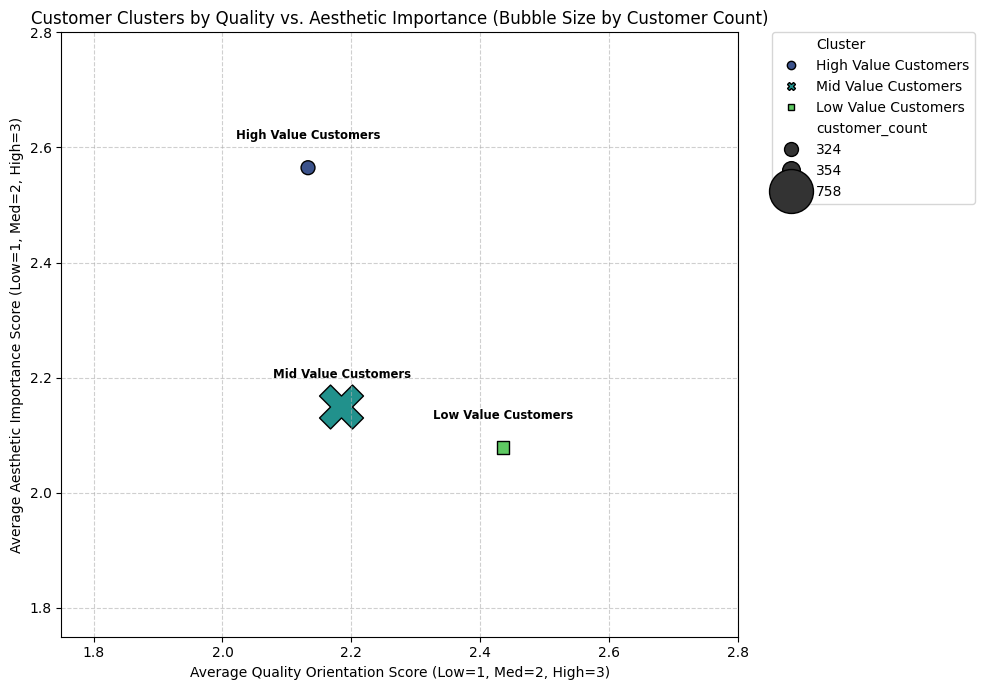

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Ensure rfm_df_with_attitudes is available from previous steps
# (It was created in the cell that generated the last table)

# Define numerical scores for importance levels
importance_scores = {'Low': 1, 'Med': 2, 'High': 3}

# Map original categorical values to numerical scores in rfm_df_with_attitudes
rfm_df_with_attitudes['quality_score'] = rfm_df_with_attitudes['quality_orientation'].map(importance_scores)
rfm_df_with_attitudes['aesthetic_score'] = rfm_df_with_attitudes['aesthetic_importance'].map(importance_scores)

# Calculate the average scores for each cluster
cluster_importance_scores = rfm_df_with_attitudes.groupby('Cluster').agg(
    avg_quality_score=('quality_score', 'mean'),
    avg_aesthetic_score=('aesthetic_score', 'mean')
).reset_index()

# Get customer counts for each cluster to use for bubble size
cluster_counts_for_plot = rfm_df_with_attitudes['Cluster'].value_counts().reset_index()
cluster_counts_for_plot.columns = ['Cluster', 'customer_count']

# Merge counts into the cluster_importance_scores DataFrame
cluster_importance_scores = cluster_importance_scores.merge(cluster_counts_for_plot, on='Cluster', how='left')

# Define the desired order of cluster names for consistent plotting
cluster_order = ['High Value Customers', 'Mid Value Customers', 'Low Value Customers']
cluster_importance_scores['Cluster'] = pd.Categorical(cluster_importance_scores['Cluster'], categories=cluster_order, ordered=True)
cluster_importance_scores = cluster_importance_scores.sort_values('Cluster')

# Create the scatter plot
plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=cluster_importance_scores,
    x='avg_quality_score',
    y='avg_aesthetic_score',
    hue='Cluster',
    size='customer_count', # Use customer_count for bubble size
    sizes=(100, 1000), # Define the range of bubble sizes
    style='Cluster', # Differentiate markers by cluster
    palette='viridis', # Color palette
    edgecolor='black', # Border around points
    linewidth=1
)

# Add cluster names as labels to the points
for index, row in cluster_importance_scores.iterrows():
    plt.text(
        row['avg_quality_score'],
        row['avg_aesthetic_score'] + 0.05, # Offset label slightly above the point
        row['Cluster'],
        horizontalalignment='center',
        size='small',
        color='black',
        weight='semibold'
    )

# Set labels and title
plt.title('Customer Clusters by Quality vs. Aesthetic Importance (Bubble Size by Customer Count)')
plt.xlabel('Average Quality Orientation Score (Low=1, Med=2, High=3)')
plt.ylabel('Average Aesthetic Importance Score (Low=1, Med=2, High=3)')

# Set x and y axis limits for better visualization, based on the new requested range
plt.xlim(1.75, 2.8)
plt.ylim(1.75, 2.8)

# Add grid for readability
plt.grid(True, linestyle='--', alpha=0.6)

# Move legend outside the plot area
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

plt.tight_layout()
plt.show()

#---Cluster x Loyalty | Build a table with Clusters + Total in columns and churn_rate, brand_affinity_score, price_sensitivity, quality_orientation, aesthetic_importance as rows, with % structure sum up to 100% by each cluster

In [ ]:
import matplotlib.pyplot as plt # Needed for colormaps
import numpy as np

# Ensure original_full_df is available from previous steps (f89f6f13)

# 1. Extract customer-level brand loyalty and churn demographics from the original_full_df
customer_loyalty_churn = original_full_df.groupby('customer_id').agg(
    churn_rate=('churn_rate', 'mean'),
    brand_affinity_score=('brand_affinity_score', 'mean'),
    # Average review_star per customer (if a customer made multiple purchases with reviews)
    review_star=('review_star', 'mean')
).reset_index()

# 2. Merge these attributes with the rfm_df (which already has cluster assignments and is indexed by customer_id)
# We use rfm_df.reset_index() first to ensure customer_id is a column for merging
rfm_df_with_loyalty = rfm_df.reset_index().merge(customer_loyalty_churn, on='customer_id', how='left').set_index('customer_id')

# Define the desired order of cluster names
cluster_order = ['High Value Customers', 'Mid Value Customers', 'Low Value Customers']

# 3. Calculate Customer Counts per Cluster (for context)
cluster_counts = rfm_df_with_loyalty['Cluster'].value_counts().reindex(cluster_order)
total_customers = cluster_counts.sum()
customer_counts_data = cluster_counts.tolist() + [total_customers]
customer_counts_df_numeric = pd.DataFrame(
    [customer_counts_data],
    index=['Customer Count'], # Set 'Customer Count' directly as the index label
    columns=cluster_order + ['Total']
)

# 4. Calculate Mean for churn_rate
mean_churn_rate = rfm_df_with_loyalty.groupby('Cluster')['churn_rate'].mean().reindex(cluster_order)
overall_mean_churn_rate = rfm_df_with_loyalty['churn_rate'].mean()
churn_rate_row = mean_churn_rate.tolist() + [overall_mean_churn_rate]
churn_rate_df = pd.DataFrame(
    [churn_rate_row],
    index=['Average Churn Rate'], # Set 'Average Churn Rate' directly as the index label
    columns=cluster_order + ['Total']
)

# 5. Calculate Mean for brand_affinity_score
mean_brand_affinity_score = rfm_df_with_loyalty.groupby('Cluster')['brand_affinity_score'].mean().reindex(cluster_order)
overall_mean_brand_affinity_score = rfm_df_with_loyalty['brand_affinity_score'].mean()
brand_affinity_score_row = mean_brand_affinity_score.tolist() + [overall_mean_brand_affinity_score]
brand_affinity_score_df = pd.DataFrame(
    [brand_affinity_score_row],
    index=['Average Brand Affinity Score'], # Set 'Average Brand Affinity Score' directly as the index label
    columns=cluster_order + ['Total']
)

# 6. Calculate Mean for review_star
mean_review_star = rfm_df_with_loyalty.groupby('Cluster')['review_star'].mean().reindex(cluster_order)
overall_mean_review_star = rfm_df_with_loyalty['review_star'].mean()
review_star_row = mean_review_star.tolist() + [overall_mean_review_star]
review_star_df = pd.DataFrame(
    [review_star_row],
    index=['Average Review Star'], # Set 'Average Review Star' directly as the index label
    columns=cluster_order + ['Total']
)

# 7. Combine all into one DataFrame
final_brand_loyalty_table = pd.concat([
    customer_counts_df_numeric, # Include counts for context
    churn_rate_df,
    brand_affinity_score_df,
    review_star_df
])

# Identify columns for styling
cols_for_style = cluster_order + ['Total']

# Create the Styler object
styled_table = final_brand_loyalty_table.style

# Apply formatting: integer for customer count, decimals for averages
styled_table = styled_table.format(
    lambda x: f"{int(x):,}" if pd.notna(x) else '',
    subset=pd.IndexSlice[['Customer Count'], cols_for_style]
)
styled_table = styled_table.format(
    lambda x: f"{x:.2f}" if pd.notna(x) else '',
    subset=pd.IndexSlice[['Average Churn Rate', 'Average Brand Affinity Score', 'Average Review Star'], cols_for_style]
)

display(styled_table)

,High Value Customers,Mid Value Customers,Low Value Customers,Total
Customer Count,324,758,354,"1,436"
Average Churn Rate,0.12,0.18,0.20,0.17
Average Brand Affinity Score,3.72,3.43,3.74,3.57
Average Review Star,4.17,4.12,4.29,4.17


In [ ]:
annual_loyalty_data = {}

# Define the cluster order for consistency
cluster_order = ['High Value Customers', 'Mid Value Customers', 'Low Value Customers']

for year in years_to_analyze:
    print(f"\nCalculating annual cluster loyalty metrics for year: {year}")

    rfm_df_with_loyalty_annual = rfm_df_with_loyalty_annual_dict[year]

    # 1. Calculate Customer Counts per Cluster
    cluster_counts = rfm_df_with_loyalty_annual['Cluster'].value_counts().reindex(cluster_order)
    total_customers = cluster_counts.sum()
    customer_counts_data = cluster_counts.tolist() + [total_customers]
    customer_counts_df_numeric = pd.DataFrame(
        [customer_counts_data],
        index=['Customer Count'],
        columns=cluster_order + ['Total']
    )

    # 2. Calculate Mean for churn_rate
    mean_churn_rate = rfm_df_with_loyalty_annual.groupby('Cluster')['churn_rate'].mean().reindex(cluster_order)
    overall_mean_churn_rate = rfm_df_with_loyalty_annual['churn_rate'].mean()
    churn_rate_row = mean_churn_rate.tolist() + [overall_mean_churn_rate]
    churn_rate_df = pd.DataFrame(
        [churn_rate_row],
        index=['Average Churn Rate'],
        columns=cluster_order + ['Total']
    )

    # 3. Calculate Mean for brand_affinity_score
    mean_brand_affinity_score = rfm_df_with_loyalty_annual.groupby('Cluster')['brand_affinity_score'].mean().reindex(cluster_order)
    overall_mean_brand_affinity_score = rfm_df_with_loyalty_annual['brand_affinity_score'].mean()
    brand_affinity_score_row = mean_brand_affinity_score.tolist() + [overall_mean_brand_affinity_score]
    brand_affinity_score_df = pd.DataFrame(
        [brand_affinity_score_row],
        index=['Average Brand Affinity Score'],
        columns=cluster_order + ['Total']
    )

    # 4. Calculate Mean for review_star
    mean_review_star = rfm_df_with_loyalty_annual.groupby('Cluster')['review_star'].mean().reindex(cluster_order)
    overall_mean_review_star = rfm_df_with_loyalty_annual['review_star'].mean()
    review_star_row = mean_review_star.tolist() + [overall_mean_review_star]
    review_star_df = pd.DataFrame(
        [review_star_row],
        index=['Average Review Star'],
        columns=cluster_order + ['Total']
    )

    # Combine all into one DataFrame for the current year
    annual_loyalty_table = pd.concat([
        customer_counts_df_numeric,
        churn_rate_df,
        brand_affinity_score_df,
        review_star_df
    ])

    # Store for later analysis and summary
    annual_loyalty_data[year] = annual_loyalty_table

    # Display the table for verification
    cols_for_style = cluster_order + ['Total']
    styled_table = annual_loyalty_table.style.format(
        lambda x: f"{int(x):,}" if pd.notna(x) and x == round(x) else '', # For customer counts, ensures no .00
        subset=pd.IndexSlice[['Customer Count'], cols_for_style]
    ).format(
        lambda x: f"{x:.2f}" if pd.notna(x) else '', # For averages
        subset=pd.IndexSlice[['Average Churn Rate', 'Average Brand Affinity Score', 'Average Review Star'], cols_for_style]
    )

    print(f"\nAnnual Brand Loyalty & Churn Characteristics - Year {year}:")
    display(styled_table)



Calculating annual cluster loyalty metrics for year: 2022

Annual Brand Loyalty & Churn Characteristics - Year 2022:


,High Value Customers,Mid Value Customers,Low Value Customers,Total
Customer Count,324,758,354,"1,436"
Average Churn Rate,0.12,0.17,0.18,0.16
Average Brand Affinity Score,3.71,3.45,3.72,3.58
Average Review Star,4.18,4.17,4.25,4.19



Calculating annual cluster loyalty metrics for year: 2023

Annual Brand Loyalty & Churn Characteristics - Year 2023:


,High Value Customers,Mid Value Customers,Low Value Customers,Total
Customer Count,324,758,354,"1,436"
Average Churn Rate,0.12,0.16,0.17,0.16
Average Brand Affinity Score,3.71,3.43,3.60,3.54
Average Review Star,4.18,4.16,4.19,4.17



Calculating annual cluster loyalty metrics for year: 2024

Annual Brand Loyalty & Churn Characteristics - Year 2024:


,High Value Customers,Mid Value Customers,Low Value Customers,Total
Customer Count,324,758,354,"1,436"
Average Churn Rate,0.12,0.17,0.14,0.15
Average Brand Affinity Score,3.69,3.44,3.52,3.51
Average Review Star,4.20,4.19,4.20,4.19


#---Cluster x Product | build the table where clusters represent columns and Product range represents rows, add totals

In [55]:
import pandas as pd

# Ensure cluster_order is defined based on previous steps
cluster_order = ['High Value Customers', 'Mid Value Customers', 'Low Value Customers']

# 1. Group rfm_df by primary_model_range and Cluster and sum MonetaryValue
monetary_value_by_range_cluster = rfm_df.groupby(['primary_model_range', 'Cluster'])['MonetaryValue'].sum().reset_index()

# 2. Create a pivot table
pivot_table_monetary_value = monetary_value_by_range_cluster.pivot_table(
    index='primary_model_range',
    columns='Cluster',
    values='MonetaryValue',
    aggfunc='sum',
    margins=True # Add row and column totals
)

# Reindex columns to ensure desired cluster order plus 'Total'
pivot_table_monetary_value = pivot_table_monetary_value.reindex(columns=cluster_order + ['All'])

# 3. Rename the 'All' index and column to 'Total' for clarity
pivot_table_monetary_value = pivot_table_monetary_value.rename(index={'All': 'Total'}, columns={'All': 'Total'})

# 4. Format the entire table as currency (e.g., "$123,456") without decimals
styled_table = pivot_table_monetary_value.style.format(
    lambda x: f"${x:,.0f}" if pd.notna(x) else ''
)

# 5. Display the formatted table
print("Total Retail Price by Primary Model Range and Cluster:")
display(styled_table)

Total Retail Price by Primary Model Range and Cluster:


Cluster,High Value Customers,Mid Value Customers,Low Value Customers,Total
primary_model_range,,,,
Aura_GO,"$457,820","$559,040","$123,160","$1,140,020"
Aura_PRO,"$1,175,700","$866,320","$501,860","$2,543,880"
Total,"$1,633,520","$1,425,360","$625,020","$3,683,900"


In [61]:
import pandas as pd

# Ensure cluster_order is defined based on previous steps
cluster_order = ['High Value Customers', 'Mid Value Customers', 'Low Value Customers']

# 1. Group rfm_df by primary_model_range and Cluster and sum Frequency
transaction_count_by_range_cluster = rfm_df.groupby(['primary_model_range', 'Cluster'])['Frequency'].sum().reset_index()

# 2. Create a pivot table
pivot_table_transaction_count = transaction_count_by_range_cluster.pivot_table(
    index='primary_model_range',
    columns='Cluster',
    values='Frequency',
    aggfunc='sum',
    margins=True # Add row and column totals
)

# Reindex columns to ensure desired cluster order plus 'Total'
pivot_table_transaction_count = pivot_table_transaction_count.reindex(columns=cluster_order + ['All'])

# 3. Rename the 'All' index and column to 'Total' for clarity
pivot_table_transaction_count = pivot_table_transaction_count.rename(index={'All': 'Total'}, columns={'All': 'Total'})

# 4. Format the entire table as integers (e.g., "123,456") without decimals
styled_table = pivot_table_transaction_count.style.format(
    lambda x: f"{int(x):,}" if pd.notna(x) else ''
)

# 5. Display the formatted table
print("Total Transaction Count by Primary Model Range and Cluster:")
display(styled_table)

Total Transaction Count by Primary Model Range and Cluster:


Cluster,High Value Customers,Mid Value Customers,Low Value Customers,Total
primary_model_range,,,,
Aura_GO,349,"1,064","1,585","2,998"
Aura_PRO,348,"1,395",813,"2,556"
Total,697,"2,459","2,398","5,554"


TOP 5 SKU | what are top 5 product_id for High Value Customers in total counts and total retail_price

In [39]:
# Filter for 'High Value Customers'
high_value_customer_data = merged_df[merged_df['Cluster'] == 'High Value Customers']

# Group by product_id and calculate both total retail price and total transaction counts
product_summary_hv = high_value_customer_data.groupby('product_id').agg(
    total_retail_price=('retail_price', 'sum'),
    total_transactions=('transaction_id', 'count')
).reset_index()

# Find top 5 by Total Retail Price
top_products_by_price_hv = product_summary_hv.nlargest(5, 'total_retail_price')
print("Top 5 Product IDs for High Value Customers (by Total Retail Price):")
display(top_products_by_price_hv)

# Find top 5 by Total Transactions
top_products_by_count_hv = product_summary_hv.nlargest(5, 'total_transactions')
print("\nTop 5 Product IDs for High Value Customers (by Total Transactions Count):")
display(top_products_by_count_hv)

Top 5 Product IDs for High Value Customers (by Total Retail Price):


,product_id,total_retail_price,total_transactions
7,PRO_X,168000,120
6,PRO_STUDIO,166500,111
5,PRO_CLASSIC,141600,118
3,GO_MAX,37760,118
0,GO_ACTIVE,34440,123



Top 5 Product IDs for High Value Customers (by Total Transactions Count):


,product_id,total_retail_price,total_transactions
0,GO_ACTIVE,34440,123
2,GO_LITE,26620,121
7,PRO_X,168000,120
1,GO_AIR,21240,118
3,GO_MAX,37760,118


TOP 5 SKU |what are top 5 product_id for Mid Value Customers in total counts and total retail_price

In [ ]:
# Filter for 'Mid Value Customers'
mid_value_customer_data = merged_df[merged_df['Cluster'] == 'Mid Value Customers']

# Group by product_id and calculate both total retail price and total transaction counts
product_summary_mv = mid_value_customer_data.groupby('product_id').agg(
    total_retail_price=('retail_price', 'sum'),
    total_transactions=('transaction_id', 'count')
).reset_index()

# Find top 5 by Total Retail Price
top_products_by_price_mv = product_summary_mv.nlargest(5, 'total_retail_price')
print("Top 5 Product IDs for Mid Value Customers (by Total Retail Price):")
display(top_products_by_price_mv)

# Find top 5 by Total Transactions
top_products_by_count_mv = product_summary_mv.nlargest(5, 'total_transactions')
print("\nTop 5 Product IDs for Mid Value Customers (by Total Transactions Count):")
display(top_products_by_count_mv)

Top 5 Product IDs for Mid Value Customers (by Total Retail Price):


,product_id,total_retail_price,total_transactions
6,PRO_STUDIO,306000,204
7,PRO_X,256200,183
5,PRO_CLASSIC,217200,181
3,GO_MAX,160320,501
0,GO_ACTIVE,144480,516



Top 5 Product IDs for Mid Value Customers (by Total Transactions Count):


,product_id,total_retail_price,total_transactions
2,GO_LITE,118360,538
1,GO_AIR,95400,530
0,GO_ACTIVE,144480,516
3,GO_MAX,160320,501
4,GO_PLUS,127400,490


TOP 5 SKU |what are top 5 product_id for Low Value Customers in total counts and total retail_price

In [ ]:
# Filter for 'Low Value Customers'
low_value_customer_data = merged_df[merged_df['Cluster'] == 'Low Value Customers']

# Group by product_id and calculate both total retail price and total transaction counts
product_summary_lv = low_value_customer_data.groupby('product_id').agg(
    total_retail_price=('retail_price', 'sum'),
    total_transactions=('transaction_id', 'count')
).reset_index()

# Find top 5 by Total Retail Price
top_products_by_price_lv = product_summary_lv.nlargest(5, 'total_retail_price')
print("Top 5 Product IDs for Low Value Customers (by Total Retail Price):")
display(top_products_by_price_lv)

# Find top 5 by Total Transactions
top_products_by_count_lv = product_summary_lv.nlargest(5, 'total_transactions')
print("\nTop 5 Product IDs for Low Value Customers (by Total Transactions Count):")
display(top_products_by_count_lv)

Top 5 Product IDs for Low Value Customers (by Total Retail Price):


,product_id,total_retail_price,total_transactions
7,PRO_X,168000,120
6,PRO_STUDIO,166500,111
5,PRO_CLASSIC,141600,118
3,GO_MAX,37760,118
0,GO_ACTIVE,34440,123



Top 5 Product IDs for Low Value Customers (by Total Transactions Count):


,product_id,total_retail_price,total_transactions
0,GO_ACTIVE,34440,123
2,GO_LITE,26620,121
7,PRO_X,168000,120
1,GO_AIR,21240,118
3,GO_MAX,37760,118


#CLTV ANALYSIS

#---var_COST OF REFERRING CHANNAL
Create additional variable "Cost of Referring Channel" that represents the sum of "Cost per Referring Channel" for each transaction_id for each unique customer_id

#---var_COST OF REFERRAL DISCOUNT
Create additional variable "Cost of Referral Discount" that represents 10% of an average "retail_price" for each transaction_id for each unique customer_id. 1) you should apply "Cost of Referral Discount" only to those customer_id where referral_discount=1 (the customer get discount, not to all customers)

2) for those customer who got the discount, you should calculate an average  retail price for this customer (not for all transactions).

3) calculate the sum of discount individually for each customer

In [124]:
import pandas as pd
import numpy as np
from google.colab import drive

# --- Ensure df is fully loaded and pre-processed for this operation ---
# This block ensures 'df' is in the expected state regardless of previous cell executions
drive.mount('/content/drive', force_remount=True) # Ensure drive is mounted
file_path = "/content/drive/MyDrive/AURA/transaction_data.xlsx"
df = pd.read_excel(file_path, sheet_name="transaction_data")

df['transaction_date'] = pd.to_datetime(df['transaction_date'])
df['transaction_year'] = df['transaction_date'].dt.year
df['gross_margin_abs'] = df['retail_price'] - df['cogs']
df['gross_margin_%'] = (df['gross_margin_abs'] / df['retail_price']) * 100

aura_go_products = ['GO_ACTIVE', 'GO_AIR', 'GO_LITE', 'GO_MAX', 'GO_PLUS']
aura_pro_products = ['PRO_CLASSIC', 'PRO_STUDIO', 'PRO_X']
df['model_range'] = np.select(
    [
        df['product_id'].isin(aura_go_products),
        df['product_id'].isin(aura_pro_products)
    ],
    [
        'Aura_GO',
        'Aura_PRO'
    ],
    default='Other'
)
# --- End df reconstruction ---

# Ensure 'Cost per Referring Channel' exists in referring_channel_analysis and that referring_channel is in df
# (Assuming referring_channel_analysis is available from the previous step)

# 1. Merge the 'Cost per Referring Channel' from referring_channel_analysis into df
# Need to ensure 'referring_channel_analysis' does not contain the 'Total' row before merging,
# as 'Total' is not a valid referring channel for individual transactions.
referring_channel_costs_for_merge = referring_channel_analysis[referring_channel_analysis['Referring Channel'] != 'Total'][['Referring Channel', 'Cost per Referring Channel']]

# FIX: Specify left_on and right_on to match the different column names
df_with_referring_costs = pd.merge(df, referring_channel_costs_for_merge, left_on='referring_channel', right_on='Referring Channel', how='left')

# Fill any NaN values if a referring_channel from df didn't match (e.g., 'Other' or unexpected values)
# For simplicity, we'll assume unmatched channels have 0 cost, or impute based on context.
# Here, setting to 0 for any missing costs.
df_with_referring_costs['Cost per Referring Channel'] = df_with_referring_costs['Cost per Referring Channel'].fillna(0)

# 2. Calculate the sum of 'Cost per Referring Channel' for each unique customer_id
cost_of_referring_channel_per_customer = df_with_referring_costs.groupby('customer_id')['Cost per Referring Channel'].sum().reset_index()
cost_of_referring_channel_per_customer.rename(columns={'Cost per Referring Channel': 'Cost of Referring Channel'}, inplace=True)

# 3. Add this new variable to rfm_df
# Assuming rfm_df is currently indexed by customer_id
if 'customer_id' not in rfm_df.columns:
    rfm_df_temp = rfm_df.reset_index()
else:
    rfm_df_temp = rfm_df.copy()

rfm_df = pd.merge(rfm_df_temp, cost_of_referring_channel_per_customer, on='customer_id', how='left').set_index('customer_id')

# Delete unwanted columns (e.g., from previous merge attempts)
columns_to_delete = ['Cost of Referring Channel_x', 'Cost of Referral Discount_x', 'Cost of Referral Discount_y', 'Cost of Referring Channel_y']
for col in columns_to_delete:
    if col in rfm_df.columns:
        rfm_df = rfm_df.drop(columns=[col])

print("RFM DataFrame with 'Cost of Referring Channel' variable:")
display(rfm_df.head())

Mounted at /content/drive
RFM DataFrame with 'Cost of Referring Channel' variable:


,Recency,Frequency,MonetaryValue,R_Segment,F_Segment,M_Segment,Recency_Inverted,R_norm,F_norm,M_norm,Cluster,primary_model_range,Individual_Churn_Rate,Retention_Rate_Individual
customer_id,,,,,,,,,,,,,,
C00001,58,3,620,Active,Occasional,Low Value,1027,0.946544,0.153846,0.024803,Low Value Customers,Aura_GO,0.19,0.81
C00002,222,6,4260,Warm,Loyal,High Value,863,0.795392,0.384615,0.229989,Mid Value Customers,Aura_PRO,0.07,0.93
C00003,411,1,880,At Risk,One-timers,Low Value,674,0.621198,0.000000,0.039459,Low Value Customers,Aura_GO,0.16,0.84
C00004,439,3,720,At Risk,Occasional,Low Value,646,0.595392,0.153846,0.030440,Low Value Customers,Aura_GO,0.17,0.83
C00006,164,4,5900,Warm,Loyal,High Value,921,0.848848,0.230769,0.322435,Low Value Customers,Aura_PRO,0.22,0.78


#---var_COGS_INDIVIDUAL
Create a variable "COGS_Individual" that represents a sum of cogs by each transaction_id for each customer_id (that will be total cogs for individual customer)

In [138]:
cogs_per_customer = df.groupby('customer_id')['cogs'].sum().reset_index()
cogs_per_customer.rename(columns={'cogs': 'COGS_Individual'}, inplace=True)

print("COGS_Individual per customer:")
display(cogs_per_customer.head())

COGS_Individual per customer:


,customer_id,COGS_Individual
0,C00001,425.2
1,C00002,2122.0
2,C00003,597.6
3,C00004,486.8
4,C00006,2360.0


#---var_ACQUISITION COST INDIVIDUAL
Calculate ACQUISITION_COST_Individual for each customer by summing Cost of Referral Discount and Cost of Referring Channel. Add this as a new column to rfm_df.


In [139]:
rfm_df['ACQUISITION_COST_Individual'] = rfm_df['Cost of Referral Discount'] + rfm_df['Cost of Referring Channel']

print("RFM DataFrame with 'ACQUISITION_COST_Individual' column:")
display(rfm_df.head())

RFM DataFrame with 'ACQUISITION_COST_Individual' column:


,Recency,Frequency,MonetaryValue,R_Segment,F_Segment,M_Segment,Recency_Inverted,R_norm,F_norm,M_norm,...,REVENUE_Individual,ITEMS_Individual,COGS_Individual,Cost of Referral Discount,Cost of Referring Channel,GROSS PROFIT_Individual,OPERATING PROFIT_Individual,Individual_Churn_Rate,Retention_Rate_Individual,ACQUISITION_COST_Individual
customer_id,,,,,,,,,,,,,,,,,,,,,
C00001,58,3,620,Active,Occasional,Low Value,1027,0.946544,0.153846,0.024803,...,620,3,425.2,0.0,125.851787,194.8,68.948213,0.19,0.81,125.851787
C00002,222,6,4260,Warm,Loyal,High Value,863,0.795392,0.384615,0.229989,...,4260,9,2122.0,140.0,166.535898,2138.0,1831.464102,0.07,0.93,306.535898
C00003,411,1,880,At Risk,One-timers,Low Value,674,0.621198,0.000000,0.039459,...,880,3,597.6,0.0,138.408304,282.4,143.991696,0.16,0.84,138.408304
C00004,439,3,720,At Risk,Occasional,Low Value,646,0.595392,0.153846,0.030440,...,720,3,486.8,0.0,114.008538,233.2,119.191462,0.17,0.83,114.008538
C00006,164,4,5900,Warm,Loyal,High Value,921,0.848848,0.230769,0.322435,...,5900,4,2360.0,0.0,147.819041,3540.0,3392.180959,0.22,0.78,147.819041


#---var_COST OF REVENUE INDIVIDUAL
Create a variable "REVENUE_Individual" that represents a sum of retail_price for each transaction_id for each customer_id (that will be total sales for individual customer)

In [126]:
revenue_per_customer = df.groupby('customer_id')['retail_price'].sum().reset_index()
revenue_per_customer.rename(columns={'retail_price': 'REVENUE_Individual'}, inplace=True)

print("REVENUE_Individual per customer:")
display(revenue_per_customer.head())

REVENUE_Individual per customer:


,customer_id,REVENUE_Individual
0,C00001,620
1,C00002,4260
2,C00003,880
3,C00004,720
4,C00006,5900


#---var_ITEMS INDIVIDUAL
Create a variable "ITEMS_Individual" that represents a sum of transaction_id for each customer_id (that will be total number for individual customer)

In [127]:
items_per_customer = df.groupby('customer_id')['transaction_id'].nunique().reset_index()
items_per_customer.rename(columns={'transaction_id': 'ITEMS_Individual'}, inplace=True)

print("ITEMS_Individual per customer:")
display(items_per_customer.head())

ITEMS_Individual per customer:


,customer_id,ITEMS_Individual
0,C00001,3
1,C00002,6
2,C00003,1
3,C00004,3
4,C00006,4


#---var_GROSS PROFIT INDIVIDUAL
Create a variable "GROSS PROFIT_Individual" that represents a difference between REVENUE_Individual and COGS_Individual for each customer_id

#---var_OPERATING PROFIT INDIVIDUAL
Create a variable "OPERATING PROFIT_Individual" that represents GROSS PROFIT_Individual minus Cost of Referral Discount and Cost of Referring Channel for each customer_id

#---var_RETENTION RATE
Calculate the average churn_rate for each unique customer_id from the df DataFrame, and then merge this Individual_Churn_Rate into the rfm_df. Subsequently, calculate Retention_Rate_Individual as 1 - Individual_Churn_Rate and add it to rfm_df.


#---ALL VARIABLES FOR CLTV
Build the table where Clusters represent columns and rows will be
1) counts by each cluster + total for 3 clusters
2) total REVENUE_Individual + total for 3 clusters
3) total ITEMS_Individual + total for 3 clusters
4) total Cost of Referral Discount + total for 3 clusters
5) total Cost of Referring Channel + total for 3 clusters
6) total COGS_Individual + total for 3 clusters
7) total GROSS PROFIT_Individual + total for 3 clusters
8) total OPERATING PROFIT_Individual + total for 3 clusters

Add these variables to rfm_df - REVENUE_Individual, ITEMS_Individual, Cost of Referral Discount, Cost of Referring Channel, COGS_Individual, GROSS PROFIT_Individual, OPERATING PROFIT, Cost of Acquisition, Retention Rate

In [248]:
import pandas as pd

# Ensure df is available and contains 'churn_rate'
# We need to extract the individual churn_rate for each customer_id and merge it with rfm_df
customer_churn_rates = df.groupby('customer_id')['churn_rate'].mean().reset_index()
customer_churn_rates.rename(columns={'churn_rate': 'Individual_Churn_Rate'}, inplace=True)

# Set customer_id as index for customer_churn_rates to prepare for direct assignment
customer_churn_rates.set_index('customer_id', inplace=True)

# Directly assign Individual_Churn_Rate from customer_churn_rates to rfm_df
rfm_df['Individual_Churn_Rate'] = customer_churn_rates['Individual_Churn_Rate']

# Fill any NaN values with the overall mean churn_rate from df
overall_mean_churn_rate = df['churn_rate'].mean()
rfm_df['Individual_Churn_Rate'] = rfm_df['Individual_Churn_Rate'].fillna(overall_mean_churn_rate)

# Calculate Retention_Rate_Individual
rfm_df['Retention_Rate_Individual'] = 1 - rfm_df['Individual_Churn_Rate']

print("RFM DataFrame with 'Individual_Churn_Rate' and 'Retention_Rate_Individual':")
display(rfm_df.head())

RFM DataFrame with 'Individual_Churn_Rate' and 'Retention_Rate_Individual':


,Recency,Frequency,MonetaryValue,R_Segment,F_Segment,M_Segment,Recency_Inverted,R_norm,F_norm,M_norm,...,COGS_Individual,Cost of Referral Discount,Cost of Referring Channel,GROSS PROFIT_Individual,OPERATING PROFIT_Individual,Individual_Churn_Rate,Retention_Rate_Individual,ACQUISITION_COST_Individual,CLTV_Individual_Gross,CLTV_Individual_Net
customer_id,,,,,,,,,,,,,,,,,,,,,
C00001,58,3,620,Active,Occasional,Low Value,1027,0.946544,0.153846,0.024803,...,425.2,0.0,125.851787,194.8,68.948213,0.19,0.81,125.851787,544.096552,418.244765
C00002,222,6,4260,Warm,Loyal,High Value,863,0.795392,0.384615,0.229989,...,2122.0,140.0,166.535898,2138.0,1831.464102,0.07,0.93,306.535898,11696.117647,11389.581749
C00003,411,1,880,At Risk,One-timers,Low Value,674,0.621198,0.000000,0.039459,...,597.6,0.0,138.408304,282.4,143.991696,0.16,0.84,138.408304,912.369231,773.960926
C00004,439,3,720,At Risk,Occasional,Low Value,646,0.595392,0.153846,0.030440,...,486.8,0.0,114.008538,233.2,119.191462,0.17,0.83,114.008538,716.874074,602.865536
C00006,164,4,5900,Warm,Loyal,High Value,921,0.848848,0.230769,0.322435,...,2360.0,0.0,147.819041,3540.0,3392.180959,0.22,0.78,147.819041,8628.750000,8480.930959


#---CLTV RESLTS

Build the table where clusters will be in columns and in rows will be
1) counts (number on customers in each cluster) + total
2) total Gross profit by each cluster + total
3) average Gross profit by each cluster + total
4) retention rate by each cluster + average for three clusters
5) acquisition cost (cost of referral disc + cost pf referring channel) by each cluster + total
6) discount rate will be 10% for all clusters
7) Life Time Value for every cluster + total

formula of LTV, which is (Gross Profit x retention Rate) / (1+discount rate - retention rate) and then minus acquisition cos.

Add these variables to rfm_df - COGS_Individual, Cost of Referral Discount, Cost of Referring Channel, GROSS PROFIT_Individual, OPERATING PROFIT_Individual, Individual_Churn_Rate, Retention_Rate_Individual, ACQUISITION_COST_Individual, CLTV_Individual_Gross, CLTV_Individual_Net

In [250]:
if 'CLTV_Individual_Gross' not in rfm_df.columns:
    print("Error: 'CLTV_Individual_Gross' not found. Please ensure it's calculated.")
elif 'ACQUISITION_COST_Individual' not in rfm_df.columns:
    print("Error: 'ACQUISITION_COST_Individual' not found. Please ensure it's calculated.")
else:
    rfm_df['CLTV_Individual_Net'] = rfm_df['CLTV_Individual_Gross'] - rfm_df['ACQUISITION_COST_Individual']
    print("RFM DataFrame with 'CLTV_Individual_Net' column:")
display(rfm_df.head())

RFM DataFrame with 'CLTV_Individual_Net' column:


,Recency,Frequency,MonetaryValue,R_Segment,F_Segment,M_Segment,Recency_Inverted,R_norm,F_norm,M_norm,...,COGS_Individual,Cost of Referral Discount,Cost of Referring Channel,GROSS PROFIT_Individual,OPERATING PROFIT_Individual,Individual_Churn_Rate,Retention_Rate_Individual,ACQUISITION_COST_Individual,CLTV_Individual_Gross,CLTV_Individual_Net
customer_id,,,,,,,,,,,,,,,,,,,,,
C00001,58,3,620,Active,Occasional,Low Value,1027,0.946544,0.153846,0.024803,...,425.2,0.0,125.851787,194.8,68.948213,0.19,0.81,125.851787,544.096552,418.244765
C00002,222,6,4260,Warm,Loyal,High Value,863,0.795392,0.384615,0.229989,...,2122.0,140.0,166.535898,2138.0,1831.464102,0.07,0.93,306.535898,11696.117647,11389.581749
C00003,411,1,880,At Risk,One-timers,Low Value,674,0.621198,0.000000,0.039459,...,597.6,0.0,138.408304,282.4,143.991696,0.16,0.84,138.408304,912.369231,773.960926
C00004,439,3,720,At Risk,Occasional,Low Value,646,0.595392,0.153846,0.030440,...,486.8,0.0,114.008538,233.2,119.191462,0.17,0.83,114.008538,716.874074,602.865536
C00006,164,4,5900,Warm,Loyal,High Value,921,0.848848,0.230769,0.322435,...,2360.0,0.0,147.819041,3540.0,3392.180959,0.22,0.78,147.819041,8628.750000,8480.930959


In [251]:
import pandas as pd
import numpy as np

# Define the desired order of cluster names
cluster_order = ['High Value Customers', 'Mid Value Customers', 'Low Value Customers']

# 1. Define lists of metrics for aggregation
monetary_metrics_to_sum = [
    'REVENUE_Individual',
    'ITEMS_Individual',
    'COGS_Individual',
    'Cost of Referral Discount',
    'Cost of Referring Channel',
    'GROSS PROFIT_Individual',
    'ACQUISITION_COST_Individual',
    'CLTV_Individual_Gross',
    'CLTV_Individual_Net'
]

metrics_to_average = [
    'GROSS PROFIT_Individual',
    'Retention_Rate_Individual',
    'CLTV_Individual_Gross',
    'CLTV_Individual_Net'
]

# Create an aggregation dictionary with original column names as keys and functions as values
# This time, construct agg_dict more carefully to avoid conflicts and use original names as keys
agg_dict_sum = {col: 'sum' for col in monetary_metrics_to_sum}
agg_dict_mean = {col: 'mean' for col in metrics_to_average}

# Combine sums and means, making sure means are for columns *not* already summed
combined_agg_dict = {}
for k, v in agg_dict_sum.items():
    combined_agg_dict[k + '_sum'] = (k, v) # Store as original_col_name_sum
for k, v in agg_dict_mean.items():
    combined_agg_dict[k + '_mean'] = (k, v) # Store as original_col_name_mean

# 2. Group rfm_df by 'Cluster' and calculate aggregates
cluster_summary = rfm_df.groupby('Cluster').agg(**combined_agg_dict)

# Rename columns to the desired descriptive names after aggregation
rename_map = {
    'REVENUE_Individual_sum': 'Total REVENUE_Individual',
    'ITEMS_Individual_sum': 'Total ITEMS_Individual',
    'COGS_Individual_sum': 'Total COGS_Individual',
    'Cost of Referral Discount_sum': 'Total Cost of Referral Discount',
    'Cost of Referring Channel_sum': 'Total Cost of Referring Channel',
    'GROSS PROFIT_Individual_sum': 'Total Gross Profit',
    'ACQUISITION_COST_Individual_sum': 'Total Acquisition Cost',
    'CLTV_Individual_Gross_sum': 'Total CLTV (Gross)',
    'CLTV_Individual_Net_sum': 'Total CLTV (Net)',
    'GROSS PROFIT_Individual_mean': 'Average Gross Profit',
    'Retention_Rate_Individual_mean': 'Average Retention Rate',
    'CLTV_Individual_Gross_mean': 'Average CLTV (Gross)',
    'CLTV_Individual_Net_mean': 'Average CLTV (Net)'
}

cluster_summary = cluster_summary.rename(columns=rename_map)

# Insert customer count as the first column
customer_counts = rfm_df['Cluster'].value_counts()
cluster_summary.insert(0, 'Customer Count', customer_counts)

# 3. Calculate Overall Totals (across all clusters)
# Sum of sums for totals (e.g., total revenue, total gross profit)
overall_totals_sum = cluster_summary.drop(columns=['Average Gross Profit', 'Average Retention Rate', 'Average CLTV (Gross)', 'Average CLTV (Net)']).sum()
overall_totals_sum['Customer Count'] = len(rfm_df) # Total unique customers

# Averages for totals (e.g., overall average gross profit, overall average retention rate)
overall_totals_avg = pd.Series({
    'Average Gross Profit': rfm_df['GROSS PROFIT_Individual'].mean(),
    'Average Retention Rate': rfm_df['Retention_Rate_Individual'].mean(),
    'Average CLTV (Gross)': rfm_df['CLTV_Individual_Gross'].mean(),
    'Average CLTV (Net)': rfm_df['CLTV_Individual_Net'].mean()
})

# Combine sums and averages into a single overall_totals Series/DataFrame
overall_totals_combined = pd.concat([overall_totals_sum, overall_totals_avg])
overall_totals = pd.DataFrame(overall_totals_combined).T
overall_totals.index = ['Total']

# Reindex overall_totals to match cluster_summary columns, filling NaNs (where an average might not have a direct sum counterpart)
overall_totals = overall_totals.reindex(columns=cluster_summary.columns)

# 4. Combine Cluster Summary and Overall Totals
final_table_raw = pd.concat([cluster_summary, overall_totals])

# Reorder rows (clusters + Total) to ensure consistency
final_table_final = final_table_raw.reindex(cluster_order + ['Total'])

# 5. Define formatting for display
formatters = {}
for col_name in final_table_final.columns:
    if 'Customer Count' in col_name or 'ITEMS_Individual' in col_name:
        formatters[col_name] = "{:,.0f}"  # Integer format
    elif 'Rate' in col_name:
        formatters[col_name] = "{:.2%}"  # Percentage format
    else:
        formatters[col_name] = "${:,.0f}" # Currency format

# Apply formatting
styled_table = final_table_final.style.format(formatters)

print("Aggregated financial metrics per customer cluster:")
display(styled_table)


Aggregated financial metrics per customer cluster:


,Customer Count,Total REVENUE_Individual,Total ITEMS_Individual,Total COGS_Individual,Total Cost of Referral Discount,Total Cost of Referring Channel,Total Gross Profit,Total Acquisition Cost,Total CLTV (Gross),Total CLTV (Net),Average Gross Profit,Average Retention Rate,Average CLTV (Gross),Average CLTV (Net)
High Value Customers,324,"$1,633,520","2,459","$832,468","$6,838","$98,273","$801,052","$105,111","$3,526,926","$3,421,815","$2,472",88.35%,"$10,886","$10,561"
Mid Value Customers,758,"$1,425,360","2,398","$749,885","$3,676","$93,694","$675,475","$97,370","$1,989,890","$1,892,520",$891,82.12%,"$2,625","$2,497"
Low Value Customers,354,"$625,020",697,"$291,431",$914,"$28,032","$333,589","$28,946","$866,551","$837,605",$942,80.44%,"$2,448","$2,366"
Total,"1,436","$3,683,900","5,554","$1,873,785","$11,428","$220,000","$1,810,115","$231,428","$6,383,367","$6,151,939","$1,261",83.11%,"$4,445","$4,284"


#MARKETING EXPERIMENT


show me results of experiment_condition

Distribution of Experiment Conditions:


,count
experiment_condition,
Influencer,3832
Professional,2399
Control,1149


In [254]:
overall_cost_per_channel = referring_channel_analysis[referring_channel_analysis['Referring Channel'] != 'Total'][['Referring Channel', 'Cost per Referring Channel']]

print("Overall Cost per Referring Channel for each channel:")
display(overall_cost_per_channel)

Overall Cost per Referring Channel for each channel:


,Referring Channel,Cost per Referring Channel
0,Search,46.136101
1,Social,33.579584
2,Email,14.204545
3,Direct,0.000000
4,ReviewSite,10.626993
5,Affiliate,80.428954



Build the table results of experiment_condition represents row and referring_channel represents columns, use counts as values

Build the table where experiment_condition represents row and referring_channel represents columns, use cost of channels divided on counts as values. Cost of channels is following :  Affiliate=60000, Direct=0, Email=20000, ReviewSite=10000, Search=80000, Social. add totals by rows and columns as an average.
that will be not cost of transaction - it will be cost of contact

In [256]:
import pandas as pd

# 1. Count occurrences of referring_channel for each experiment_condition
channel_counts_by_experiment = df.groupby(['experiment_condition', 'referring_channel']).size().reset_index(name='contact_count')

# 2. Merge with overall_cost_per_channel to get Cost per Referring Channel
channel_costs_merged = pd.merge(channel_counts_by_experiment,
                                overall_cost_per_channel,
                                left_on='referring_channel',
                                right_on='Referring Channel',
                                how='left')

# Fill any NaN costs (e.g., if a channel has no defined cost) with 0
channel_costs_merged['Cost per Referring Channel'] = channel_costs_merged['Cost per Referring Channel'].fillna(0)

# 3. Calculate total cost for each combination
channel_costs_merged['total_channel_cost'] = channel_costs_merged['contact_count'] * channel_costs_merged['Cost per Referring Channel']

print("Calculated total channel costs per experiment condition:")
display(channel_costs_merged.head())

Calculated total channel costs per experiment condition:


,experiment_condition,referring_channel,contact_count,Referring Channel,Cost per Referring Channel,total_channel_cost
0,Control,Affiliate,127,Affiliate,80.428954,10214.477212
1,Control,Direct,160,Direct,0.000000,0.000000
2,Control,Email,189,Email,14.204545,2684.659091
3,Control,ReviewSite,213,ReviewSite,10.626993,2263.549416
4,Control,Search,252,Search,46.136101,11626.297578


In [258]:
total_channel_counts = referring_channel_analysis[referring_channel_analysis['Referring Channel'] != 'Total'][['Referring Channel', 'Total Count of Referring Channel']]

print("Extracted total channel counts:")
display(total_channel_counts.head())

Extracted total channel counts:


,Referring Channel,Total Count of Referring Channel
0,Search,1734
1,Social,1489
2,Email,1408
3,Direct,1062
4,ReviewSite,941


In [259]:
import pandas as pd

# Create a pivot table with experiment_condition as index, referring_channel as columns, and counts as values
experiment_channel_counts = pd.crosstab(
    index=df['experiment_condition'],
    columns=df['referring_channel'],
    margins=True  # Adds row and column totals
)

# Rename the 'All' column/index from margins to 'Total' for clarity
experiment_channel_counts = experiment_channel_counts.rename(index={'All': 'Total'}, columns={'All': 'Total'})

print("Table showing counts of referring_channel by experiment_condition with totals:")
display(experiment_channel_counts)

Table showing counts of referring_channel by experiment_condition with totals:


referring_channel,Affiliate,Direct,Email,ReviewSite,Search,Social,Total
experiment_condition,,,,,,,
Control,127,160,189,213,252,208,1149
Influencer,357,556,782,385,920,832,3832
Professional,262,346,437,343,562,449,2399
Total,746,1062,1408,941,1734,1489,7380


In [260]:
display(styled_table)

referring_channel,Affiliate,Direct,Email,ReviewSite,Search,Social,Row_Average
experiment_condition,,,,,,,
Control,$80.43,$0.00,$14.20,$10.63,$46.14,$33.58,$30.83
Influencer,$80.43,$0.00,$14.20,$10.63,$46.14,$33.58,$30.83
Professional,$80.43,$0.00,$14.20,$10.63,$46.14,$33.58,$30.83
Column_Average,$80.43,$0.00,$14.20,$10.63,$46.14,$33.58,$30.83


Calculate Unique Customer Counts per Channel and Experiment Condition



In [261]:
import pandas as pd

# Calculate unique customer counts for each combination of experiment_condition and referring_channel
unique_customers_counts = pd.crosstab(
    index=df['experiment_condition'],
    columns=df['referring_channel'],
    values=df['customer_id'],
    aggfunc='nunique',
    margins=True  # Adds row and column totals
)

# Rename the 'All' column/index from margins to 'Total' for clarity
unique_customers_counts = unique_customers_counts.rename(index={'All': 'Total'}, columns={'All': 'Total'})

print("Table showing unique customer counts by experiment_condition and referring_channel with totals:")
display(unique_customers_counts)

Table showing unique customer counts by experiment_condition and referring_channel with totals:


referring_channel,Affiliate,Direct,Email,ReviewSite,Search,Social,Total
experiment_condition,,,,,,,
Control,89,119,132,149,185,147,638
Influencer,230,329,449,261,526,473,1090
Professional,190,234,277,239,346,285,1032
Total,462,583,682,550,808,716,1436


In [262]:
import pandas as pd

# Create the pivot table with experiment_condition as index, referring_channel as columns,
# and total_channel_cost as values. Use sum for aggregation.
marketing_cost_pivot = pd.pivot_table(
    channel_costs_merged,
    values='total_channel_cost',
    index='experiment_condition',
    columns='referring_channel',
    aggfunc='sum',
    margins=True  # This adds row and column totals
)

# Rename the 'All' column/index from margins to 'Total' for clarity
marketing_cost_pivot = marketing_cost_pivot.rename(index={'All': 'Total'}, columns={'All': 'Total'})

# Format the table as currency for better readability
styled_table = marketing_cost_pivot.style.format(lambda x: f"${x:,.0f}" if pd.notna(x) else '')

print("Total Marketing Cost by Experiment Condition and Referring Channel:")
display(styled_table)

Total Marketing Cost by Experiment Condition and Referring Channel:


referring_channel,Affiliate,Direct,Email,ReviewSite,Search,Social,Total
experiment_condition,,,,,,,
Control,"$10,214",$0,"$2,685","$2,264","$11,626","$6,985","$33,774"
Influencer,"$28,713",$0,"$11,108","$4,091","$42,445","$27,938","$114,296"
Professional,"$21,072",$0,"$6,207","$3,645","$25,928","$15,077","$71,931"
Total,"$60,000",$0,"$20,000","$10,000","$80,000","$50,000","$220,000"


In [263]:
import pandas as pd

# Calculate the total retail price for each combination of experiment_condition and referring_channel
total_revenue_pivot = pd.pivot_table(
    df,
    values='retail_price',
    index='experiment_condition',
    columns='referring_channel',
    aggfunc='sum',
    margins=True  # This adds row and column totals
)

# Rename the 'All' column/index from margins to 'Total' for clarity
total_revenue_pivot = total_revenue_pivot.rename(index={'All': 'Total'}, columns={'All': 'Total'})

# Format the table as currency for better readability
styled_table = total_revenue_pivot.style.format(lambda x: f"${x:,.0f}" if pd.notna(x) else '')

print("Total Retail Price by Experiment Condition and Referring Channel:")
display(styled_table)

Total Retail Price by Experiment Condition and Referring Channel:


referring_channel,Affiliate,Direct,Email,ReviewSite,Search,Social,Total
experiment_condition,,,,,,,
Control,"$97,200","$103,500","$77,520","$186,640","$138,200","$85,240","$688,300"
Influencer,"$176,400","$265,240","$299,420","$222,200","$370,340","$318,960","$1,652,560"
Professional,"$185,180","$202,320","$189,200","$309,820","$277,900","$178,620","$1,343,040"
Total,"$458,780","$571,060","$566,140","$718,660","$786,440","$582,820","$3,683,900"


In [264]:
import pandas as pd

# Ensure both DataFrames have the same structure for subtraction
# The 'Total' row/column in both should align.

gross_profit_pivot = total_revenue_pivot - marketing_cost_pivot

# The totals in gross_profit_pivot will be correctly calculated by the element-wise subtraction.

# Format the table as currency for better readability
styled_table_gp = gross_profit_pivot.style.format(lambda x: f"${x:,.0f}" if pd.notna(x) else '')

print("Gross Profit by Experiment Condition and Referring Channel:")
display(styled_table_gp)

Gross Profit by Experiment Condition and Referring Channel:


referring_channel,Affiliate,Direct,Email,ReviewSite,Search,Social,Total
experiment_condition,,,,,,,
Control,"$86,986","$103,500","$74,835","$184,376","$126,574","$78,255","$654,526"
Influencer,"$147,687","$265,240","$288,312","$218,109","$327,895","$291,022","$1,538,264"
Professional,"$164,108","$202,320","$182,993","$306,175","$251,972","$163,543","$1,271,109"
Total,"$398,780","$571,060","$546,140","$708,660","$706,440","$532,820","$3,463,900"


#---ROI x CHANNELS & PROFI vs INFUENCER

In [265]:
import numpy as np

# Calculate Marketing ROI
# Handle potential division by zero for channels with zero marketing cost (e.g., 'Direct' channel)
# Set ROI to 0 for cases where marketing_cost is 0 to avoid -inf or NaN where there's also no gross profit
marketing_roi_pivot = (gross_profit_pivot / marketing_cost_pivot) * 100

# Replace any inf values (division by zero where gross_profit was positive) or NaN (0/0) with 0
marketing_roi_pivot = marketing_roi_pivot.replace([np.inf, -np.inf], 0).fillna(0)

# The totals for ROI will be re-calculated based on the aggregated Gross Profit and Marketing Cost totals
# For the 'Total' rows and columns, it makes more sense to compute ROI from the aggregated gross profit and marketing cost.
# So, recompute the 'Total' row and 'Total' column for ROI based on their respective sums.

# Re-calculate overall ROI for the 'Total' column
marketing_roi_pivot['Total'] = (gross_profit_pivot['Total'] / marketing_cost_pivot['Total']) * 100

# Re-calculate overall ROI for the 'Total' row
marketing_roi_pivot.loc['Total'] = (gross_profit_pivot.loc['Total'] / marketing_cost_pivot.loc['Total']) * 100

# Handle inf and NaN values in totals again
marketing_roi_pivot = marketing_roi_pivot.replace([np.inf, -np.inf], 0).fillna(0)

# Format the table as percentages for better readability
styled_table_roi = marketing_roi_pivot.style.format(lambda x: f"{x:,.0f}%" if pd.notna(x) else '')

print("Marketing ROI by Experiment Condition and Referring Channel:")
display(styled_table_roi)

Marketing ROI by Experiment Condition and Referring Channel:


referring_channel,Affiliate,Direct,Email,ReviewSite,Search,Social,Total
experiment_condition,,,,,,,
Control,852%,0%,"2,788%","8,145%","1,089%","1,120%","1,938%"
Influencer,514%,0%,"2,596%","5,331%",773%,"1,042%","1,346%"
Professional,779%,0%,"2,948%","8,400%",972%,"1,085%","1,767%"
Total,665%,0%,"2,731%","7,087%",883%,"1,066%","1,574%"


In [275]:
print("Summary of Key Performance Indicators by Experiment Condition:")
display(styled_summary_table)

Summary of Key Performance Indicators by Experiment Condition:


,Total Marketing Cost,Total Revenue,Gross Profit,Marketing ROI,Unique Customers
Control,"$33,774","$688,300","$654,526","1,938%",638
Influencer,"$114,296","$1,652,560","$1,538,264","1,346%","1,090"
Professional,"$71,931","$1,343,040","$1,271,109","1,767%","1,032"
Total,"$220,000","$3,683,900","$3,463,900","5,051%","2,760"


#---ROI x CLUSTERS | print("Marketing ROI by Experiment Condition and Referring Channel:") by clusters

In [287]:
import pandas as pd
import numpy as np

# Define the desired order for clusters and experiment conditions for consistent display
cluster_order = ['High Value Customers', 'Mid Value Customers', 'Low Value Customers']
experiment_order = ['Control', 'Influencer', 'Professional']

# Pivot the roi_metrics table
# Index: Cluster
# Columns: MultiIndex of (experiment_condition, referring_channel)
# Values: marketing_roi
roi_pivot_table = pd.pivot_table(
    roi_metrics,
    values='marketing_roi',
    index='Cluster',
    columns=['experiment_condition', 'referring_channel']
).reindex(index=cluster_order) # Reindex clusters for consistent order

# Ensure all experiment_conditions and referring_channels are present in columns, filling with NaN if not
# This creates a consistent multi-index column structure
all_conditions_channels = pd.MultiIndex.from_product(
    [experiment_order, roi_metrics['referring_channel'].unique()],
    names=['experiment_condition', 'referring_channel']
)
roi_pivot_table = roi_pivot_table.reindex(columns=all_conditions_channels)

# --- Calculate Totals ---

# 1. Calculate the 'Total' column (average ROI across all channels for each cluster)
roi_pivot_table['Overall Average'] = roi_pivot_table.mean(axis=1)

# 2. Calculate the 'Total' row (average ROI across all clusters for each (experiment_condition, referring_channel) combination)
# This requires calculating the mean across all clusters for each specific column.
# We need to drop the 'Overall Average' column before calculating the row total if we want to include it in the overall average
roi_overall_mean_row = roi_pivot_table.drop(columns='Overall Average').mean(axis=0)

# Create a DataFrame for the 'Total' row
total_row_df = pd.DataFrame(roi_overall_mean_row).T
total_row_df.index = ['Overall Average']

# Add the overall average ROI (for all clusters, all conditions, all channels) to the total row
total_row_df['Overall Average'] = roi_pivot_table.drop(columns='Overall Average').mean().mean()

# Concatenate the main pivot table with the total row
final_roi_table = pd.concat([roi_pivot_table, total_row_df])


# --- Formatting for Display ---

# Apply formatting to the entire table as percentages
styled_table = final_roi_table.style.format(lambda x: f"{x:,.0f}%" if pd.notna(x) and x != np.inf else (f"Infinite%" if x == np.inf else "N/A"))

print("Marketing ROI by Cluster, Experiment Condition, and Referring Channel:")
display(styled_table)


Marketing ROI by Cluster, Experiment Condition, and Referring Channel:


Build two tables for High Value Customers where referring_channel represents rows and experiment_condition represents columns. Use the difference in Marketing ROI between Influencer and Control for 1st table and Professional and Control for 2nd table. Apply contitioning formatting and mark the highest values in green

In [288]:
import pandas as pd
import numpy as np

# --- 1. Filter roi_metrics for 'High Value Customers' ---
high_value_roi = roi_metrics[roi_metrics['Cluster'] == 'High Value Customers'].copy()

# --- 2. Pivot the filtered data to get ROI for each condition and channel ---
roi_pivot_hv = high_value_roi.pivot_table(
    index='referring_channel',
    columns='experiment_condition',
    values='marketing_roi'
)

# --- 3. Calculate ROI Differences ---
# Table 1: Influencer vs Control
difference_influencer_control = roi_pivot_hv['Influencer'] - roi_pivot_hv['Control']
table1_df = pd.DataFrame({'ROI_Influencer_vs_Control': difference_influencer_control})

# Table 2: Professional vs Control
difference_professional_control = roi_pivot_hv['Professional'] - roi_pivot_hv['Control']
table2_df = pd.DataFrame({'ROI_Professional_vs_Control': difference_professional_control})


# --- 4. Define a styling function for highest value in green ---
def highlight_max(s):
    is_max = s == s.max()
    return ['background-color: lightgreen' if v else '' for v in is_max]

# --- 5. Display Table 1 (Influencer vs Control) ---
print("\nMarketing ROI Difference for High Value Customers (Influencer vs Control):")
styled_table1 = table1_df.style.apply(highlight_max, subset=['ROI_Influencer_vs_Control'])
styled_table1 = styled_table1.format(lambda x: f"{x:,.0f}%" if pd.notna(x) and x != np.inf else (f"Infinite%" if x == np.inf else "N/A"))
display(styled_table1)

# --- 6. Display Table 2 (Professional vs Control) ---
print("\nMarketing ROI Difference for High Value Customers (Professional vs Control):")
styled_table2 = table2_df.style.apply(highlight_max, subset=['ROI_Professional_vs_Control'])
styled_table2 = styled_table2.format(lambda x: f"{x:,.0f}%" if pd.notna(x) and x != np.inf else (f"Infinite%" if x == np.inf else "N/A"))
display(styled_table2)



Marketing ROI Difference for High Value Customers (Influencer vs Control):


,ROI_Influencer_vs_Control
referring_channel,
Affiliate,-264%
Direct,N/A
Email,413%
ReviewSite,"-1,227%"
Search,-262%
Social,70%



Marketing ROI Difference for High Value Customers (Professional vs Control):


,ROI_Professional_vs_Control
referring_channel,
Affiliate,-250%
Direct,N/A
Email,702%
ReviewSite,233%
Search,-172%
Social,162%


build the same table for Mid value customers

In [289]:
import pandas as pd
import numpy as np

# --- 1. Filter roi_metrics for 'Mid Value Customers' ---
mid_value_roi = roi_metrics[roi_metrics['Cluster'] == 'Mid Value Customers'].copy()

# --- 2. Pivot the filtered data to get ROI for each condition and channel ---
roi_pivot_mv = mid_value_roi.pivot_table(
    index='referring_channel',
    columns='experiment_condition',
    values='marketing_roi'
)

# --- 3. Calculate ROI Differences ---
# Table 1: Influencer vs Control
difference_influencer_control_mv = roi_pivot_mv['Influencer'] - roi_pivot_mv['Control']
table1_mv_df = pd.DataFrame({'ROI_Influencer_vs_Control': difference_influencer_control_mv})

# Table 2: Professional vs Control
difference_professional_control_mv = roi_pivot_mv['Professional'] - roi_pivot_mv['Control']
table2_mv_df = pd.DataFrame({'ROI_Professional_vs_Control': difference_professional_control_mv})


# --- 4. Define a styling function for highest value in green (reusing if already defined) ---
def highlight_max(s):
    is_max = s == s.max()
    return ['background-color: lightgreen' if v else '' for v in is_max]

# --- 5. Display Table 1 (Influencer vs Control) for Mid Value Customers ---
print("\nMarketing ROI Difference for Mid Value Customers (Influencer vs Control):")
styled_table1_mv = table1_mv_df.style.apply(highlight_max, subset=['ROI_Influencer_vs_Control'])
styled_table1_mv = styled_table1_mv.format(lambda x: f"{x:,.0f}%" if pd.notna(x) and x != np.inf else (f"Infinite%" if x == np.inf else "N/A"))
display(styled_table1_mv)

# --- 6. Display Table 2 (Professional vs Control) for Mid Value Customers ---
print("\nMarketing ROI Difference for Mid Value Customers (Professional vs Control):")
styled_table2_mv = table2_mv_df.style.apply(highlight_max, subset=['ROI_Professional_vs_Control'])
styled_table2_mv = styled_table2_mv.format(lambda x: f"{x:,.0f}%" if pd.notna(x) and x != np.inf else (f"Infinite%" if x == np.inf else "N/A"))
display(styled_table2_mv)


Marketing ROI Difference for Mid Value Customers (Influencer vs Control):


,ROI_Influencer_vs_Control
referring_channel,
Affiliate,-383%
Direct,N/A
Email,-638%
ReviewSite,"-2,153%"
Search,-181%
Social,-200%



Marketing ROI Difference for Mid Value Customers (Professional vs Control):


,ROI_Professional_vs_Control
referring_channel,
Affiliate,-49%
Direct,N/A
Email,-323%
ReviewSite,889%
Search,26%
Social,-219%


In [290]:
import pandas as pd
import numpy as np

# --- 1. Filter roi_metrics for 'Low Value Customers' ---
low_value_roi = roi_metrics[roi_metrics['Cluster'] == 'Low Value Customers'].copy()

# --- 2. Pivot the filtered data to get ROI for each condition and channel ---
roi_pivot_lv = low_value_roi.pivot_table(
    index='referring_channel',
    columns='experiment_condition',
    values='marketing_roi'
)

# --- 3. Calculate ROI Differences ---
# Table 1: Influencer vs Control
difference_influencer_control_lv = roi_pivot_lv['Influencer'] - roi_pivot_lv['Control']
table1_lv_df = pd.DataFrame({'ROI_Influencer_vs_Control': difference_influencer_control_lv})

# Table 2: Professional vs Control
difference_professional_control_lv = roi_pivot_lv['Professional'] - roi_pivot_lv['Control']
table2_lv_df = pd.DataFrame({'ROI_Professional_vs_Control': difference_professional_control_lv})


# --- 4. Define a styling function for highest value in green (reusing if already defined) ---
def highlight_max(s):
    is_max = s == s.max()
    return ['background-color: lightgreen' if v else '' for v in is_max]

# --- 5. Display Table 1 (Influencer vs Control) for Low Value Customers ---
print("\nMarketing ROI Difference for Low Value Customers (Influencer vs Control):")
styled_table1_lv = table1_lv_df.style.apply(highlight_max, subset=['ROI_Influencer_vs_Control'])
styled_table1_lv = styled_table1_lv.format(lambda x: f"{x:,.0f}%" if pd.notna(x) and x != np.inf else (f"Infinite%" if x == np.inf else "N/A"))
display(styled_table1_lv)

# --- 6. Display Table 2 (Professional vs Control) for Low Value Customers ---
print("\nMarketing ROI Difference for Low Value Customers (Professional vs Control):")
styled_table2_lv = table2_lv_df.style.apply(highlight_max, subset=['ROI_Professional_vs_Control'])
styled_table2_lv = styled_table2_lv.format(lambda x: f"{x:,.0f}%" if pd.notna(x) and x != np.inf else (f"Infinite%" if x == np.inf else "N/A"))
display(styled_table2_lv)


Marketing ROI Difference for Low Value Customers (Influencer vs Control):


,ROI_Influencer_vs_Control
referring_channel,
Affiliate,-370%
Direct,N/A
Email,-834%
ReviewSite,"-4,896%"
Search,-943%
Social,-283%



Marketing ROI Difference for Low Value Customers (Professional vs Control):


,ROI_Professional_vs_Control
referring_channel,
Affiliate,186%
Direct,N/A
Email,515%
ReviewSite,-191%
Search,-449%
Social,-104%


                                         ===== HAPPY END (hope) =====

                            ***** THANKS SO MUCH FOR SUCH AN EXCITING TASK *****